In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import fsolve
from scipy.optimize import root_scalar
from scipy import signal
import math
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
from tqdm import tqdm 
from sklearn.metrics import r2_score
from scipy.special import rel_entr # Importante: rel_entr(P, Q) es P * log(P/Q)
from scipy.spatial.distance import jensenshannon
from scipy.special import rel_entr

In [29]:
def random_walk_corregido(l_star, sigma):
    pois_available = checkins['POI_id'].unique()
    random_trajectories = {}
    A = 1.0
    kbt_a = A * (sigma * np.sqrt(3)) / np.pi
    p_0 = 1 / (1 + np.exp(l_star / kbt_a))
    for (user_id, day), group in checkins.groupby(['user_id', 'adj_day_4am']):
        n_total = len(group) 
        if n_total == 0: continue
        startpoint = str(group.iloc[0]['POI_id'])
        trajectory = [startpoint]
        l_visited = 1 
        for _ in range(n_total - 1):
            exponent = -(l_visited - l_star) / kbt_a
            p_sigmoid = 1 / (1 + np.exp(exponent))
            p_return = (p_sigmoid - p_0) / (1 - p_0)
            p_return = np.clip(p_return, 0, 1)
            if np.random.rand() < p_return:
                old_location = np.random.choice(trajectory)
                trajectory.append(old_location)
            else:
                new_location = str(np.random.choice(pois_available))
                trajectory.append(new_location)
                l_visited += 1
        random_trajectories[(user_id, day)] = trajectory
    return random_trajectories

def visualizar_comparativa(tupla_usuario_dia, resultados_simulados):
    u_id, u_day = tupla_usuario_dia
    real_df = checkins[(checkins['user_id'] == u_id) & (checkins['adj_day_4am'] == u_day)]
    real_pois = [str(p) for p in real_df['POI_id'].tolist()]
    sim_pois = [str(p) for p in resultados_simulados[tupla_usuario_dia]]
    print(f"Puntos reales: {len(real_pois)}")
    print(f"Puntos simulados: {len(sim_pois)}")
    startpoint = real_pois[0]
    start_lat = coords_dict[startpoint]['latitude']
    start_lon = coords_dict[startpoint]['longitude']
    m = folium.Map(location=[start_lat, start_lon], zoom_start=13, tiles='cartodbpositron')
    def dibujar_ruta(pois, color, nombre, es_ficticia=False):
        puntos = []
        for i, poi in enumerate(pois):
            if poi in coords_dict:
                coord = (coords_dict[poi]['latitude'], coords_dict[poi]['longitude'])
                puntos.append(coord)
                folium.CircleMarker(location=coord,radius=5,color=color,fill=True,popup=f"{nombre} - Step {i}: {poi}").add_to(m)
        if es_ficticia and pois[-1] != startpoint:
            inicio_coord = (coords_dict[startpoint]['latitude'], coords_dict[startpoint]['longitude'])
            puntos.append(inicio_coord)
        folium.PolyLine(puntos, color=color, weight=3, opacity=0.7, label=nombre).add_to(m)
    dibujar_ruta(real_pois, 'cadetblue', 'Real Trajectory')
    dibujar_ruta(sim_pois, 'indianred', 'Random Walk', es_ficticia=True)
    template = """
    {% macro html(this, kwargs) %}
    <div style="
        position: fixed; 
        top: 20px; right: 20px; width: 150px; height: 90px; 
        background-color: white; border:2px solid grey; z-index:9999; font-size:14px;
        padding: 10px;
        border-radius: 6px;
        ">
        <i style="background: cadetblue; width: 10px; height: 10px; display: inline-block; border-radius: 50%;"></i> Real Trajectory <br>
        <i style="background: indianred; width: 10px; height: 10px; display: inline-block; border-radius: 50%;"></i> Random Walk<br>
        <hr style="margin: 5px 0;">
        <small>User ID: <b>{{ this.u_id }}</b></small>
    </div>
    {% endmacro %}
    """
    
    macro = MacroElement()
    macro._template = Template(template)
    macro.u_id = u_id
    m.get_root().add_child(macro)
    return m

def compute_hu(seq):
    if not isinstance(seq, (list, np.ndarray, pd.Series)) or len(seq) < 2:
        return np.nan
    probs = pd.Series(seq).value_counts(normalize=True).values
    hu = -np.sum(probs * np.log2(probs))
    return hu

def find_shortest_new_sequence(sequence, i):
    n = len(sequence)
    for length in range(1, n - i + 1):
        sub_sequence = sequence[i:i + length]
        is_seen = False
        for j in range(i):
            if sequence[j:j + length] == sub_sequence:
                is_seen = True
                break
        if not is_seen:
            return length
    return n - i + 1

def compute_hc(sequence):
    n = len(sequence)
    if n < 2:
        return np.nan
    total_lambda = 0
    for i in range(n):
        total_lambda += find_shortest_new_sequence(sequence, i)
    return (n * np.log2(n)) / total_lambda

def find_shortest_new_sequence_python(sequence, i):
    n = len(sequence)
    for length in range(1, n - i + 1):
        sub_sequence = sequence[i:i + length]
        is_seen = False
        for j in range(i):
            if np.array_equal(sequence[j:j + length], sub_sequence):
                is_seen = True
                break
        if not is_seen:
            return length
    return n - i + 1

def compute_hc_python(sequence):
    n = len(sequence)
    if n < 2:
        return np.nan
    total_lambda = 0.0
    for i in range(n):
        total_lambda += find_shortest_new_sequence_python(sequence, i)
    return (n * np.log2(n)) / total_lambda

def random_walk_logic_python(n_total, start_poi, l_star, kbt_a, p_0, pois_array):
    trajectory = [start_poi]
    l_visited = 1
    for _ in range(n_total - 1):
        exponent = -(l_visited - l_star) / kbt_a
        p_sigmoid = 1 / (1 + np.exp(exponent))
        p_return = (p_sigmoid - p_0) / (1 - p_0)
        p_return = np.clip(p_return, 0.0, 1.0)
        if np.random.random() < p_return:
            old_loc = np.random.choice(trajectory)
            trajectory.append(old_loc)
        else:
            new_loc = np.random.choice(pois_array)
            trajectory.append(new_loc)
            l_visited += 1
    return np.array(trajectory)

def run_montecarlo_python(checkins, n_iterations, l_star, deviation):
    poi_to_int = {poi: i for i, poi in enumerate(checkins['POI_id'].unique())}
    pois_array = np.array(list(poi_to_int.values()))
    checkins_copy = checkins.copy()
    checkins_copy['POI_int'] = checkins_copy['POI_id'].map(poi_to_int)
    A = 1.0
    kbt_a = A * (deviation * np.sqrt(3)) / np.pi
    p_0 = 1 / (1 + np.exp(l_star / kbt_a))
    groups = []
    for (u_id, day), group in checkins_copy.groupby(['user_id', 'adj_day_4am']):
        if len(group) >= 2:
            groups.append((len(group), group.iloc[0]['POI_int']))
    mean_hu_iterations = []
    mean_hc_iterations = []
    
    print(f"Iniciando {n_iterations} simulaciones...")
    for _ in tqdm(range(n_iterations)):
        hu_list = []
        hc_list = []
        for n_total, start_poi in groups:
            traj = random_walk_logic_python(n_total, start_poi, l_star, kbt_a, p_0, pois_array)
            _, counts = np.unique(traj, return_counts=True)
            probs = counts / len(traj)
            hu = -np.sum(probs * np.log2(probs))
            hu_list.append(hu)
            hc = compute_hc_python(traj)
            hc_list.append(hc)
        mean_hu_iterations.append(np.nanmean(hu_list))
        mean_hc_iterations.append(np.nanmean(hc_list))
        
    return np.array(mean_hu_iterations), np.array(mean_hc_iterations)

def calculate_kl_divergence(real_data, model_data, bins=100):
    min_val = min(np.min(real_data), np.min(model_data))
    max_val = max(np.max(real_data), np.max(model_data))
    common_bins = np.linspace(min_val, max_val, bins)
    p_real, _ = np.histogram(real_data, bins=common_bins, density=True)
    q_model, _ = np.histogram(model_data, bins=common_bins, density=True)
    p_real = np.where(p_real == 0, 1e-10, p_real)
    q_model = np.where(q_model == 0, 1e-10, q_model)
    return np.sum(rel_entr(p_real, q_model))

def run_montecarlo_individual(checkins, n_iterations, l_star, deviation):
    poi_to_int = {poi: i for i, poi in enumerate(checkins['POI_id'].unique())}
    pois_array = np.array(list(poi_to_int.values()))
    checkins_copy = checkins.copy()
    checkins_copy['POI_int'] = checkins_copy['POI_id'].map(poi_to_int)
    A = 1.0
    kbt_a = A * (deviation * np.sqrt(3)) / np.pi
    p_0 = 1 / (1 + np.exp(l_star / kbt_a))
    groups = []
    for (u_id, day), group in checkins_copy.groupby(['user_id', 'adj_day_4am']):
        if len(group) >= 2:
            groups.append((len(group), group.iloc[0]['POI_int']))
    all_hu_simulated = []
    all_hc_simulated = []
    
    print(f"Ejecutando {n_iterations} iteraciones de la población completa...")
    for _ in tqdm(range(n_iterations)):
        for n_total, start_poi in groups:
            traj = random_walk_logic_python(n_total, start_poi, l_star, kbt_a, p_0, pois_array)
            _, counts = np.unique(traj, return_counts=True)
            probs = counts / len(traj)
            hu = -np.sum(probs * np.log2(probs))
            all_hu_simulated.append(hu)
            hc = compute_hc_python(traj)
            all_hc_simulated.append(hc)
    return np.array(all_hu_simulated), np.array(all_hc_simulated)

def get_p_return(logic, l_visited, l_star, t_actual, t_crit, kbt_a, beta):
    t = t_actual + 24 if t_actual < 4 else t_actual
    if logic == 'synergic':
        exponent = ((l_visited - l_star) / kbt_a) + (beta * (t - t_crit))
        return 1 / (1 + np.exp(-exponent))
    elif logic == 'dynamic':
        reduction = 1 / (1 + np.exp(beta * (t - t_crit)))
        l_eff = l_star * reduction
        return 1 / (1 + np.exp(-(l_visited - l_eff) / kbt_a))
    elif logic == 'gating':
        p_f = 1 / (1 + np.exp(-(l_visited - l_star) / kbt_a))
        p_t = 1 / (1 + np.exp(-beta * (t - t_crit)))
        return 1 - (1 - p_f) * (1 - p_t)
    elif logic == 'acceleration':
        reduction = 1 / (1 + np.exp(beta * (t - t_crit)))
        kbt_eff = kbt_a * reduction + 0.05 
        return 1 / (1 + np.exp(-(l_visited - l_star) / kbt_eff))
    elif logic == 'budget':
        time_factor = np.exp(beta * (t - t_crit) / t_crit)
        exponent = ((l_visited - l_star) / kbt_a) * (1 + time_factor)
        return 1 / (1 + np.exp(-exponent))
    elif logic == 'critical_product':
        p_f = 1 / (1 + np.exp(-(l_visited - l_star) / kbt_a))
        p_t = 1 / (1 + np.exp(-beta * (t - t_crit)))
        return np.sqrt(p_f * p_t)
    elif logic == 'critical_product_max':
        p_f = 1 / (1 + np.exp(-(l_visited - l_star) / kbt_a))
        p_t = 1 / (1 + np.exp(-beta * (t - t_crit)))
        return np.maximum(p_f, p_t)
    elif logic == 'log_exhaustion':
        fatigue = np.log1p(l_visited) / np.log1p(l_star)
        time_wall = 1 / (1 + np.exp(-beta * (t - t_crit)))
        return np.clip(fatigue * time_wall, 0, 1)
    elif logic == 'circadian_rhythm':
        circadian = 0.5 * (1 + np.sin((t - 14) * np.pi / 12)) 
        p_f = 1 / (1 + np.exp(-(l_visited - l_star) / kbt_a))
        return np.clip(p_f + 0.3 * circadian, 0, 1)
    elif logic == 'critical_product_simple':
        p_f = 1 / (1 + np.exp(-(l_visited - l_star) / kbt_a))
        p_t = 1 / (1 + np.exp(-beta * (t - t_crit)))
        return p_f * p_t
    return 0.0

def compute_hu_internal(traj):
        if len(traj) < 2: return 0.0
        _, counts = np.unique(traj, return_counts=True)
        probs = counts / len(traj)
        probs = probs[(probs > 0) & (probs < 1)]
        if len(probs) == 0: return 0.0
        hu = -np.sum(probs * np.log2(probs))
        return float(max(0.0, hu))

def random_walk_master(logic, n_total, start_poi, horas_reales, l_star, kbt_a, beta, t_crit, pois_array):
    trajectory = [start_poi]
    l_visited = 1
    for i in range(1, n_total):
        p_return = get_p_return(logic, l_visited, l_star, horas_reales[i], t_crit, kbt_a, beta)
        p_return = np.clip(p_return, 0.0, 1.0)
        if np.random.random() < p_return:
            trajectory.append(np.random.choice(trajectory))
        else:
            trajectory.append(np.random.choice(pois_array))
            l_visited += 1
    return np.array(trajectory)

def run_montecarlo_comparison(checkins, n_iterations, l_star_max, deviation, beta=1.4, t_crit=23.0):
    poi_to_int = {poi: i for i, poi in enumerate(checkins['POI_id'].unique())}
    pois_array = np.array(list(poi_to_int.values()))
    checkins_copy = checkins.copy()
    checkins_copy['POI_int'] = checkins_copy['POI_id'].map(poi_to_int)
    checkins_copy['hour_dec'] = checkins_copy['time'].dt.hour + checkins_copy['time'].dt.minute / 60.0
    
    groups = []
    for _, group in checkins_copy.groupby(['user_id', 'adj_day_4am']):
        if len(group) >= 2:
            groups.append({'n': len(group), 'start': group.iloc[0]['POI_int'], 'times': group['hour_dec'].values})
            
    kbt_a_base = (deviation * np.sqrt(3)) / np.pi
    logics = ['synergic', 'dynamic', 'gating', 'acceleration', 'budget', 'critical_product', 'log_exhaustion', 'circadian_rythm']
    results = {l: {'hc': [], 'hu': []} for l in logics}

    print(f"Simulando {len(logics)} modelos x {n_iterations} iteraciones...")
    for _ in tqdm(range(n_iterations)):
        t_crit_sim = np.random.normal(t_crit, 1.2)
        l_star_sim = np.random.normal(l_star_max, 1.0)
        for g in groups:
            for l in logics:
                traj = random_walk_master(l, g['n'], g['start'], g['times'], l_star_sim, kbt_a_base, beta, t_crit_sim, pois_array)
                results[l]['hc'].append(compute_hc_python(traj))
                results[l]['hu'].append(compute_hu_internal(traj))
    return results

def calculate_jsd(real_data, model_data, bins=40):
    all_data = np.concatenate([real_data, model_data])
    min_val, max_val = np.min(all_data), np.max(all_data)
    p_counts, _ = np.histogram(real_data, bins=bins, range=(min_val, max_val), density=True)
    q_counts, _ = np.histogram(model_data, bins=bins, range=(min_val, max_val), density=True)
    p = p_counts / (np.sum(p_counts) + 1e-10)
    q = q_counts / (np.sum(q_counts) + 1e-10)
    return jensenshannon(p, q, base=2)

def optimize_budget_jsd(checkins, real_hc, l_range, beta_range, t_crit=23.0):
    best_jsd = 1.0
    best_params = {'l': 0, 'beta': 0}
    poi_to_int = {poi: i for i, poi in enumerate(checkins['POI_id'].unique())}
    pois_array = np.array(list(poi_to_int.values()))
    checkins_copy = checkins.copy()
    checkins_copy['POI_int'] = checkins_copy['POI_id'].map(poi_to_int)
    checkins_copy['hour_dec'] = checkins_copy['time'].dt.hour + checkins_copy['time'].dt.minute / 60.0
    
    groups = []
    for _, group in checkins_copy.groupby(['user_id', 'adj_day_4am']):
        if len(group) >= 2:
            groups.append({'n': len(group), 'start': group.iloc[0]['POI_int'], 'times': group['hour_dec'].values})
    print(f"parametres that minimize JSD (Total pruebas: {len(l_range)*len(beta_range)})...")
    
    for l_test in l_range:
        for b_test in beta_range:
            hc_sim = []
            kbt_a = (7.2140 * np.sqrt(3)) / np.pi
            for g in groups:
                traj = random_walk_master('budget', g['n'], g['start'], g['times'], l_test, kbt_a, b_test, t_crit, pois_array)
                hc_sim.append(compute_hc_python(traj))
            current_jsd = calculate_jsd(real_hc, np.array(hc_sim))
            print(f"L_star: {l_test:.2f} | Beta: {b_test:.2f} -> JSD: {current_jsd:.4f}")
            if current_jsd < best_jsd:
                best_jsd = current_jsd
                best_params = {'l': l_test, 'beta': b_test}   
    return best_params

def calculate_kl(p_data, q_data, bins=50):
    min_val = min(np.min(p_data), np.min(q_data))
    max_val = max(np.max(p_data), np.max(q_data))
    common_bins = np.linspace(min_val, max_val, bins)
    p, _ = np.histogram(p_data, bins=common_bins, density=True)
    q, _ = np.histogram(q_data, bins=common_bins, density=True)
    p = np.where(p == 0, 1e-10, p)
    q = np.where(q == 0, 1e-10, q)
    return np.sum(rel_entr(p, q))

def run_simulation(checkins, n_iterations, l_star, deviation, beta, t_crit, logic='budget'):
    poi_to_int = {poi: i for i, poi in enumerate(checkins['POI_id'].unique())}
    pois_array = np.array(list(poi_to_int.values()))
    
    checkins_copy = checkins.copy()
    checkins_copy['POI_int'] = checkins_copy['POI_id'].map(poi_to_int)
    checkins_copy['hour_dec'] = checkins_copy['time'].dt.hour + checkins_copy['time'].dt.minute / 60.0
    
    groups = []
    for _, group in checkins_copy.groupby(['user_id', 'adj_day_4am']):
        if len(group) >= 2:
            groups.append({
                'n': len(group), 
                'start': group.iloc[0]['POI_int'], 
                'times': group['hour_dec'].values
            })
            
    kbt_a = (deviation * np.sqrt(3)) / np.pi
    all_hc = []
    all_hu = []
    
    for _ in range(n_iterations):
        for g in groups:
            traj = random_walk_master(
                logic, g['n'], g['start'], g['times'], 
                l_star, kbt_a, beta, t_crit, pois_array
            )
            all_hc.append(compute_hc_python(traj))
            all_hu.append(compute_hu_internal(traj))
            
    return np.array(all_hc), np.array(all_hu)

def optimize_parameters_by_kl(checkins, real_hc_values, l_star, deviation):
    beta_range = [0.5, 1.0, 1.2, 1.5,1.6,  1.7, 2.0]  
    tc_range = [18.0, 20.0, 21, 22.0, 23, 24.0]
    best_params = {'beta': 0, 'tc': 0, 'kl': float('inf')}
    
    print("Iniciando optimización por KL Divergence...")
    for b in beta_range:
        for tc in tc_range:
            hc_sim, _ = run_simulation(checkins, 5, l_star, deviation, b, tc)
            current_kl = calculate_kl_divergence(real_hc_values, hc_sim)
            print(f"Probando beta={b}, t_crit={tc} -> KL Div: {current_kl:.4f}")
            if current_kl < best_params['kl']:
                best_params.update({'beta': b, 'tc': tc, 'kl': current_kl})
                
    print(f"\n--- Optimización Finalizada ---")
    print(f"Mejor Beta: {best_params['beta']}")
    print(f"Mejor T_crit: {best_params['tc']}")
    print(f"Mínima KL Divergencia: {best_params['kl']:.4f}")
    return best_params['beta'], best_params['tc']

# import data

In [30]:
data = pd.read_csv('/Users/34633/Documents/master/tfm/data/chinadata/user.csv', sep =',', encoding = 'latin1')
print(data.shape)
data.head()

(467, 3)


,user_id,gender,grade
0,219,1,4
1,220,1,4
2,280,0,3
3,430,1,5
4,291,1,3


In [31]:
checkins = pd.read_csv('/Users/34633/Documents/master/tfm/data/chinadata/checkIns.csv', sep =',', encoding = 'latin1')
print(checkins.shape)
checkins.head()

(20397, 9)


,user_id,day,day_of_week,time,latitude,longitude,POI_id,POI_category,mood
0,275,1,5,00:00:28,31.301312,121.508224,14338315364812522764,School,happy
1,261,1,5,00:00:32,31.291632,121.500010,10538171107080902364,School,fearful
2,102,1,5,00:00:33,31.291632,121.500061,10538171107080902364,School,happy
3,354,1,5,00:00:34,31.190378,121.593981,2364985767564802562,Residence,happy
4,201,1,5,00:00:40,31.291282,121.499136,7204059353447188106,Residence,happy


In [32]:
checkins_gender= pd.merge(checkins, data, on='user_id')
checkins_gender.head()
checkins_gender.columns.tolist()
checkins_gender.to_csv('data/checkins_con_genero.csv', index=False)

In [33]:
"""l_star_gender = res_final.groupby('gender')['n_pois'].median()
print(f"L_star para hombres: {l_star_gender[0]}")
print(f"L_star para mujeres: {l_star_gender[1]}")
l_star_global = res_final['n_pois'].median()
print(l_star_global)

dev_gender = res_final.groupby('gender')['n_pois'].std()
print(f"dev para hombres: {dev_gender[0]}")
print(f"dev para mujeres: {dev_gender[1]}")
deviation = res_final['n_pois'].std()
print(deviation)
"""
deviation = 7.2305

In [34]:
conteo = len(checkins_gender['POI_id'].unique())
print(conteo)

1931


In [35]:
pois_available = checkins['POI_id'].astype(str).unique()
poi_a_buscar = "16353547847144395516"

if poi_a_buscar in pois_available:
    print(f"{poi_a_buscar} IS in the listtt!!!")
else:
    print(r"El POI {poi_a_buscar} NOT in the list :(")

16353547847144395516 IS in the listtt!!!


# RANDOM WALK!!!!!

In [36]:
"""
checkins['POI_id'] = checkins['POI_id'].astype(str)
checkins = checkins.dropna(subset=['latitude', 'longitude'])
checkins['time'] = pd.to_datetime(checkins['time'])
checkins['time_only'] = pd.to_timedelta(checkins['time'].dt.strftime('%H:%M:%S'))
checkins['adj_time'] = checkins['time_only'] - pd.Timedelta(hours=5)
checkins['adj_day'] = np.where(checkins['adj_time'] < pd.Timedelta(0), checkins['day'] - 1, checkins['day'])

def random_walk(l_star, sigma):
    pois_available = checkins['POI_id'].unique()
    random_trajectories = {}
    for (user_id, day), group in checkins.groupby(['user_id', 'adj_day']):
        n_total = len(group) 
        if n_total == 0: continue
        startpoint = str(group.iloc[0]['POI_id'])
        trajectory = [startpoint]
        l_visited = 1 
        for _ in range(n_total - 1):
            exponent = -(l_visited - l_star) * np.pi / (sigma * np.sqrt(3))
            p_return = 1 / (1 + np.exp(exponent))
            if np.random.rand() < p_return:
                old_location = np.random.choice(trajectory)
                trajectory.append(old_location)
            else:
                new_location = str(np.random.choice(pois_available))
                trajectory.append(new_location)
                l_visited += 1
        random_trajectories[(user_id, day)] = trajectory
    return random_trajectories

l_star = 8.4204
sigma = deviation 

results_random = random_walk(l_star, sigma)
"""

"\ncheckins['POI_id'] = checkins['POI_id'].astype(str)\ncheckins = checkins.dropna(subset=['latitude', 'longitude'])\ncheckins['time'] = pd.to_datetime(checkins['time'])\ncheckins['time_only'] = pd.to_timedelta(checkins['time'].dt.strftime('%H:%M:%S'))\ncheckins['adj_time'] = checkins['time_only'] - pd.Timedelta(hours=5)\ncheckins['adj_day'] = np.where(checkins['adj_time'] < pd.Timedelta(0), checkins['day'] - 1, checkins['day'])\n\ndef random_walk(l_star, sigma):\n    pois_available = checkins['POI_id'].unique()\n    random_trajectories = {}\n    for (user_id, day), group in checkins.groupby(['user_id', 'adj_day']):\n        n_total = len(group) \n        if n_total == 0: continue\n        startpoint = str(group.iloc[0]['POI_id'])\n        trajectory = [startpoint]\n        l_visited = 1 \n        for _ in range(n_total - 1):\n            exponent = -(l_visited - l_star) * np.pi / (sigma * np.sqrt(3))\n            p_return = 1 / (1 + np.exp(exponent))\n            if np.random.rand() <

In [37]:
checkins['time'] = pd.to_datetime(checkins['time'])
checkins['adj_day_4am'] = (checkins['time'] - pd.Timedelta(hours=4)).dt.date
checkins_gender['time'] = pd.to_datetime(checkins_gender['time'])
checkins_gender['adj_day_4am'] = (checkins_gender['time'] - pd.Timedelta(hours=4)).dt.date

l_star = 8.4204
deviation = 7.2140 
results_corregido = random_walk_corregido(l_star, deviation)

C:\Users\34633\AppData\Local\Temp\ipykernel_73388\4146792058.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  checkins['time'] = pd.to_datetime(checkins['time'])
C:\Users\34633\AppData\Local\Temp\ipykernel_73388\4146792058.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  checkins_gender['time'] = pd.to_datetime(checkins_gender['time'])


In [38]:
import folium
from branca.element import Template, MacroElement

coords_dict = checkins.drop_duplicates('POI_id').set_index('POI_id')[['latitude', 'longitude']].to_dict('index')

user_id_objetivo = 12  # <--- Cambia este número por el ID que quieras ver

# Buscamos la primera clave que coincida con ese usuario
claves_usuario = [k for k in results_corregido.keys() if k[0] == user_id_objetivo]

if claves_usuario:
    # Seleccionamos la primera trayectoria disponible para ese usuario
    mapa = visualizar_comparativa(claves_usuario[0], results_corregido)
    mapa.save(f"comparativa_user_{user_id_objetivo}.html")
    display(mapa)
else:
    print(f"El usuario {user_id_objetivo} no tiene simulaciones en 'results_corregido'")

Puntos reales: 3
Puntos simulados: 3


# entropy

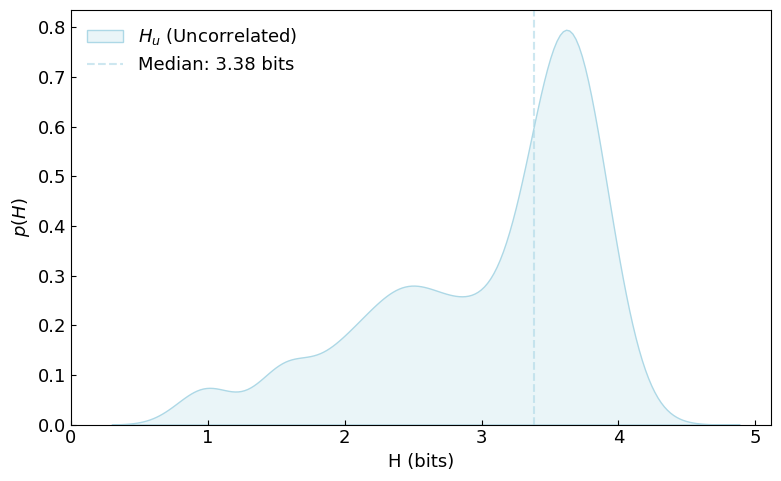

1  2026-06-04    2.521641
   2026-06-05    3.297494
2  2026-06-04    1.000000
   2026-06-05    3.542481
3  2026-06-04    2.419382
dtype: float64


In [39]:
results_series = pd.Series(results_corregido)
hu_values = results_series.apply(compute_hu).dropna()

if hu_values.empty:
    print("mal")
else:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(hu_values, fill=True, color='lightblue', label='$H_u$ (Uncorrelated)')
    median_val = hu_values.median()
    plt.axvline(median_val, linestyle='--', color='lightblue', alpha=0.6,label=f'Median: {median_val:.2f} bits')
    plt.xlabel('H (bits)')
    plt.ylabel('$p(H)$')
    plt.legend(frameon=False)
    plt.tick_params(axis='both', direction='in')
    plt.xlim(left=0)
    plt.tight_layout()
    plt.savefig('figs/unc_random.png', bbox_inches='tight', dpi = 300)
    plt.show()
    print(hu_values.head())

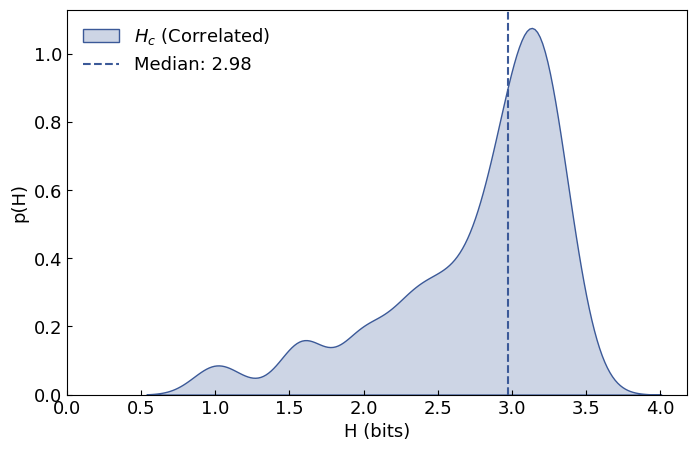

Primeros valores de Hc ficticia:
1  2026-06-04    2.456436
   2026-06-05    2.826059
2  2026-06-04    1.000000
   2026-06-05    3.056642
3  2026-06-04    2.377444
dtype: float64


In [40]:
fictitious_series = pd.Series(results_corregido)
hc_fictitious = fictitious_series.apply(compute_hc).dropna()
plt.figure(figsize=(8, 5))
sns.kdeplot(hc_fictitious, fill=True, color='#3b5998', label='$H_c$ (Correlated)')
plt.axvline(hc_fictitious.median(), color='#3b5998', linestyle='--', 
            label=f'Median: {hc_fictitious.median():.2f}')

plt.xlabel('H (bits)')
plt.ylabel('p(H)')
plt.legend(frameon=False)
plt.tick_params(axis='both', direction='in')
plt.xlim(left=0)
plt.savefig('figs/corr_random.png', bbox_inches='tight', dpi = 300)
plt.show()

print("Primeros valores de Hc ficticia:")
print(hc_fictitious.head())

tiene sentido que Hu \sim Hc, cada paso en la trayectoria es memory less!!! porque es un random walk

In [41]:
real_L = checkins.groupby('user_id')['POI_id'].nunique().mean()
sim_L = pd.Series(results_corregido).apply(lambda x: len(set(x))).mean()
print(f"Únicos Reales: {real_L} vs Simulados: {sim_L}")

Únicos Reales: 14.160599571734476 vs Simulados: 10.962199312714777


# iterate for ensuring consistency across values of entropy

Iniciando 100 simulaciones...


100%|██████████| 100/100 [00:58<00:00,  1.71it/s]


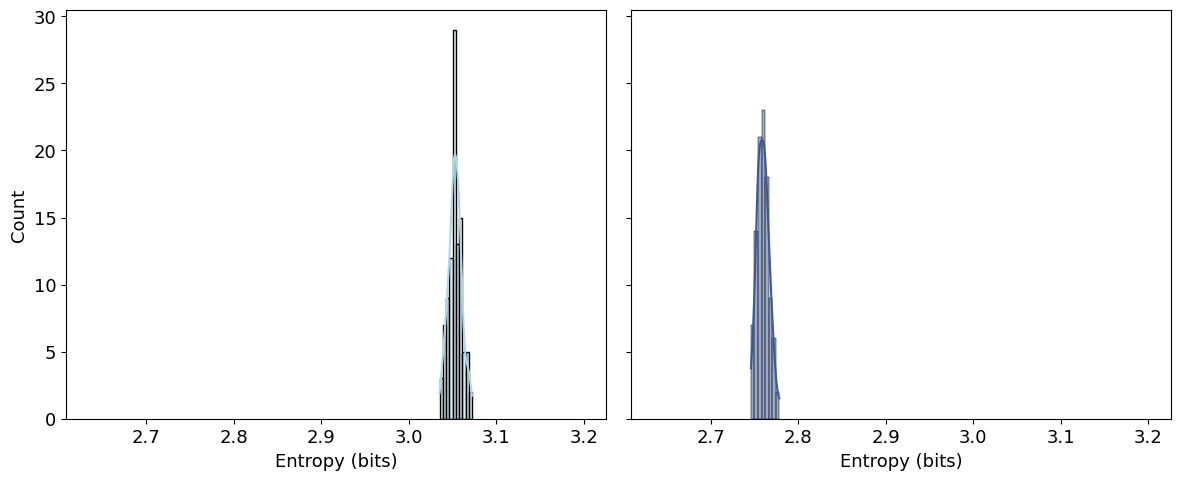

Hu: 3.0531
Hc: 2.7599


In [42]:
mean_hu_iterations = []
mean_hc_iterations = []

n_iterations = 100
pois_available = checkins['POI_id'].unique()
A = 1.0
kbt_a = A * (deviation * np.sqrt(3)) / np.pi
p_0 = 1 / (1 + np.exp(l_star / kbt_a))
user_day_groups = list(checkins.groupby(['user_id', 'adj_day_4am']))

print(f"Iniciando {n_iterations} simulaciones...")

for i in tqdm(range(n_iterations)):
    iter_trajectories = {}
    for (user_id, day), group in user_day_groups:
        n_total = len(group)
        if n_total < 2: continue
        startpoint = str(group.iloc[0]['POI_id'])
        trajectory = [startpoint]
        l_visited = 1
        for _ in range(n_total - 1):
            exponent = -(l_visited - l_star) / kbt_a
            p_sigmoid = 1 / (1 + np.exp(exponent))
            p_return = np.clip((p_sigmoid - p_0) / (1 - p_0), 0, 1)
            if np.random.rand() < p_return:
                old_location = np.random.choice(trajectory)
                trajectory.append(old_location)
            else:
                new_location = str(np.random.choice(pois_available))
                trajectory.append(new_location)
                l_visited += 1
        iter_trajectories[(user_id, day)] = trajectory

    results_series = pd.Series(iter_trajectories)
    hu_iter = results_series.apply(compute_hu).dropna()
    mean_hu_iterations.append(hu_iter.mean())
    hc_iter = results_series.apply(compute_hc).dropna()
    mean_hc_iterations.append(hc_iter.mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

sns.histplot(mean_hu_iterations, kde=True, color='lightblue', ax=axes[0], label='Uncorrelated Entropy')
axes[0].set_xlabel('Entropy (bits)')
sns.histplot(mean_hc_iterations, kde=True, color='#3b5998', ax=axes[1], label='Correlated Entropy')
axes[1].set_xlabel('Entropy (bits)')
all_data = mean_hu_iterations + mean_hc_iterations
plt.xlim(min(all_data) * 0.95, max(all_data) * 1.05)
plt.tight_layout()
plt.show()

print(f"Hu: {np.mean(mean_hu_iterations):.4f}")
print(f"Hc: {np.mean(mean_hc_iterations):.4f}")

Iniciando 10 simulaciones...


100%|██████████| 10/10 [00:11<00:00,  1.18s/it]


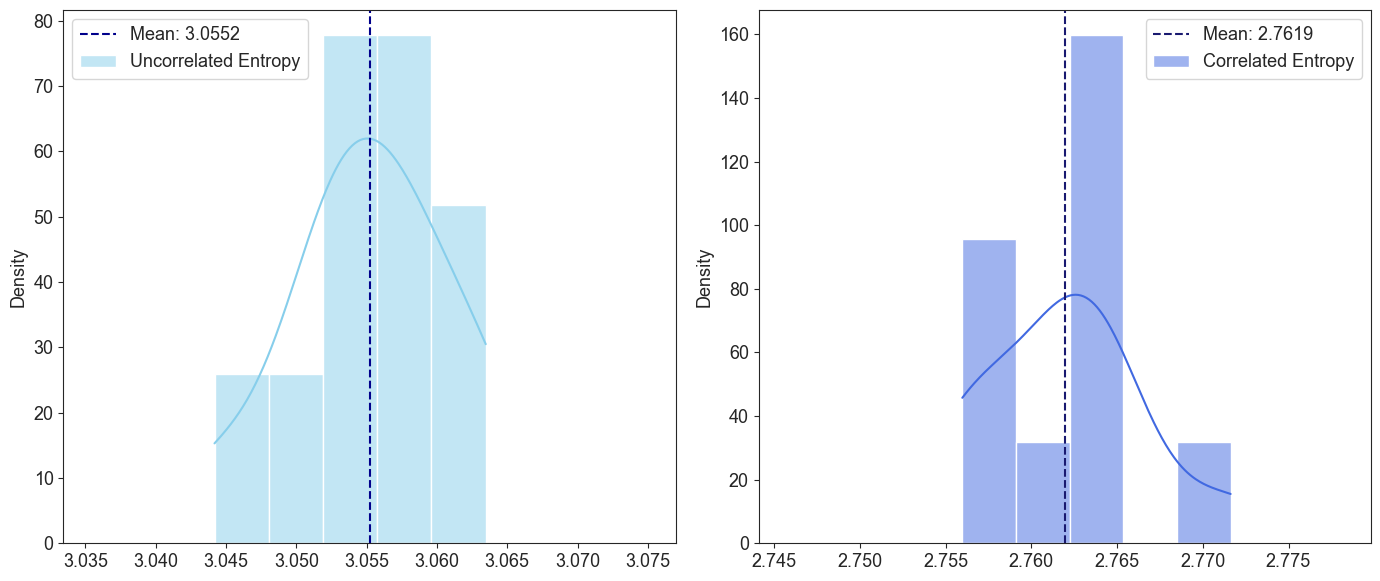

Promedio Final Hu: 3.0552 (std: 0.005444)
Promedio Final Hc: 2.7619 (std: 0.004466)


In [43]:
mean_hu_iterations, mean_hc_iterations = run_montecarlo_python(checkins, 10, 8.4204, 7.2140)

final_mean_hu = np.mean(mean_hu_iterations)
final_mean_hc = np.mean(mean_hc_iterations)
std_hu = np.std(mean_hu_iterations)
std_hc = np.std(mean_hc_iterations)

sns.set_style("ticks")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(mean_hu_iterations, kde=True, color='skyblue', ax=axes[0], stat="density", label='Uncorrelated Entropy')
axes[0].set_xlim(final_mean_hu - 4*std_hu, final_mean_hu + 4*std_hu)
axes[0].axvline(final_mean_hu, color='darkblue', linestyle='--', label=f'Mean: {final_mean_hu:.4f}')
axes[0].legend()

sns.histplot(mean_hc_iterations, kde=True, color='royalblue', ax=axes[1], stat="density", label='Correlated Entropy')
axes[1].set_xlim(final_mean_hc - 4*std_hc, final_mean_hc + 4*std_hc)
axes[1].axvline(final_mean_hc, color='midnightblue', linestyle='--', label=f'Mean: {final_mean_hc:.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Promedio Final Hu: {final_mean_hu:.4f} (std: {std_hu:.6f})")
print(f"Promedio Final Hc: {final_mean_hc:.4f} (std: {std_hc:.6f})")

Ejecutando 50 iteraciones de la población completa...


100%|██████████| 50/50 [01:01<00:00,  1.23s/it]


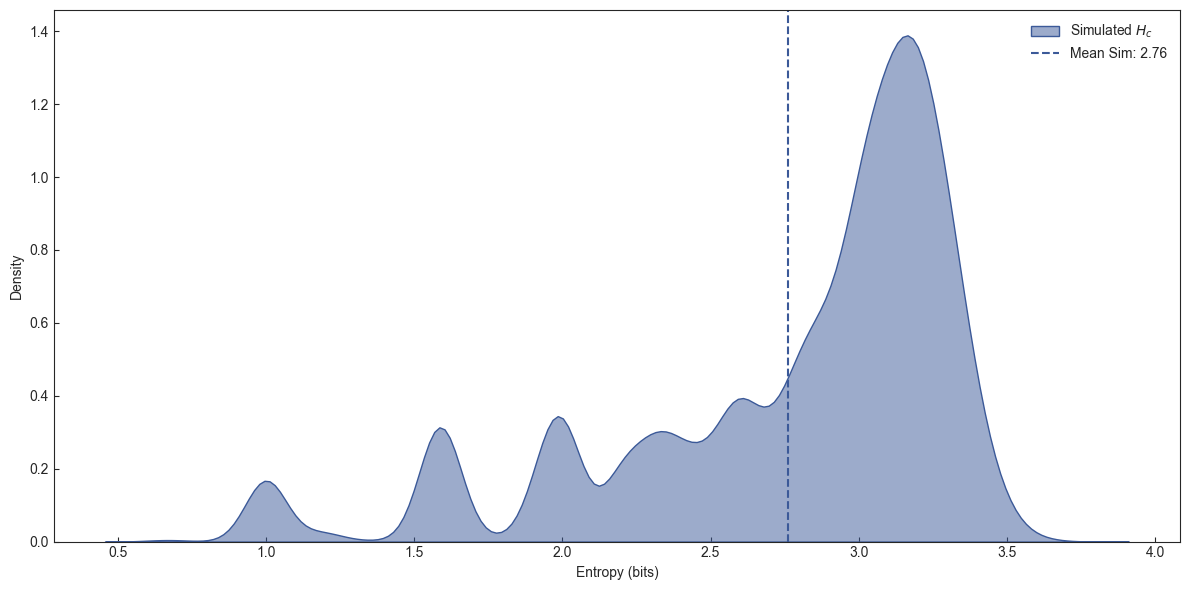

Media de la población simulada Hu: 3.0545
Media de la población simulada Hc: 2.7612


In [ ]:
hu_sim, hc_sim = run_montecarlo_individual(checkins, 50, 8.4204, 7.2140)
plt.figure(figsize=(12, 6))
sns.kdeplot(hc_sim, fill=True, color='#3b5998', label='Simulated $H_c$', alpha=0.5)
plt.axvline(np.nanmean(hc_sim), color='#3b5998', linestyle='--', 
            label=f'Mean Sim: {np.nanmean(hc_sim):.2f}')
plt.xlabel('Entropy (bits)')
plt.ylabel('Density')
plt.legend(frameon=False)
plt.tick_params(axis='both', direction='in')
plt.grid(False)

plt.tight_layout()
plt.savefig('figs/hcsimulated.png', dpi = 300, bbox_inches ='tight')
plt.show()

print(f"Media de la población simulada Hu: {np.nanmean(hu_sim):.4f}")
print(f"Media de la población simulada Hc: {np.nanmean(hc_sim):.4f}")

Iniciando 10 simulaciones por género...


100%|██████████| 10/10 [00:13<00:00,  1.35s/it]


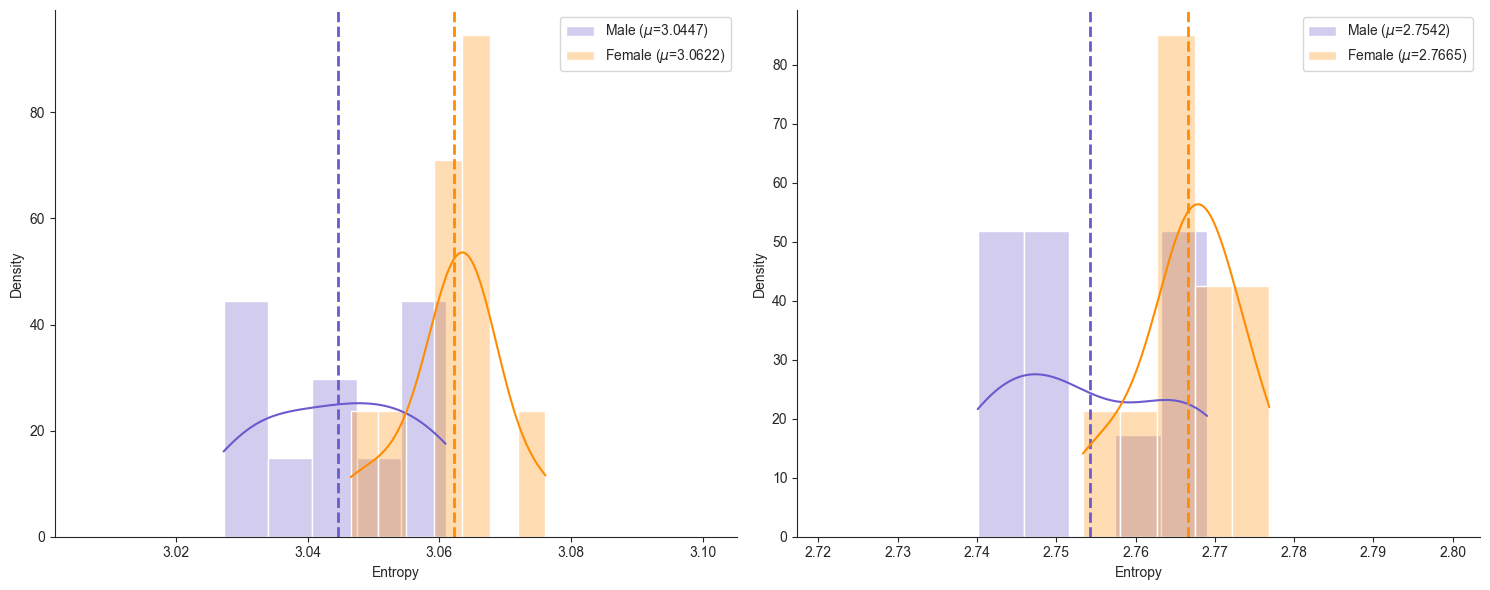

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def find_shortest_new_sequence_python(sequence, i):
    n = len(sequence)
    for length in range(1, n - i + 1):
        sub_sequence = sequence[i:i + length]
        is_seen = False
        for j in range(i):
            if np.array_equal(sequence[j:j + length], sub_sequence):
                is_seen = True
                break
        if not is_seen:
            return length
    return n - i + 1

def compute_hc_python(sequence):
    n = len(sequence)
    if n < 2:
        return np.nan
    total_lambda = 0.0
    for i in range(n):
        total_lambda += find_shortest_new_sequence_python(sequence, i)
    return (n * np.log2(n)) / total_lambda

def random_walk_logic_python(n_total, start_poi, l_star, kbt_a, p_0, pois_array):
    trajectory = [start_poi]
    l_visited = 1
    for _ in range(n_total - 1):
        exponent = -(l_visited - l_star) / kbt_a
        p_sigmoid = 1 / (1 + np.exp(exponent))
        p_return = (p_sigmoid - p_0) / (1 - p_0)
        p_return = np.clip(p_return, 0.0, 1.0)
        if np.random.random() < p_return:
            old_loc = np.random.choice(trajectory)
            trajectory.append(old_loc)
        else:
            new_loc = np.random.choice(pois_array)
            trajectory.append(new_loc)
            l_visited += 1
    return np.array(trajectory)

def run_montecarlo_genero(df_input, n_iterations, l_star, deviation):
    poi_to_int = {poi: i for i, poi in enumerate(df_input['POI_id'].unique())}
    pois_array = np.array(list(poi_to_int.values()))
    
    df_copy = df_input.copy()
    df_copy['POI_int'] = df_copy['POI_id'].map(poi_to_int)
    
    A = 1.0
    kbt_a = A * (deviation * np.sqrt(3)) / np.pi
    p_0 = 1 / (1 + np.exp(l_star / kbt_a))
    
    groups = []
    for (u_id, day, gen), group in df_copy.groupby(['user_id', 'adj_day_4am', 'gender']):
        if len(group) >= 2:
            groups.append({'n_total': len(group), 'start_poi': group.iloc[0]['POI_int'], 'gender': gen})
            
    resultados = {
        'hu': {0: [], 1: []}, 
        'hc': {0: [], 1: []}
    }
    
    print(f"Iniciando {n_iterations} simulaciones por género...")
    for _ in tqdm(range(n_iterations)):
        temp_hu = {0: [], 1: []}
        temp_hc = {0: [], 1: []}
        
        for g in groups:
            traj = random_walk_logic_python(g['n_total'], g['start_poi'], l_star, kbt_a, p_0, pois_array)
            
            # Cálculo de Hu
            _, counts = np.unique(traj, return_counts=True)
            hu = -np.sum((counts/len(traj)) * np.log2(counts/len(traj)))
            temp_hu[g['gender']].append(hu)
            
            # Cálculo de Hc
            hc = compute_hc_python(traj)
            temp_hc[g['gender']].append(hc)
            
        for gen in [0, 1]:
            resultados['hu'][gen].append(np.nanmean(temp_hu[gen]))
            resultados['hc'][gen].append(np.nanmean(temp_hc[gen]))
            
    return resultados

# --- Ejecución ---
res_genero = run_montecarlo_genero(checkins_gender, 10, 8.4204, 7.2140)

# --- Visualización ---
sns.set_style("ticks")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

metricas = ['hu', 'hc']
colores = {0: 'slateblue', 1: 'darkorange'}
etiquetas = {0: 'Male', 1: 'Female'}

for i, met in enumerate(metricas):
    # Unificamos datos para calcular límites globales del eje
    all_data = res_genero[met][0] + res_genero[met][1]
    final_mean = np.mean(all_data)
    final_std = np.std(all_data)
    
    for gen in [0, 1]:
        data = res_genero[met][gen]
        mean_gen = np.mean(data)
        
        sns.histplot(data, kde=True, color=colores[gen], ax=axes[i], 
                     stat="density", label=f'{etiquetas[gen]} ($\mu$={mean_gen:.4f})', alpha=0.3)
        axes[i].axvline(mean_gen, color=colores[gen], linestyle='--', linewidth=2)

    axes[i].set_xlabel('Entropy')
    axes[i].set_ylabel('Density')
    # Aplicación de límites basados en 4 desviaciones estándar
    axes[i].set_xlim(final_mean - 4*final_std, final_mean + 4*final_std)
    axes[i].legend()

sns.despine()
plt.tight_layout()
plt.savefig('figs/gender.png', dpi = 300)
plt.show()

Iniciando 20 simulaciones (captura individual)...


100%|██████████| 20/20 [02:09<00:00,  6.47s/it]


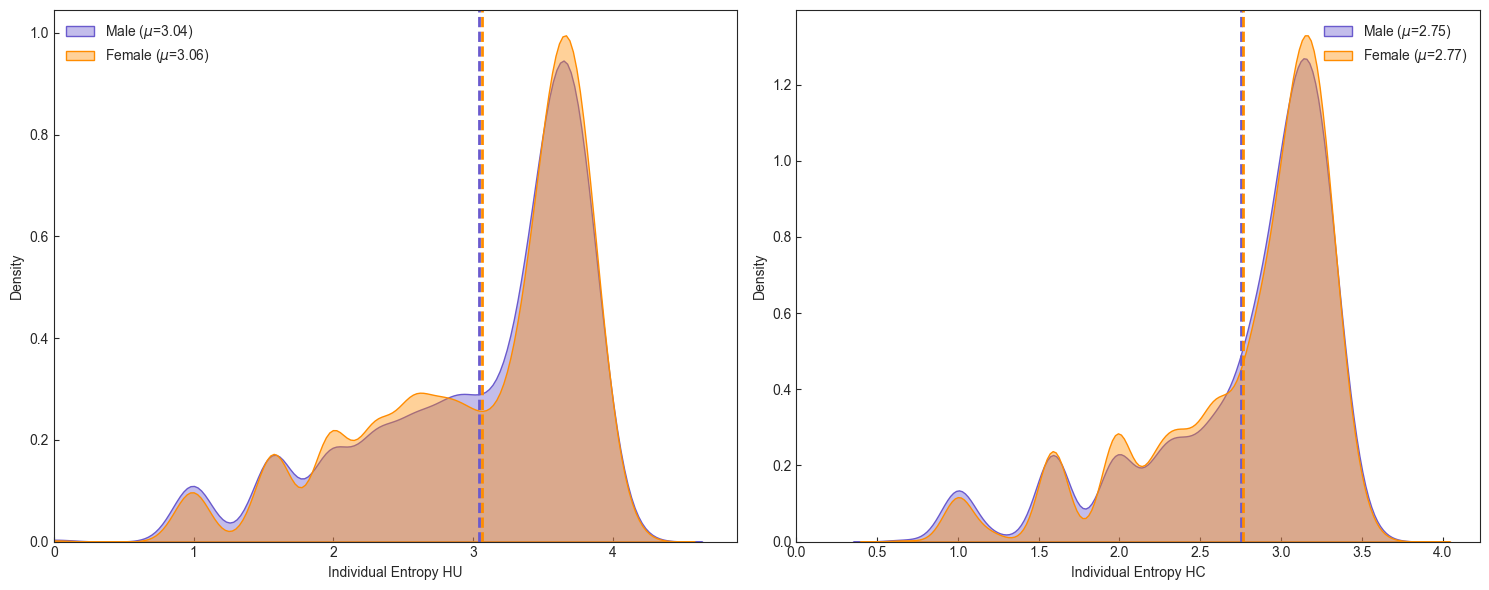

In [ ]:
def random_walk_logic_python(n_total, start_poi, l_star, kbt_a, p_0, pois_array):
    trajectory = [start_poi]
    l_visited = 1
    for _ in range(n_total - 1):
        exponent = -(l_visited - l_star) / kbt_a
        p_sigmoid = 1 / (1 + np.exp(exponent))
        p_return = (p_sigmoid - p_0) / (1 - p_0)
        p_return = np.clip(p_return, 0.0, 1.0)
        if np.random.random() < p_return:
            old_loc = np.random.choice(trajectory)
            trajectory.append(old_loc)
        else:
            new_loc = np.random.choice(pois_array)
            trajectory.append(new_loc)
            l_visited += 1
    return np.array(trajectory)

# --- SIMULACIÓN MONTE CARLO INDIVIDUAL POR GÉNERO ---

def run_montecarlo_individual_genero(df_input, n_iterations, l_star, deviation):
    poi_to_int = {poi: i for i, poi in enumerate(df_input['POI_id'].unique())}
    pois_array = np.array(list(poi_to_int.values()))
    
    df_copy = df_input.copy()
    df_copy['POI_int'] = df_copy['POI_id'].map(poi_to_int)
    
    A = 1.0
    kbt_a = A * (deviation * np.sqrt(3)) / np.pi
    p_0 = 1 / (1 + np.exp(l_star / kbt_a))
    
    groups = []
    for (u_id, day, gen), group in df_copy.groupby(['user_id', 'adj_day_4am', 'gender']):
        if len(group) >= 2:
            groups.append({'n_total': len(group), 'start_poi': group.iloc[0]['POI_int'], 'gender': gen})
            
    # Estructura para guardar TODOS los resultados individuales
    # (Ya no promediamos por iteración)
    resultados_individuales = {
        'hu': {0: [], 1: []}, 
        'hc': {0: [], 1: []}
    }
    
    print(f"Iniciando {n_iterations} simulaciones (captura individual)...")
    for _ in tqdm(range(n_iterations)):
        for g in groups:
            traj = random_walk_logic_python(g['n_total'], g['start_poi'], l_star, kbt_a, p_0, pois_array)
            
            # Hu individual
            _, counts = np.unique(traj, return_counts=True)
            hu = -np.sum((counts/len(traj)) * np.log2(counts/len(traj)))
            resultados_individuales['hu'][g['gender']].append(hu)
            
            # Hc individual
            hc = compute_hc_python(traj)
            resultados_individuales['hc'][g['gender']].append(hc)
            
    return resultados_individuales

# --- Ejecución ---
# Reducimos n_iterations porque ahora cada iteración genera miles de puntos
res_individual = run_montecarlo_individual_genero(checkins_gender, 20, 8.4204, 7.2140)

# --- Visualización ---
sns.set_style("ticks")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

metricas = ['hu', 'hc']
colores = {0: 'slateblue', 1: 'darkorange'}
etiquetas = {0: 'Male', 1: 'Female'}

for i, met in enumerate(metricas):
    for gen in [0, 1]:
        data = np.array(res_individual[met][gen])
        data = data[~np.isnan(data)] # Limpiar nans
        mean_val = np.mean(data)
        
        # Usamos KDEplot para ver la "curva de población" suave
        sns.kdeplot(data, fill=True, color=colores[gen], ax=axes[i], 
                    label=f'{etiquetas[gen]} ($\mu$={mean_val:.2f})', alpha=0.4)
        
        axes[i].axvline(mean_val, color=colores[gen], linestyle='--', linewidth=2)

    axes[i].set_xlabel(f'Individual Entropy {met.upper()}')
    axes[i].set_ylabel('Density')
    axes[i].tick_params(axis='both', direction = 'in')
    axes[i].set_xlim(left=0) # La entropía no puede ser negativa
    axes[i].legend(frameon=False)

plt.tight_layout()
plt.savefig('figs/gendersim.png', dpi = 300, bbox_inches='tight')
plt.show()

In [44]:
checkins_gender['time'] = pd.to_datetime(checkins_gender['time'])
checkins_gender['mov_day'] = (checkins_gender['time'] - pd.Timedelta(hours=4)).dt.date
checkins_gender['puntos_por_dia'] = checkins_gender.groupby(['user_id', 'mov_day'])['POI_id'].transform('count')
checkins_gender = checkins_gender[checkins_gender['puntos_por_dia'] > 1].copy()
checkins_gender = checkins_gender.drop(columns=['puntos_por_dia'])

print(f"Registros restantes tras eliminar trayectorias de 1 solo punto: {len(checkins_gender)}")

Registros restantes tras eliminar trayectorias de 1 solo punto: 20357


# ANALISIS RETURN

In [ ]:
resultados_entropia = []
grouped_retorno = trayectorias_retorno_df.groupby(['user_id', 'mov_day'])

print(f"Calculando entropía real para {len(grouped_retorno)} trayectorias de retorno...")

for (u_id, day), group in tqdm(grouped_retorno):
    sequence = group['POI_id'].tolist()
    n = len(sequence)
    if n >= 2:
        hu = compute_hu(sequence)
        hc_raw = compute_hc(sequence)
        hc_final = min(hc_raw, hu)
        resultados_entropia.append({ 'user_id': u_id, 'mov_day': day, 'gender': group.iloc[0]['gender'], 'Hu': hu,'Hc': hc_final, 'n_puntos': n})
df_res_home = pd.DataFrame(resultados_entropia)

print("\n--- Validación de Resultados ---")
print(f"¿Hay casos donde Hc > Hu?: {(df_res_home['Hc'] > df_res_home['Hu']).any()}")
print(df_res_home[['Hu', 'Hc']].describe())

Calculando entropía real para 398 trayectorias de retorno...


100%|██████████| 398/398 [00:00<00:00, 451.86it/s]


--- Validación de Resultados ---
¿Hay casos donde Hc > Hu?: False
               Hu          Hc
count  398.000000  398.000000
mean     1.548066    1.380326
std      1.292440    1.111067
min     -0.000000   -0.000000
25%      0.000000    0.000000
50%      1.378782    1.319838
75%      2.705772    2.319463
max      5.064917    4.432996


Calculando entropía para el TOTAL (729 trayectorias)...


100%|██████████| 729/729 [00:01<00:00, 412.96it/s]


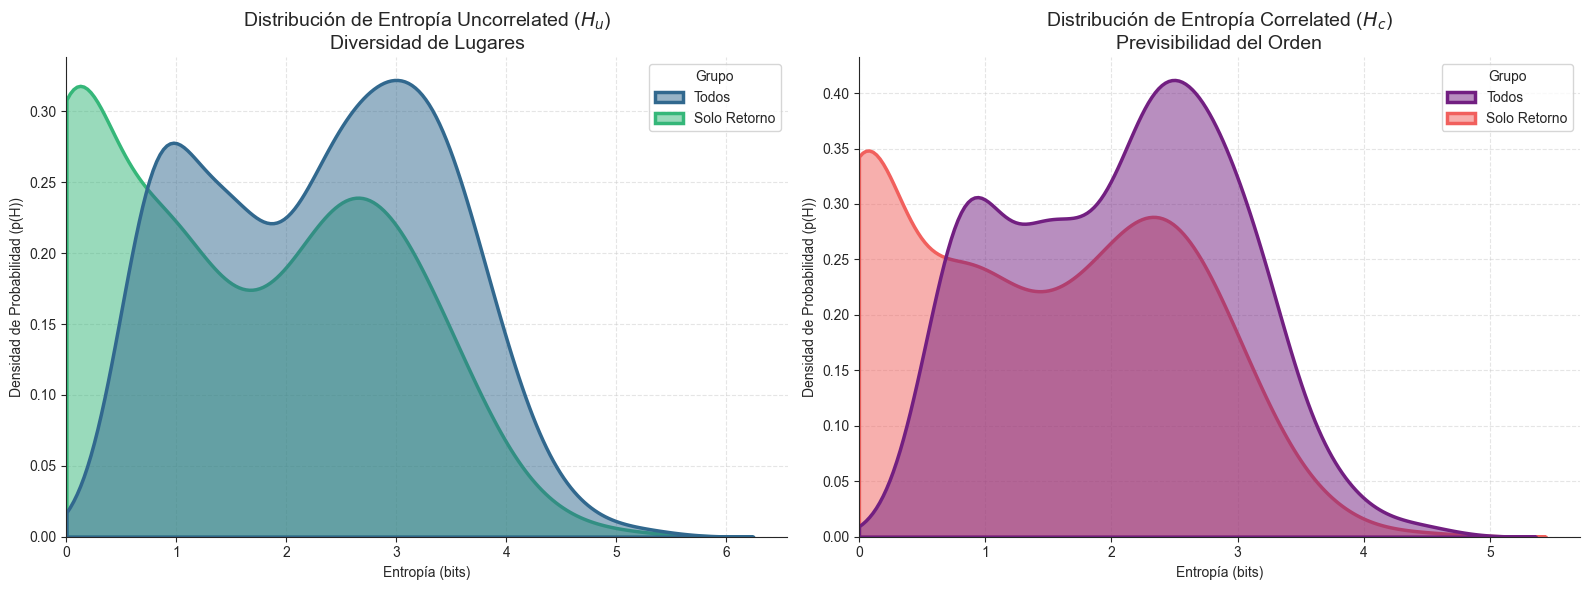


--- COMPARATIVA DE TENDENCIA CENTRAL (Bits) ---
                  Hu                      Hc                
                mean  median     std    mean  median     std
Grupo                                                       
Solo Retorno  1.5481  1.3788  1.2924  1.3803  1.3198  1.1111
Todos         2.3173  2.4356  1.0900  2.0652  2.1823  0.8955


In [ ]:
checkins_gender['unique_pois_day'] = checkins_gender.groupby(['user_id', 'mov_day'])['POI_id'].transform('nunique')
df_todos = checkins_gender[checkins_gender['unique_pois_day'] > 1].copy()
resultados_todos = []
grouped_todos = df_todos.groupby(['user_id', 'mov_day'])

print(f"Calculando entropía para el TOTAL ({len(grouped_todos)} trayectorias)...")

for (u_id, day), group in tqdm(grouped_todos):
    sequence = group['POI_id'].tolist()
    hu = compute_hu(sequence)
    hc_raw = compute_hc(sequence)
    hc_final = min(hc_raw, hu)
    resultados_todos.append({'Hu': hu, 'Hc': hc_final, 'Grupo': 'Todos'})

df_res_todos = pd.DataFrame(resultados_todos)

df_res_home['Grupo'] = 'Solo Retorno'
df_distribucion = pd.concat([df_res_todos[['Hu', 'Hc', 'Grupo']], df_res_home[['Hu', 'Hc', 'Grupo']]])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("ticks")

# Distribución Hu (Uncorrelated)
sns.kdeplot(data=df_distribucion, x='Hu', hue='Grupo', fill=True, common_norm=False,
            palette='viridis', alpha=0.5, linewidth=2.5, ax=axes[0], clip=(0, None))
axes[0].set_title('Distribución de Entropía Uncorrelated ($H_u$)\nDiversidad de Lugares', fontsize=14)
axes[0].set_xlabel('Entropía (bits)')
axes[0].set_ylabel('Densidad de Probabilidad (p(H))')

# Distribución Hc (Correlated)
sns.kdeplot(data=df_distribucion, x='Hc', hue='Grupo', fill=True, common_norm=False,
            palette='magma', alpha=0.5, linewidth=2.5, ax=axes[1], clip=(0, None))
axes[1].set_title('Distribución de Entropía Correlated ($H_c$)\nPrevisibilidad del Orden', fontsize=14)
axes[1].set_xlabel('Entropía (bits)')
axes[1].set_ylabel('Densidad de Probabilidad (p(H))')

for ax in axes:
    ax.set_xlim(left=0) 
    ax.grid(True, linestyle='--', alpha=0.5)
    sns.despine(ax=ax) 
    if ax.get_legend():
        ax.get_legend().set_title('Grupo')
plt.tight_layout()
plt.show()

print("\n--- COMPARATIVA DE TENDENCIA CENTRAL (Bits) ---")
resumen = df_distribucion.groupby('Grupo')[['Hu', 'Hc']].agg(['mean', 'median', 'std'])
print(resumen.round(4))

In [ ]:
lista_users_sin_repeticion = dias_sin_repeticion['user_id'].unique().tolist()

print(f"Lista de usuarios con trayectorias sin repetición (Total: {len(lista_users_sin_repeticion)}):")
print(lista_users_sin_repeticion) 

users_genero_explora = checkins_gender[checkins_gender['user_id'].isin(lista_users_sin_repeticion)].groupby('user_id')['gender'].first()
print("\nDistribución de género en estos usuarios:")
print(users_genero_explora.value_counts())

Lista de usuarios con trayectorias sin repetición (Total: 40):
[17, 48, 60, 98, 104, 105, 126, 130, 133, 134, 135, 138, 151, 153, 166, 167, 178, 193, 205, 206, 208, 214, 230, 239, 262, 292, 310, 325, 346, 353, 361, 377, 389, 397, 424, 437, 442, 448, 462, 463]

Distribución de género en estos usuarios:
gender
1    29
0    11
Name: count, dtype: int64


Total de trayectorias (con retorno y >1 POI): 729


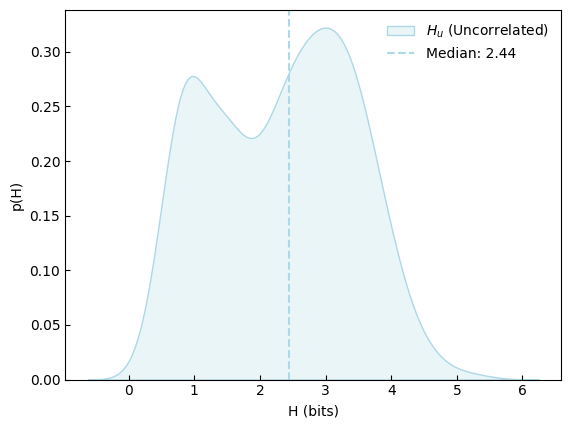

In [18]:
checkins['time'] = pd.to_datetime(checkins['time'])
checkins['mov_day'] = checkins['time'].apply(lambda x: x.date() if x.hour >= 4 else (x - pd.Timedelta(days=1)).date())
checkins = checkins.sort_values(by=['user_id', 'time'])
user_sequences = checkins.groupby(['user_id', 'mov_day'])['POI_id'].apply(list)
user_sequences = user_sequences[user_sequences.apply(lambda x: len(set(x)) > 1)]

checkins = checkins.sort_values(by=['user_id', 'day', 'time'])
user_sequences = checkins.groupby(['user_id', 'mov_day'])['POI_id'].apply(list)
user_sequences = user_sequences[user_sequences.apply(lambda x: len(set(x)) > 1)]
hu_values = user_sequences.apply(compute_hu)
print(f"Total de trayectorias (con retorno y >1 POI): {len(hu_values)}")
sns.kdeplot(hu_values, fill=True, color='lightblue', label='$H_u$ (Uncorrelated)')
plt.axvline(hu_values.median(), linestyle='--', color='lightblue', label=f'Median: {hu_values.median():.2f}')
plt.xlabel('H (bits)')
plt.ylabel('p(H)')
plt.legend(frameon=False)
plt.tick_params(axis='both', direction='in')
plt.show()

In [27]:
checkins_gender['time'] = pd.to_datetime(checkins_gender['time'])
checkins_gender['mov_day'] = checkins_gender['time'].apply(lambda x: x.date() if x.hour >= 4 else (x - pd.Timedelta(days=1)).date())
checkins_gender = checkins_gender.sort_values(by=['user_id', 'time'])
user_sequences = checkins_gender.groupby(['user_id', 'mov_day'])['POI_id'].apply(list)
user_sequences = user_sequences[user_sequences.apply(lambda x: len(set(x)) > 1)]

user_sequences_all = checkins_gender.groupby(['user_id', 'mov_day'])['POI_id'].apply(list)
user_sequences_return = user_sequences_all[(user_sequences_all.apply(lambda x: len(set(x)) > 1)) & (user_sequences_all.apply(lambda x: str(x[0]) == str(x[-1])))]

hu_values_return = user_sequences_return.apply(compute_hu)
print(f"Total de trayectorias (con retorno y >1 POI): {len(hu_values_return)}")
sns.kdeplot(hu_values, fill=True, color='slateblue', label='$H_u$ (Uncorrelated)')
plt.axvline(hu_values.median(), linestyle='--', color='slateblue', label=f'Median: {hu_values.median():.2f}')
sns.kdeplot(hu_values_return, fill=True, color='lightblue', label='$H_u$ return')
plt.axvline(hu_values_return.median(), linestyle='--', color='lightblue', label=f'Median: {hu_values_return.median():.2f}')
plt.xlabel('H (bits)')
plt.ylabel('p(H)')
plt.legend(frameon=False)
plt.tick_params(axis='both', direction='in')
plt.show()

Total de trayectorias (con retorno y >1 POI): 294


NameError: name 'hu_values' is not defined

Total trayectorias filtradas: 833
Total trayectorias con retorno: 294


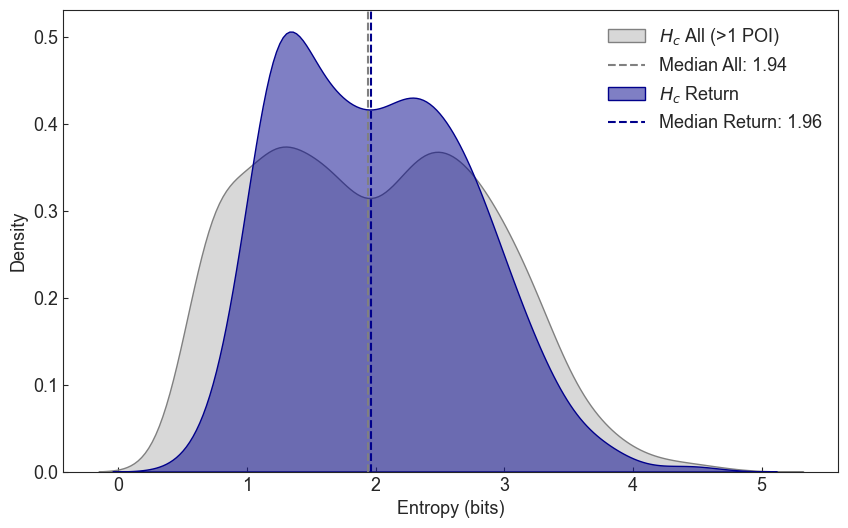

In [45]:
hc_values_all = user_sequences_all.apply(compute_hc_python).dropna()
hc_values_return = user_sequences_return.apply(compute_hc_python).dropna()


print(f"Total trayectorias filtradas: {len(hc_values_all)}")
print(f"Total trayectorias con retorno: {len(hc_values_return)}")

plt.figure(figsize=(10, 6))
sns.kdeplot(hc_values_all, fill=True, color='gray', label='$H_c$ All (>1 POI)', alpha=0.3)
plt.axvline(hc_values_all.median(), linestyle='--', color='gray', 
            label=f'Median All: {hc_values_all.median():.2f}')
sns.kdeplot(hc_values_return, fill=True, color='darkblue', label='$H_c$ Return', alpha=0.5)
plt.axvline(hc_values_return.median(), linestyle='--', color='darkblue', 
            label=f'Median Return: {hc_values_return.median():.2f}')
plt.xlabel('Entropy (bits)')
plt.ylabel('Density')
plt.legend(frameon=False)
plt.tick_params(axis='both', direction='in')
plt.grid(False)
plt.show()

# entropy as a function of the length of the trajectories

Total trayectorias: 729
Total retorno: 294
Total retorno: 602


C:\Users\34633\AppData\Local\Temp\ipykernel_29236\2515084526.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  visitback_sequences['Hu'] = visitback_sequences['sequence'].apply(compute_hu)


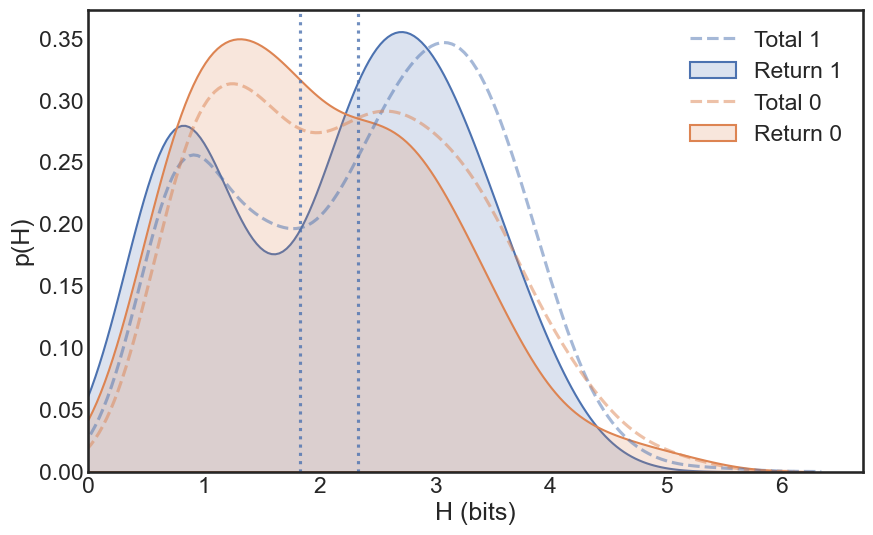

Top 10 categorías finales en trayectorias de retorno:
last_cat
Residence               212
School                   57
Hotel                     7
Sports                    7
unknown                   3
Cultural                  3
Health                    2
Arts & Entertainment      1
Shopping Mall             1
Organization              1
Name: count, dtype: int64


In [ ]:
grouped = checkins_gender.groupby(['user_id', 'mov_day']).agg(sequence=('POI_id', list), gender=('gender', 'first'), last_cat=('POI_category', 'last'))
total_sequences = grouped[grouped['sequence'].apply(lambda x: len(set(x)) > 1)].copy()
return_sequences = total_sequences[total_sequences['sequence'].apply(lambda x: str(x[0]) == str(x[-1]))].copy()
visitback_sequences = total_sequences[total_sequences['sequence'].apply(lambda x: x.count(x[0]) > 1)]

# 3. Cálculo de entropía Hu
total_sequences['Hu'] = total_sequences['sequence'].apply(compute_hu)
return_sequences['Hu'] = return_sequences['sequence'].apply(compute_hu)
visitback_sequences['Hu'] = visitback_sequences['sequence'].apply(compute_hu)
# 4. Visualización por género (4 líneas)
plt.figure(figsize=(10, 6))
palette = {'male': 'blue', 'female': 'red'}

for g in total_sequences['gender'].unique():
    # Distribución Total por género
    sns.kdeplot(data=total_sequences[total_sequences['gender'] == g], x='Hu', 
                color=palette.get(g), label=f'Total {g}', linestyle='--', alpha=0.5)
    
    # Distribución Retorno por género
    sns.kdeplot(data=return_sequences[return_sequences['gender'] == g], x='Hu', 
                color=palette.get(g), label=f'Return {g}', fill=True, alpha=0.2)

    # Medianas de retorno
    med_ret = return_sequences[return_sequences['gender'] == g]['Hu'].median()
    plt.axvline(med_ret, color=palette.get(g), linestyle=':', alpha=0.8)

print(f"Total trayectorias: {len(total_sequences)}")
print(f"Total retorno: {len(return_sequences)}")
print(f"Total retorno: {len(visitback_sequences)}")

plt.xlabel('H (bits)')
plt.ylabel('p(H)')
plt.legend(frameon=False)
plt.tick_params(axis='both', direction='in')
plt.xlim(left=0)
plt.show()

print("Top 10 categorías finales en trayectorias de retorno:")
print(return_sequences['last_cat'].value_counts().head(10))

Filtrando por: 5 visitas (exacto)
Total trayectorias que cumplen: 31
Total retorno dentro del filtro: 10


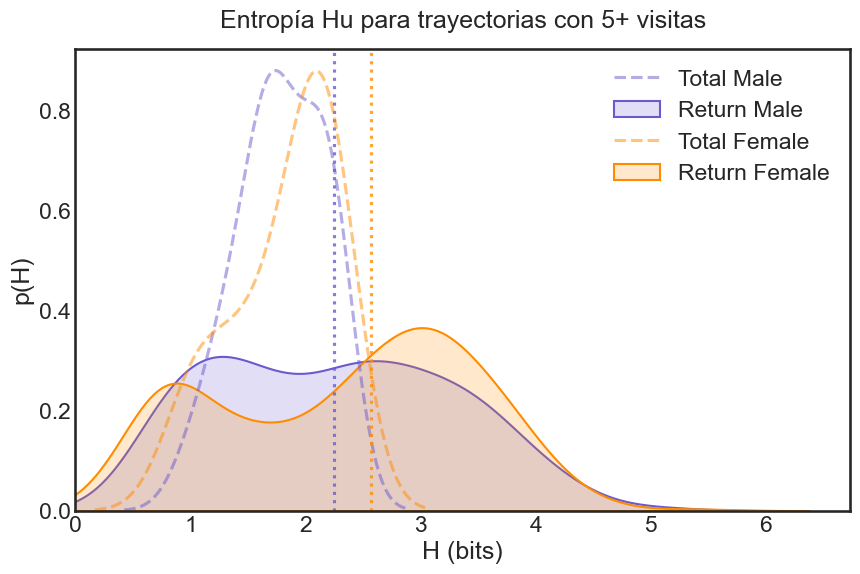

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DEL FILTRO ---
N_VISITAS = 5  # Cambia este número según lo que necesites analizar
MODO_FILTRO = 'exacto' # 'exacto' para == N, 'minimo' para >= N

# 1. Agrupación inicial incluyendo género
grouped = checkins_gender.groupby(['user_id', 'mov_day']).agg(
    sequence=('POI_id', list),
    gender=('gender', 'first')
)

# 2. Cálculo de longitud de la trayectoria (visitas únicas)
grouped['n_visitas'] = grouped['sequence'].apply(lambda x: len(set(x)))

# 3. Aplicación del filtro de longitud
if MODO_FILTRO == 'exacto':
    filtered_grouped = grouped[grouped['n_visitas'] == N_VISITAS].copy()
elif MODO_FILTRO == 'minimo':
    filtered_grouped = grouped[grouped['n_visitas'] >= N_VISITAS].copy()

total_sequences = filtered_grouped.copy()
return_sequences = total_sequences[total_sequences['sequence'].apply(lambda x: str(x[0]) == str(x[-1]))].copy()
total_sequences['Hu'] = total_sequences['sequence'].apply(compute_hu)
return_sequences['Hu'] = return_sequences['sequence'].apply(compute_hu)

plt.figure(figsize=(10, 6))
palette = {0: 'slateblue', 1: 'darkorange', 'male': 'slateblue', 'female': 'darkorange'}

for g in total_sequences['gender'].unique():
    label_g = 'Male' if g in [0, 'male'] else 'Female'
    color = palette.get(g)
    sns.kdeplot(data=total_sequences[total_sequences['gender'] == g], x='Hu', 
                color=color, label=f'Total {label_g}', linestyle='--', alpha=0.5)
    #sns.kdeplot(data=return_sequences[return_sequences['gender'] == g], x='Hu', 
                #color=color, label=f'Return {label_g}', fill=True, alpha=0.2)
    #res_ret = return_sequences[return_sequences['gender'] == g]['Hu']
    sns.kdeplot(data=visitback_sequences[visitback_sequences['gender'] == g], x='Hu', 
                color=color, label=f'Return {label_g}', fill=True, alpha=0.2)
    res_ret = visitback_sequences[visitback_sequences['gender'] == g]['Hu']
    if not res_ret.empty:
        med_ret = res_ret.median()
        plt.axvline(med_ret, color=color, linestyle=':', alpha=0.8)

# Detalles estéticos
plt.title(f'Entropía Hu para trayectorias con {N_VISITAS}+ visitas', pad=15)
plt.xlabel('H (bits)')
plt.ylabel('p(H)')
plt.legend(frameon=False)
plt.tick_params(axis='both', direction='in')
plt.xlim(left=0)

print(f"Filtrando por: {N_VISITAS} visitas ({MODO_FILTRO})")
print(f"Total trayectorias que cumplen: {len(total_sequences)}")
print(f"Total retorno dentro del filtro: {len(return_sequences)}")

plt.show()

In [ ]:
# 1. Obtenemos el primer POI de cada trayectoria (el "hogar" presumible)
primeros_pois = trayectorias[['user_id', 'mov_day', 'sequence']].copy()
primeros_pois['primer_poi'] = primeros_pois['sequence'].apply(lambda x: x[0])

# 2. Creamos una columna con el día siguiente para poder cruzar los datos
primeros_pois['dia_siguiente'] = primeros_pois['mov_day'] + pd.Timedelta(days=1)

# 3. Hacemos un self-merge: cruzamos el 'dia_siguiente' con el 'mov_day' del mismo usuario
# Esto nos permite comparar el inicio de hoy con el inicio de mañana
comparativa = primeros_pois.merge(
    primeros_pois[['user_id', 'mov_day', 'primer_poi']], 
    left_on=['user_id', 'dia_siguiente'], 
    right_on=['user_id', 'mov_day'],
    suffixes=('_hoy', '_manana')
)

# 4. Identificamos los casos donde el inicio de hoy es igual al inicio de mañana
# pero la trayectoria de hoy NO terminó en ese POI (retorno olvidado)
retornos_olvidados = comparativa[
    (comparativa['primer_poi_hoy'] == comparativa['primer_poi_manana']) & 
    (comparativa['sequence'].apply(lambda x: x[-1] != x[0]))
]

print(f"Trayectorias que no cerraron pero el usuario amaneció en el mismo sitio: {len(retornos_olvidados)}")

Trayectorias que no cerraron pero el usuario amaneció en el mismo sitio: 51


In [14]:
import pandas as pd

# 1. Preparación de fechas y definición del "día de movilidad" (corte a las 4 AM)
checkins_gender['time'] = pd.to_datetime(checkins_gender['time'])
checkins_gender['mov_day'] = checkins_gender['time'].apply(
    lambda x: x.date() if x.hour >= 4 else (x - pd.Timedelta(days=1)).date()
)

# 2. Asegurar el orden cronológico
checkins_gender = checkins_gender.sort_values(by=['user_id', 'time'])

# 3. Agrupación inicial para identificar secuencias y puntos de inicio
trayectorias = checkins_gender.groupby(['user_id', 'mov_day']).agg(
    sequence=('POI_id', list),
    gender=('gender', 'first'),
    n_unique=('POI_id', 'nunique')
).reset_index()

# --- NUEVA LÓGICA DE MERGE PARA RETORNOS IMPLÍCITOS ---

# Definimos el punto de inicio de cada día y el día siguiente
trayectorias['primer_poi'] = trayectorias['sequence'].apply(lambda x: x[0])
trayectorias['dia_siguiente'] = trayectorias['mov_day'] + pd.Timedelta(days=1)

# Cruzamos el inicio de hoy con el inicio de mañana (Punto B)
comparativa = trayectorias.merge(
    trayectorias[['user_id', 'mov_day', 'primer_poi']], 
    left_on=['user_id', 'dia_siguiente'], 
    right_on=['user_id', 'mov_day'],
    suffixes=('', '_manana')
)

# Identificamos quiénes volvieron:
# A) Explícitamente: inicio == fin el mismo día
# B) Implícitamente: inicio_hoy == inicio_mañana
mask_retorno_explícito = (trayectorias['n_unique'] > 1) & \
                         (trayectorias['sequence'].apply(lambda x: str(x[0]) == str(x[-1])))

mask_retorno_implícito = (comparativa['n_unique'] > 1) & \
                         (comparativa['primer_poi'] == comparativa['primer_poi_manana']) & \
                         (comparativa['sequence'].apply(lambda x: str(x[0]) != str(x[-1])))

# Extraemos los índices únicos de ambos casos
idx_explícito = trayectorias[mask_retorno_explícito][['user_id', 'mov_day']]
idx_implícito = comparativa[mask_retorno_implícito][['user_id', 'mov_day']]

# Unimos los índices (usando set_index para asegurar un cruce limpio)
indices_totales = pd.concat([idx_explícito, idx_implícito]).drop_duplicates()

# --- FILTRADO FINAL ---

# Re-definimos trayectorias_retorno con el saco ampliado
trayectorias_retorno = trayectorias[
    trayectorias.set_index(['user_id', 'mov_day']).index.isin(
        indices_totales.set_index(['user_id', 'mov_day']).index
    )
].copy()

checkins_final = checkins_gender[
    checkins_gender.set_index(['user_id', 'mov_day']).index.isin(
        trayectorias_retorno.set_index(['user_id', 'mov_day']).index
    )
]

# Resultados
print(f"Trayectorias retorno explícito: {len(idx_explícito)}")
print(f"Trayectorias retorno implícito (añadidas): {len(idx_implícito)}")
print(f"TOTAL Trayectorias (Explícitas + Implícitas): {len(trayectorias_retorno)}")
print(f"Total de registros finales: {len(checkins_final)}")

counts = checkins_final.groupby(['user_id', 'mov_day'])['gender'].first().value_counts()
print(f"\nDistribución por Género (Trayectorias):")
print(f"Hombres (0): {counts.get(0, 0)}")
print(f"Mujeres (1): {counts.get(1, 0)}")

Trayectorias retorno explícito: 294
Trayectorias retorno implícito (añadidas): 38
TOTAL Trayectorias (Explícitas + Implícitas): 332
Total de registros finales: 8793

Distribución por Género (Trayectorias):
Hombres (0): 120
Mujeres (1): 212


# users ACTUALLY returning

Total trayectorias de retorno: 332
Total trayectorias de retorno analizadas: 332
Promedio de loops por género:
gender
0    4.508333
1    4.561321
Name: num_loops, dtype: float64


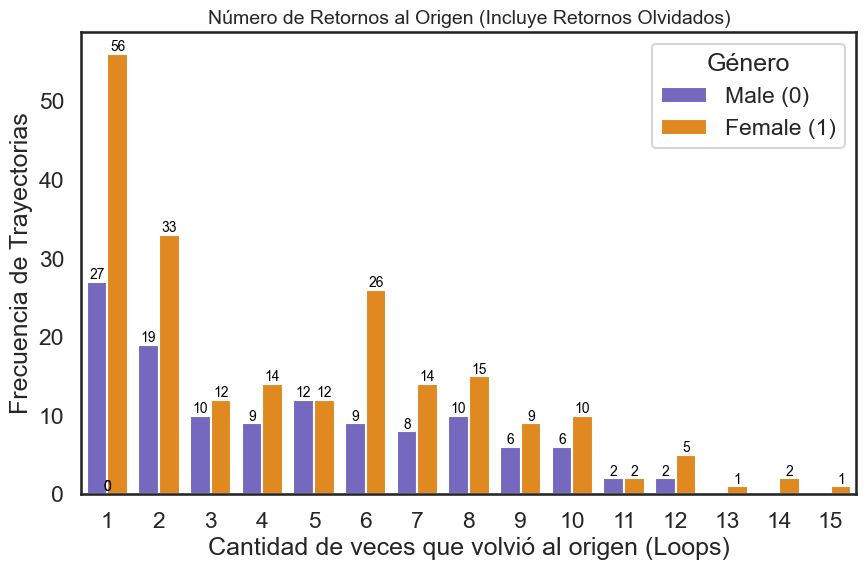

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparación de fechas y limpieza de duplicados consecutivos (evita el ruido de 41 loops)
checkins_gender['time'] = pd.to_datetime(checkins_gender['time'])
checkins_gender['mov_day'] = checkins_gender['time'].apply(
    lambda x: x.date() if x.hour >= 4 else (x - pd.Timedelta(days=1)).date()
)

checkins_gender = checkins_gender.sort_values(by=['user_id', 'time'])
checkins_cleaned = checkins_gender.loc[
    (checkins_gender['POI_id'].shift() != checkins_gender['POI_id']) | 
    (checkins_gender['user_id'].shift() != checkins_gender['user_id'])
].copy()

# 2. Agrupación por trayectorias diarias
# ... (mismo inicio de fechas y ordenación) ...

# 2. Agrupación SIN limpieza agresiva para mantener tus conteos originales
trayectorias = checkins_gender.groupby(['user_id', 'mov_day']).agg(
    sequence=('POI_id', list),
    gender=('gender', 'first'),
    n_unique=('POI_id', 'nunique')
).reset_index()

trayectorias['primer_poi'] = trayectorias['sequence'].apply(lambda x: x[0])
trayectorias['dia_siguiente'] = trayectorias['mov_day'] + pd.Timedelta(days=1)

# 3. Merge para retornos implícitos
comparativa = trayectorias.merge(
    trayectorias[['user_id', 'mov_day', 'primer_poi']], 
    left_on=['user_id', 'dia_siguiente'], 
    right_on=['user_id', 'mov_day'],
    suffixes=('', '_manana'),
    how='left'
)

# 4. Máscaras (asegurando consistencia con tus 294 y 38)
mask_explícito = (comparativa['n_unique'] > 1) & \
                 (comparativa['sequence'].apply(lambda x: str(x[0]) == str(x[-1])))

mask_implícito = (comparativa['n_unique'] > 1) & \
                 (comparativa['primer_poi'] == comparativa['primer_poi_manana']) & \
                 (comparativa['sequence'].apply(lambda x: str(x[0]) != str(x[-1])))

# 5. DataFrame final (Aquí deberían salir los 332)
trayectorias_retorno = comparativa[mask_explícito | mask_implícito].copy()

# 6. Conteo de Loops (usando SET para evitar contar duplicados técnicos como loops)
def calcular_loops_limpios(row):
    # Usamos una lista comprimida para no contar [Casa, Casa] como un retorno
    seq = row['sequence']
    seq_sin_duplicados = [seq[i] for i in range(len(seq)) if i == 0 or seq[i] != seq[i-1]]
    
    explícitos = seq_sin_duplicados.count(row['primer_poi']) - 1
    
    if str(seq_sin_duplicados[-1]) != str(row['primer_poi']) and row['primer_poi'] == row['primer_poi_manana']:
        return explícitos + 1
    return explícitos

trayectorias_retorno['num_loops'] = trayectorias_retorno.apply(calcular_loops_limpios, axis=1)

print(f"Total trayectorias de retorno: {len(trayectorias_retorno)}")

# Filtro de seguridad para eliminar outliers imposibles (ej. > 15 loops)
trayectorias_retorno = trayectorias_retorno[trayectorias_retorno['num_loops'] <= 15].copy()

# --- RESULTADOS Y GRÁFICO ---
print(f"Total trayectorias de retorno analizadas: {len(trayectorias_retorno)}")
print(f"Promedio de loops por género:\n{trayectorias_retorno.groupby('gender')['num_loops'].mean()}")

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=trayectorias_retorno, x='num_loops', hue='gender', palette={0: 'slateblue', 1: 'darkorange'})

# Ajustes de estética
plt.title('Número de Retornos al Origen (Incluye Retornos Olvidados)', fontsize=14)
plt.xlabel('Cantidad de veces que volvió al origen (Loops)')
plt.ylabel('Frecuencia de Trayectorias')
plt.legend(title='Género', labels=['Male (0)', 'Female (1)'])

# Añadir etiquetas de conteo sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

In [ ]:
import pandas as pd

# 1. Preparación de fechas y definición del "día de movilidad" (corte a las 4 AM)
checkins_gender['time'] = pd.to_datetime(checkins_gender['time'])
checkins_gender['mov_day'] = checkins_gender['time'].apply(
    lambda x: x.date() if x.hour >= 4 else (x - pd.Timedelta(days=1)).date()
)

# 2. Asegurar el orden cronológico para que el primer POI sea realmente el origen
checkins_gender = checkins_gender.sort_values(by=['user_id', 'time'])

# 3. Agrupación por usuario y día
trayectorias = checkins_gender.groupby(['user_id', 'mov_day']).agg(
    sequence=('POI_id', list),
    gender=('gender', 'first'),
    n_unique=('POI_id', 'nunique')
).reset_index()

# 4. Definición del SEGUNDO TIPO de retorno: 
# El primer POI visitado aparece de nuevo en cualquier punto posterior de la secuencia.
trayectorias_retorno = trayectorias[
    (trayectorias['n_unique'] > 1) & 
    (trayectorias['sequence'].apply(lambda x: x.count(x[0]) > 1))
].copy()

# 5. Filtrar el DataFrame original para mantener solo los registros de estas trayectorias
checkins_final = checkins_gender[
    checkins_gender.set_index(['user_id', 'mov_day']).index.isin(
        trayectorias_retorno.set_index(['user_id', 'mov_day']).index
    )
]

# Resultados
print(f"Trayectorias con algún retorno al origen: {len(trayectorias_retorno)}")
print(f"Total de registros finales: {len(checkins_final)}")

counts = checkins_final['gender'].value_counts()
print(f"Hombres (0): {counts.get(0, 0)}")
print(f"Mujeres (1): {counts.get(1, 0)}")

Trayectorias con algún retorno al origen: 602
Total de registros finales: 17254
Hombres (0): 6264
Mujeres (1): 10990


Distribución de retornos al origen (Loops) - DATOS LIMPIOS:
1 retorno(s): 208 trayectorias
2 retorno(s): 82 trayectorias
3 retorno(s): 59 trayectorias
4 retorno(s): 36 trayectorias
5 retorno(s): 30 trayectorias
6 retorno(s): 19 trayectorias
7 retorno(s): 22 trayectorias
8 retorno(s): 12 trayectorias
9 retorno(s): 9 trayectorias
10 retorno(s): 7 trayectorias
11 retorno(s): 2 trayectorias
12 retorno(s): 3 trayectorias
14 retorno(s): 1 trayectorias

Promedio de loops por género:
gender
0    2.961111
1    2.893548
Name: num_loops, dtype: float64

Máximo de retornos en un solo día (tras limpieza): 14


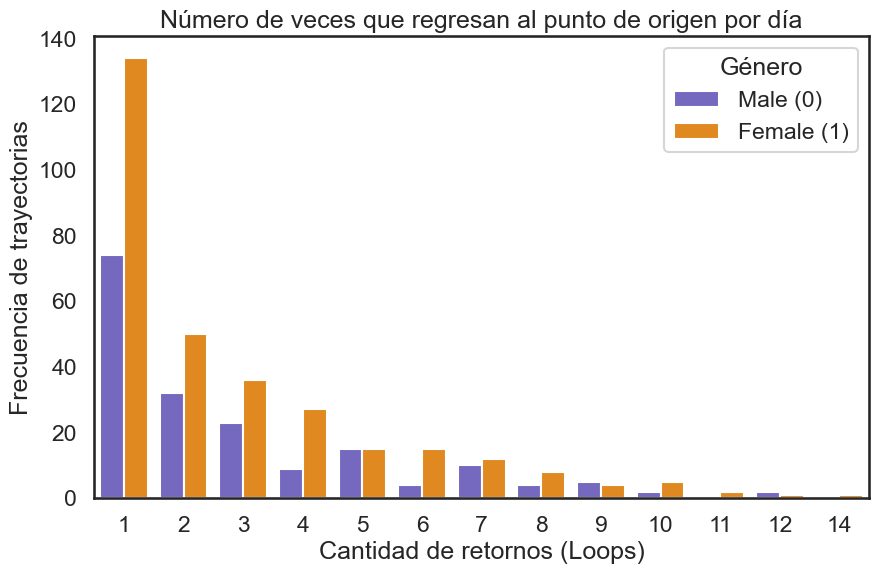

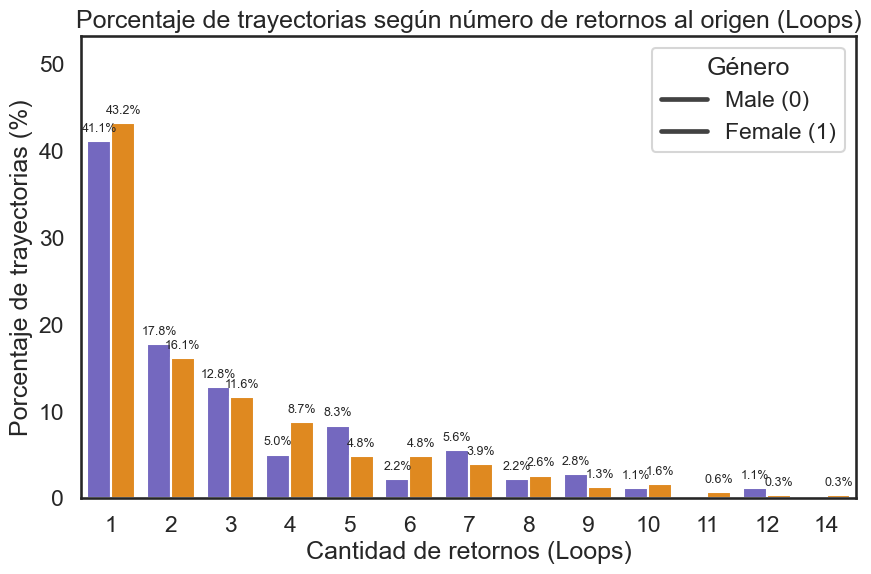

Tabla de porcentajes por género:
gender             0          1
num_loops                      
1          41.111111  43.225806
2          17.777778  16.129032
3          12.777778  11.612903
4           5.000000   8.709677
5           8.333333   4.838710
6           2.222222   4.838710
7           5.555556   3.870968
8           2.222222   2.580645
9           2.777778   1.290323
10          1.111111   1.612903
11          0.000000   0.645161
12          1.111111   0.322581
14          0.000000   0.322581


In [ ]:
checkins_gender = checkins_gender.sort_values(by=['user_id', 'time'])
checkins_cleaned = checkins_gender.loc[ (checkins_gender['POI_id'].shift() != checkins_gender['POI_id']) |  (checkins_gender['user_id'].shift() != checkins_gender['user_id'])].copy()

trayectorias = checkins_cleaned.groupby(['user_id', 'mov_day']).agg(sequence=('POI_id', list),gender=('gender', 'first'),n_unique=('POI_id', 'nunique')).reset_index()
trayectorias_retorno = trayectorias[(trayectorias['n_unique'] > 1) & (trayectorias['sequence'].apply(lambda x: x.count(x[0]) > 1))].copy()

trayectorias_retorno['num_loops'] = trayectorias_retorno['sequence'].apply(lambda x: x.count(x[0]) - 1)
trayectorias_retorno = trayectorias_retorno[trayectorias_retorno['num_loops'] <= 15].copy()

distribucion_loops = trayectorias_retorno['num_loops'].value_counts().sort_index()
print("Distribución de retornos al origen (Loops) - DATOS LIMPIOS:")
for n_loops, count in distribucion_loops.items():
    print(f"{n_loops} retorno(s): {count} trayectorias")

print("\nPromedio de loops por género:")
print(trayectorias_retorno.groupby('gender')['num_loops'].mean())

print(f"\nMáximo de retornos en un solo día (tras limpieza): {trayectorias_retorno['num_loops'].max()}")

plt.figure(figsize=(10, 6))
sns.countplot(data=trayectorias_retorno, x='num_loops', hue='gender', palette={0: 'slateblue', 1: 'darkorange'})

plt.title('Número de veces que regresan al punto de origen por día')
plt.xlabel('Cantidad de retornos (Loops)')
plt.ylabel('Frecuencia de trayectorias')
plt.legend(title='Género', labels=['Male (0)', 'Female (1)'])
plt.show()
# 1. Calculamos las proporciones por género
# Agrupamos por género y contamos cuántas veces aparece cada número de loops
counts = (trayectorias_retorno.groupby(['gender', 'num_loops'])
          .size()
          .rename('count')
          .reset_index())

# Calculamos el total de trayectorias por género para normalizar
totals = trayectorias_retorno['gender'].value_counts()
counts['percentage'] = counts.apply(lambda x: (x['count'] / totals[x['gender']]) * 100, axis=1)

# 2. Visualización
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=counts, x='num_loops', y='percentage', hue='gender', 
                 palette={0: 'slateblue', 1: 'darkorange'})

plt.title('Porcentaje de trayectorias según número de retornos al origen (Loops)')
plt.xlabel('Cantidad de retornos (Loops)')
plt.ylabel('Porcentaje de trayectorias (%)')
plt.legend(title='Género', labels=['Male (0)', 'Female (1)'])

# Añadir etiquetas de porcentaje sobre las barras para mayor claridad
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=9)

plt.ylim(0, counts['percentage'].max() + 10) # Espacio para las etiquetas
plt.show()

# 3. Mostrar tabla resumen en porcentajes
tabla_porcentajes = counts.pivot(index='num_loops', columns='gender', values='percentage').fillna(0)
print("Tabla de porcentajes por género:")
print(tabla_porcentajes)

In [ ]:
hombres_dist = analisis_factores[analisis_factores['gender'] == 0]['dist_momento_decisión']

print("--- ESTADÍSTICAS DE DISTANCIA (HOMBRES) ---")
print(hombres_dist.describe())

print("\n--- TOP 10 DISTANCIAS MÁS LARGAS (OUTLIERS POTENCIALES) ---")
print(hombres_dist.sort_values(ascending=False).head(10))

print("\n--- TRAYECTORIAS CON DISTANCIAS EXTREMAS (> 100 km) ---")
outliers = analisis_factores[(analisis_factores['gender'] == '0') & (analisis_factores['dist_momento_decisión'] > 100)]
print(outliers[['user_id', 'mov_day', 'dist_momento_decisión', 'penult_cat']])

--- ESTADÍSTICAS DE DISTANCIA (HOMBRES) ---
count      106.000000
mean       122.873292
std       1260.629275
min          0.000000
25%          0.003189
50%          0.014368
75%          0.151504
max      12979.388404
Name: dist_momento_decisión, dtype: float64

--- TOP 10 DISTANCIAS MÁS LARGAS (OUTLIERS POTENCIALES) ---
125    12979.388404
95        14.598716
194       12.756499
163        2.562166
29         1.834842
94         1.676866
45         1.659256
169        0.889308
284        0.810222
259        0.733151
Name: dist_momento_decisión, dtype: float64

--- TRAYECTORIAS CON DISTANCIAS EXTREMAS (> 100 km) ---
Empty DataFrame
Columns: [user_id, mov_day, dist_momento_decisión, penult_cat]
Index: []


# analysis of factors affecting the return

C:\Users\34633\AppData\Local\Temp\ipykernel_68344\1303817449.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  analisis_factores = checkins_final.groupby(['user_id', 'mov_day']).apply(get_detailed_info).reset_index()
C:\Users\34633\AppData\Local\Temp\ipykernel_68344\1303817449.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(frameon=False, title=False)
C:\Users\34633\AppData\Local\Temp\ipykernel_68344\1303817449.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend

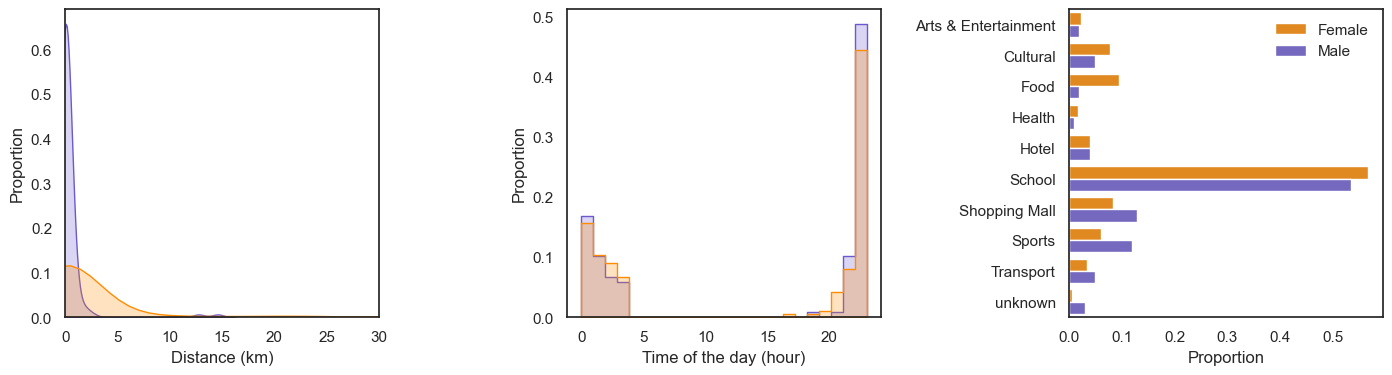

Registros analizados: 331
Máxima distancia encontrada (tras quitar outlier): 166.02 km


In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from geopy.distance import geodesic

def get_detailed_info(group):
    if len(group) < 2:
        return pd.Series([None, None, None], index=['penult_cat', 'dist_decision', 'hora_retorno'])
    
    inicio_loc = (group.iloc[0]['latitude'], group.iloc[0]['longitude'])
    
    punto_orig = group.iloc[-2]
    decision_loc = (punto_orig['latitude'], punto_orig['longitude'])
    
    dist_decision = geodesic(inicio_loc, decision_loc).km
    
    secuencia_actividades = group.iloc[:-1][~group.iloc[:-1]['POI_category'].str.contains('Residence|Home|Housing', case=False, na=False)]
    penult_cat = "Solo Home-related" if secuencia_actividades.empty else secuencia_actividades.iloc[-1]['POI_category']
    hora_retorno = group.iloc[-1]['time'].hour
            
    return pd.Series([penult_cat, dist_decision, hora_retorno], 
                     index=['penult_cat', 'dist_decision', 'hora_retorno'])

checkins_final = checkins_final.sort_values(['user_id', 'time'])
analisis_factores = checkins_final.groupby(['user_id', 'mov_day']).apply(get_detailed_info).reset_index()

generos = checkins_final.groupby(['user_id', 'mov_day'])['gender'].first().reset_index()
analisis_factores = analisis_factores.merge(generos, on=['user_id', 'mov_day'])

analisis_factores['gender_label'] = analisis_factores['gender'].map({0: 'Male', 1: 'Female'})

df_causas = analisis_factores[analisis_factores['dist_decision'] < 1000].copy()

fig, axes = plt.subplots(1, 3, figsize=(17,4))
plt.rc('font', size=14)
custom_palette = {'Male': 'slateblue', 'Female': 'darkorange'}
prop_cat['penult_cat'] = prop_cat['penult_cat'].replace('Arts & Entertainment', 'Arts &\nEntertainment')
sns.kdeplot(data=df_causas, x='dist_decision', hue='gender_label', fill=True, 
            ax=axes[0], common_norm=False, bw_adjust=0.8, palette=custom_palette)
axes[0].set_xlim(0, 30) 
axes[0].set_xlabel('Distance (km)', fontsize=12)
axes[0].set_ylabel('Proportion', fontsize=12)
axes[0].legend(frameon=False, title=False)

sns.histplot(data=df_causas, x='hora_retorno', hue='gender_label', bins=24, 
             stat="proportion", common_norm=False, element="step", ax=axes[1],
             palette=custom_palette)
axes[1].set_xlabel('Time of the day (hour)', fontsize=12)
axes[1].legend(frameon=False, title=False)

df_cats = df_causas[df_causas['penult_cat'] != "Solo Home-related"]
top_cats_idx = df_cats['penult_cat'].value_counts().nlargest(10).index
df_top_cats = df_cats[df_cats['penult_cat'].isin(top_cats_idx)]

prop_cat = (df_top_cats.groupby(['gender_label', 'penult_cat']).size() / 
            df_top_cats.groupby('gender_label').size()).reset_index(name='proporcion')

sns.barplot(data=prop_cat, y='penult_cat', x='proporcion', hue='gender_label', ax=axes[2],
            palette=custom_palette, capsize=12)
axes[2].set_xlabel('Proportion', fontsize=12)
axes[2].set_ylabel('')
axes[2].legend(frameon=False, title=False)

plt.savefig('figs/factorsreturn.png', dpi = 300, bbox_inches='tight')
plt.subplots_adjust(wspace=0.6)
plt.show()

print(f"Registros analizados: {len(df_causas)}")
print(f"Máxima distancia encontrada (tras quitar outlier): {df_causas['dist_decision'].max():.2f} km")

C:\Users\34633\AppData\Local\Temp\ipykernel_68344\1956559598.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  analisis_factores = checkins_final.groupby(['user_id', 'mov_day']).apply(get_detailed_info).reset_index()
C:\Users\34633\AppData\Local\Temp\ipykernel_68344\1956559598.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(frameon=False, title=False)
C:\Users\34633\AppData\Local\Temp\ipykernel_68344\1956559598.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend

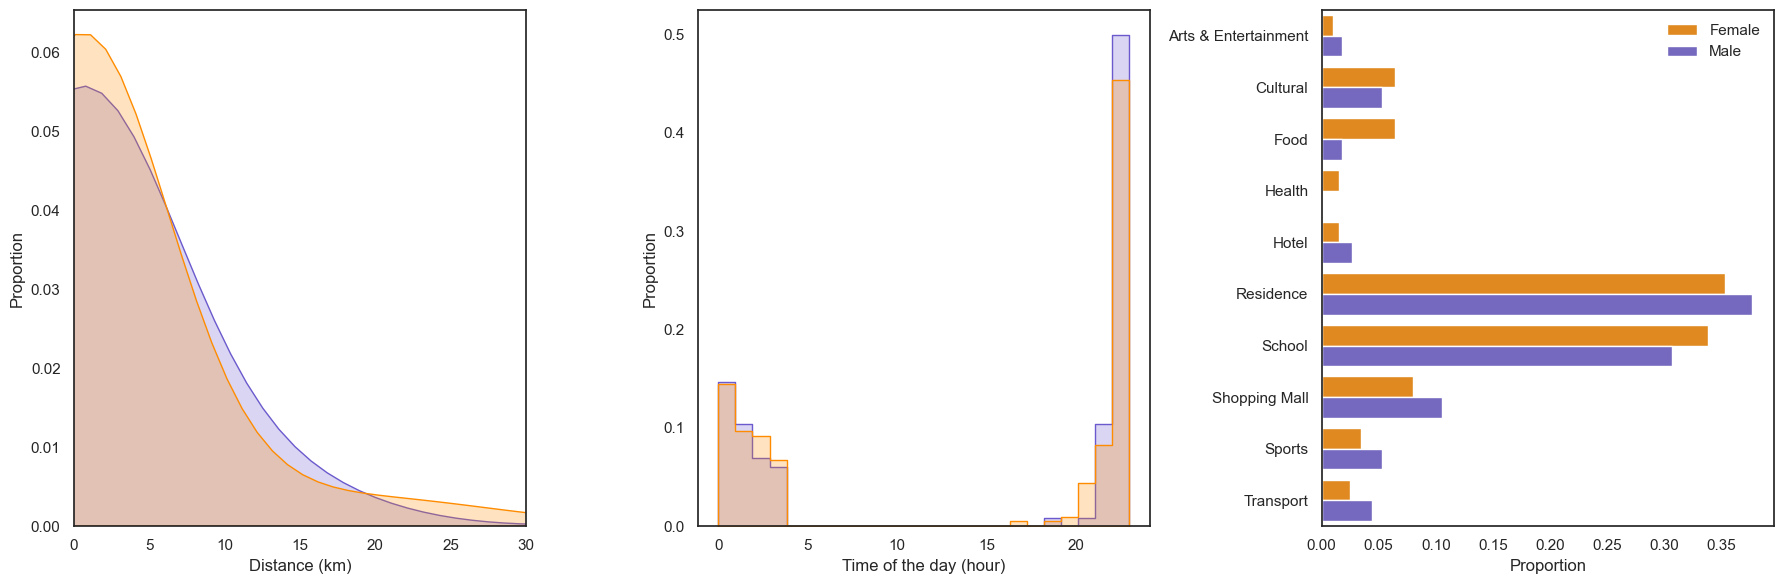

Registros analizados: 323
Máxima distancia encontrada (tras quitar outlier): 173.46 km
Probabilidad de volver a casa a las 23: 0.4706


In [56]:
def get_detailed_info(group):
    if len(group) < 2:
        return pd.Series([None, None, None], index=['penult_cat', 'dist_decision', 'hora_retorno'])
    
    # 1. Definimos el punto de origen (el primer POI del día)
    inicio_row = group.iloc[0]
    inicio_id = inicio_row['POI_id']
    inicio_loc = (inicio_row['latitude'], inicio_row['longitude'])
    
    # 2. Buscamos el punto de "decisión"
    # Queremos el último registro que NO sea el mismo POI que el de inicio
    # Empezamos desde el final hacia atrás
    punto_orig = None
    for i in range(len(group) - 2, -1, -1):
        if group.iloc[i]['POI_id'] != inicio_id:
            punto_orig = group.iloc[i]
            break
    
    # Si no se encuentra ninguno (ej. todos los POIs del día son el mismo), cancelamos
    if punto_orig is None:
        return pd.Series([None, None, None], index=['penult_cat', 'dist_decision', 'hora_retorno'])
    
    # 3. Cálculos
    decision_loc = (punto_orig['latitude'], punto_orig['longitude'])
    dist_decision = geodesic(inicio_loc, decision_loc).km
    
    penult_cat = punto_orig['POI_category']
    # La hora de retorno sigue siendo la del último check-in del grupo
    hora_retorno = group.iloc[-1]['time'].hour
            
    return pd.Series([penult_cat, dist_decision, hora_retorno], 
                     index=['penult_cat', 'dist_decision', 'hora_retorno'])

checkins_final = checkins_final.sort_values(['user_id', 'time'])
analisis_factores = checkins_final.groupby(['user_id', 'mov_day']).apply(get_detailed_info).reset_index()

generos = checkins_final.groupby(['user_id', 'mov_day'])['gender'].first().reset_index()
analisis_factores = analisis_factores.merge(generos, on=['user_id', 'mov_day'])

analisis_factores['gender_label'] = analisis_factores['gender'].map({0: 'Male', 1: 'Female'})

df_causas = analisis_factores[analisis_factores['dist_decision'] < 1000].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

custom_palette = {'Male': 'slateblue', 'Female': 'darkorange'}

sns.kdeplot(data=df_causas, x='dist_decision', hue='gender_label', fill=True, 
            ax=axes[0], common_norm=False, bw_adjust=1, palette=custom_palette)
axes[0].set_xlim(0, 30) 
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Proportion')
axes[0].legend(frameon=False, title=False)

sns.histplot(data=df_causas, x='hora_retorno', hue='gender_label', bins=24, 
             stat="proportion", common_norm=False, element="step", ax=axes[1],
             palette=custom_palette)
axes[1].set_xlabel('Time of the day (hour)')
axes[1].legend(frameon=False, title=False)

df_cats = df_causas[df_causas['penult_cat'] != "Solo Home-related"]
top_cats_idx = df_cats['penult_cat'].value_counts().nlargest(10).index
df_top_cats = df_cats[df_cats['penult_cat'].isin(top_cats_idx)]

prop_cat = (df_top_cats.groupby(['gender_label', 'penult_cat']).size() / 
            df_top_cats.groupby('gender_label').size()).reset_index(name='proporcion')

sns.barplot(data=prop_cat, y='penult_cat', x='proporcion', hue='gender_label', ax=axes[2],
            palette=custom_palette)
axes[2].set_xlabel('Proportion')
axes[2].set_ylabel('')
axes[2].legend(frameon=False, title=False)

plt.tight_layout()
plt.savefig('figs/factorsreturn.png', dpi = 300, bbox_inches='tight')
plt.show()

print(f"Registros analizados: {len(df_causas)}")
print(f"Máxima distancia encontrada (tras quitar outlier): {df_causas['dist_decision'].max():.2f} km")
prob_23 = (df_causas['hora_retorno'] == 23).mean()
print(f"Probabilidad de volver a casa a las 23: {prob_23:.4f}")

In [ ]:
from scipy.stats import gaussian_kde

def calcular_metricas_distancia(data, label):
    # 1. Punto de máxima probabilidad (Moda via KDE)
    # Usamos el mismo ajuste que en tu gráfico (bw_adjust=0.8)
    # El ancho de banda real es bw_adjust * factor_scott
    values = data.dropna()
    if len(values) > 0:
        kde = gaussian_kde(values, bw_method='scott')
        # Ajustamos el factor por el bw_adjust que usaste en Seaborn
        kde.factor *= 1 
        
        x_range = np.linspace(0, 30, 1000)
        y_values = kde.evaluate(x_range)
        peak_x = x_range[np.argmax(y_values)]
        
        # 2. Máxima distancia observada (en este conjunto filtrado < 30km)
        # O si prefieres la máxima real de df_causas sin el límite del eje X:
        max_dist = values.max()
        
        return peak_x, max_dist
    return None, None

# Extraer datos por género
males = df_causas[df_causas['gender'] == 0]['dist_decision']
females = df_causas[df_causas['gender'] == 1]['dist_decision']

peak_m, max_m = calcular_metricas_distancia(males, "Male")
peak_f, max_f = calcular_metricas_distancia(females, "Female")

print(f"--- Análisis de Distancias de Decisión ---")
print(f"Hombres (0):")
print(f"  - Punto más probable (pico): {peak_m:.2f} km")
print(f"  - Distancia máxima en datos: {max_m:.2f} km")
print(f"\nMujeres (1):")
print(f"  - Punto más probable (pico): {peak_f:.2f} km")
print(f"  - Distancia máxima en datos: {max_f:.2f} km")

--- Análisis de Distancias de Decisión ---
Hombres (0):
  - Punto más probable (pico): 0.51 km
  - Distancia máxima en datos: 173.46 km

Mujeres (1):
  - Punto más probable (pico): 0.45 km
  - Distancia máxima en datos: 166.02 km


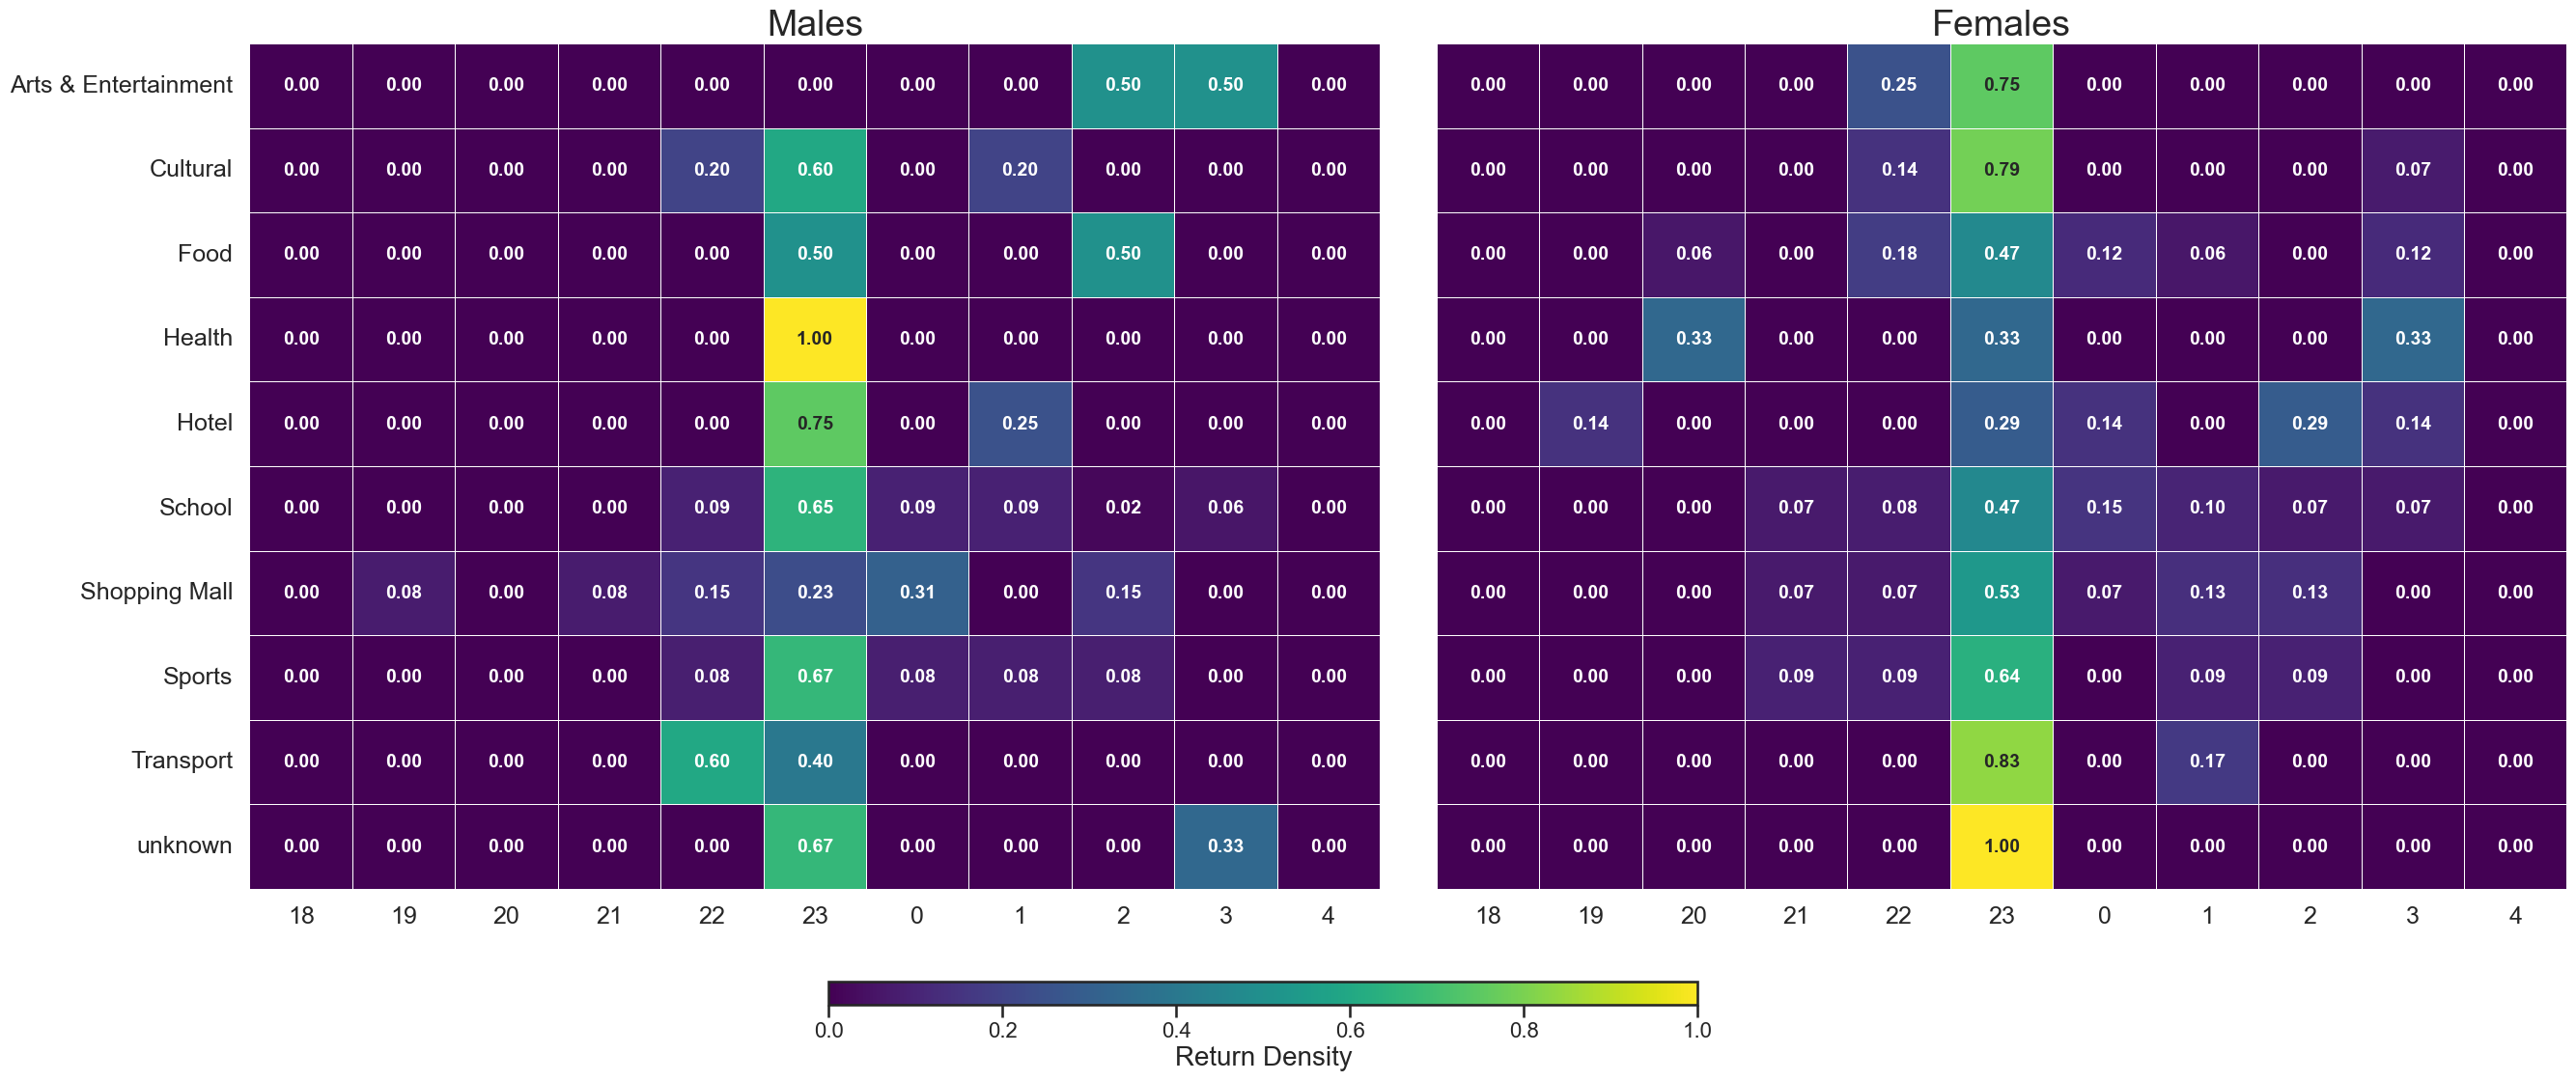

In [67]:
sns.set_theme(style="white", context="talk", font_scale=1.5) 

def plot_elegant_heatmap(data, gender_name, ax, color_map, target_hours, show_cbar=False):
    ct = pd.crosstab(data['penult_cat'], data['hora_retorno'])
    ct = ct.reindex(columns=range(24), fill_value=0)
    ct = ct[target_hours]
    conditional_prob = ct.div(ct.sum(axis=1), axis=0).fillna(0)
    
    im = sns.heatmap(conditional_prob, annot=True, fmt=".2f", annot_kws={"size": 14, "weight": "bold"},cmap=color_map, ax=ax, cbar=show_cbar, linewidths=.5)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(gender_name) 
    ax.tick_params(axis='both', which='major', labelsize=18)
    
    return im.get_children()[0]

df_filtrado = df_causas[df_causas['penult_cat'] != "Solo Home-related"].copy()
top_categories = df_filtrado['penult_cat'].value_counts().nlargest(10).index
df_cross = df_filtrado[df_filtrado['penult_cat'].isin(top_categories)].copy()
df_cross = df_cross.sort_values('penult_cat')

horas_interes = [18, 19, 20, 21, 22, 23, 0, 1, 2, 3, 4]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30,12), sharey=True)
mappable = plot_elegant_heatmap(df_cross[df_cross['gender_label'] == 'Male'], 'Males', ax1, "viridis", horas_interes, show_cbar=False)
plot_elegant_heatmap(df_cross[df_cross['gender_label'] == 'Female'], 'Females', ax2, "viridis", horas_interes, show_cbar=False)
cbar_ax = fig.add_axes([0.35, 0.05, 0.3, 0.02]) 
cbar = fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Return Density', fontsize=20)
cbar.ax.tick_params(labelsize=16)
plt.subplots_adjust(bottom=0.15, wspace=0.05, left=0.15, right=0.95)
plt.savefig('figs/return.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\34633\AppData\Local\Temp\ipykernel_73388\1906883108.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  analisis_factores = checkins_final.groupby(['user_id', 'mov_day']).apply(get_detailed_info).reset_index()
C:\Users\34633\AppData\Local\Temp\ipykernel_73388\1906883108.py:99: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_hist.legend(frameon=False, title=False, fontsize=12)


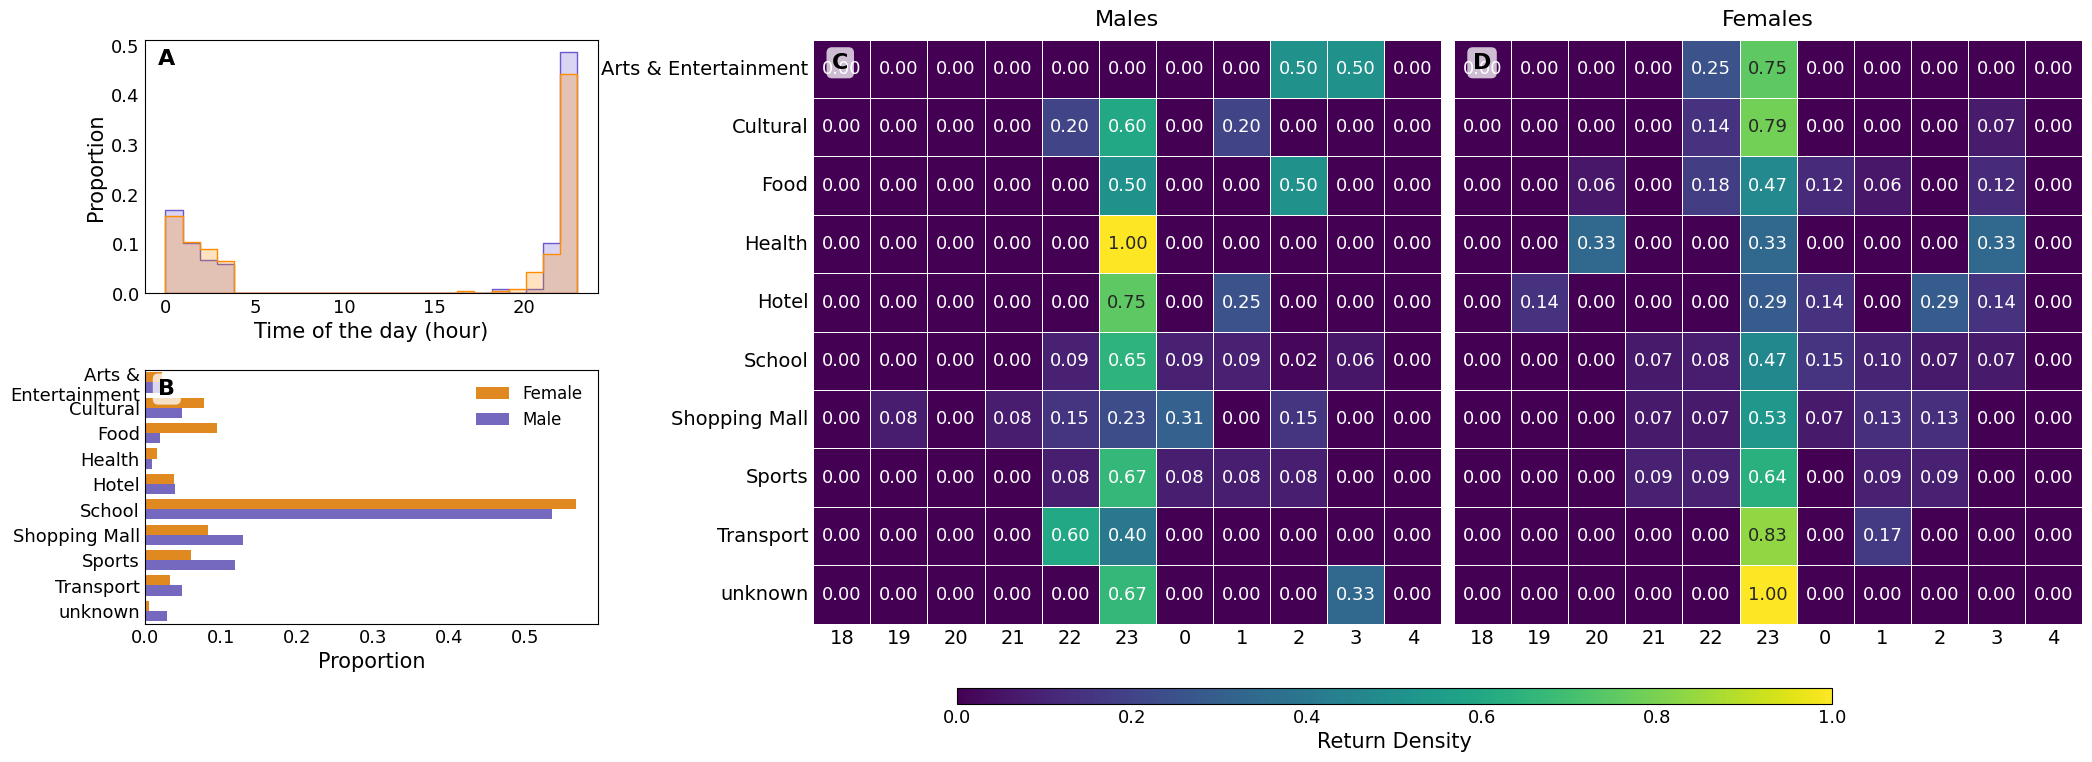

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from geopy.distance import geodesic

# ==========================================
# 1. PROCESAMIENTO DE DATOS Y LOGICA PREVIA
# ==========================================

def get_detailed_info(group):
    if len(group) < 2:
        return pd.Series([None, None, None], index=['penult_cat', 'dist_decision', 'hora_retorno'])
    
    inicio_loc = (group.iloc[0]['latitude'], group.iloc[0]['longitude'])
    punto_orig = group.iloc[-2]
    decision_loc = (punto_orig['latitude'], punto_orig['longitude'])
    dist_decision = geodesic(inicio_loc, decision_loc).km
    
    secuencia_actividades = group.iloc[:-1][~group.iloc[:-1]['POI_category'].str.contains('Residence|Home|Housing', case=False, na=False)]
    penult_cat = "Solo Home-related" if secuencia_actividades.empty else secuencia_actividades.iloc[-1]['POI_category']
    hora_retorno = group.iloc[-1]['time'].hour
            
    return pd.Series([penult_cat, dist_decision, hora_retorno], 
                     index=['penult_cat', 'dist_decision', 'hora_retorno'])

checkins_final = checkins_final.sort_values(['user_id', 'time'])
analisis_factores = checkins_final.groupby(['user_id', 'mov_day']).apply(get_detailed_info).reset_index()

generos = checkins_final.groupby(['user_id', 'mov_day'])['gender'].first().reset_index()
analisis_factores = analisis_factores.merge(generos, on=['user_id', 'mov_day'])
analisis_factores['gender_label'] = analisis_factores['gender'].map({0: 'Male', 1: 'Female'})

df_causas = analisis_factores[analisis_factores['dist_decision'] < 1000].copy()

# Preparar datos para el gráfico de barras de categorías
df_cats = df_causas[df_causas['penult_cat'] != "Solo Home-related"]
top_cats_idx = df_cats['penult_cat'].value_counts().nlargest(10).index
df_top_cats = df_cats[df_cats['penult_cat'].isin(top_cats_idx)].copy()
df_top_cats['penult_cat'] = df_top_cats['penult_cat'].replace('Arts & Entertainment', 'Arts &\nEntertainment')

prop_cat = (df_top_cats.groupby(['gender_label', 'penult_cat']).size() / 
            df_top_cats.groupby('gender_label').size()).reset_index(name='proporcion')

# Preparar datos para los heatmaps
df_filtrado = df_causas[df_causas['penult_cat'] != "Solo Home-related"].copy()
top_categories = df_filtrado['penult_cat'].value_counts().nlargest(10).index
df_cross = df_filtrado[df_filtrado['penult_cat'].isin(top_categories)].copy()
df_cross = df_cross.sort_values('penult_cat')
horas_interes = [18, 19, 20, 21, 22, 23, 0, 1, 2, 3, 4]


# Función auxiliar para pintar el heatmap
def plot_elegant_heatmap(data, gender_name, ax, color_map, target_hours, show_cbar=False):
    ct = pd.crosstab(data['penult_cat'], data['hora_retorno'])
    ct = ct.reindex(columns=range(24), fill_value=0)
    ct = ct[target_hours]
    conditional_prob = ct.div(ct.sum(axis=1), axis=0).fillna(0)
    
    im = sns.heatmap(conditional_prob, annot=True, fmt=".2f", 
                     annot_kws={"size": 13}, 
                     cmap=color_map, ax=ax, cbar=show_cbar, linewidths=.5)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(gender_name, fontsize=16, pad=10) 
    ax.tick_params(axis='both', which='major', labelsize=14, length=0)
    return im


# ==========================================
# 3. DISEÑO DEL PANEL ASIMÉTRICO (GridSpec)
# ==========================================

fig = plt.figure(figsize=(25, 8))
plt.rc('font', size=13)
custom_palette = {'Male': 'slateblue', 'Female': 'darkorange'}

# Malla principal
gs_main = fig.add_gridspec(1, 2, width_ratios=[5, 14], wspace=0.25)

# Sub-malla Izquierda
gs_left = gs_main[0].subgridspec(2, 1, hspace=0.3)
ax_hist = fig.add_subplot(gs_left[0, 0])
ax_bar = fig.add_subplot(gs_left[1, 0])

# Sub-malla Derecha
gs_right = gs_main[1].subgridspec(1, 2, wspace=0.02)
ax_heat_m = fig.add_subplot(gs_right[0, 0])
ax_heat_f = fig.add_subplot(gs_right[0, 1], sharey=ax_heat_m)


# --- PLOT 1: Histograma Hora Retorno (Arriba Izquierda) ---
sns.histplot(data=df_causas, x='hora_retorno', hue='gender_label', bins=24, 
             stat="proportion", common_norm=False, element="step", ax=ax_hist,
             palette=custom_palette)
ax_hist.set_xlabel('Time of the day (hour)', fontsize=15)
ax_hist.set_ylabel('Proportion', fontsize=15)
ax_hist.tick_params(axis='both', labelsize=13, length=0)
ax_hist.legend(frameon=False, title=False, fontsize=12)


# --- PLOT 2: Proporción Categorías (Abajo Izquierda) ---
sns.barplot(data=prop_cat, y='penult_cat', x='proporcion', hue='gender_label', ax=ax_bar, palette=custom_palette, capsize=14)
ax_bar.set_xlabel('Proportion', fontsize=15)
ax_bar.set_ylabel('')
ax_bar.tick_params(axis='both', labelsize=13, length=0)
ax_bar.legend(frameon=False, title=False, fontsize=12)


# --- PLOT 3 & 4: Heatmaps de Comportamiento (Derecha) ---
mappable_m = plot_elegant_heatmap(df_cross[df_cross['gender_label'] == 'Male'], 'Males', ax_heat_m, "viridis", horas_interes, show_cbar=False)
mappable_f = plot_elegant_heatmap(df_cross[df_cross['gender_label'] == 'Female'], 'Females', ax_heat_f, "viridis", horas_interes, show_cbar=False)

# Ocultamos por completo el eje Y del segundo heatmap para mantener la continuidad estética
ax_heat_f.set_ylabel('')
ax_heat_f.get_yaxis().set_visible(False)


# --- COLORBAR COMPARATIVO ---
cbar_ax = fig.add_axes([0.45, 0.05, 0.35, 0.02]) 
cbar = fig.colorbar(ax_heat_m.get_children()[0], cax=cbar_ax, orientation='horizontal')
cbar.set_label('Return Density', fontsize=15)
cbar.ax.tick_params(labelsize=13, length=0)

plt.subplots_adjust(bottom=0.15)

label_style = dict(
    fontsize=16,
    fontweight='bold',
    bbox=dict(
        facecolor='white',
        edgecolor='none',
        alpha=0.75,
        boxstyle='round,pad=0.25'
    )
)

ax_hist.text(0.03, 0.90, 'A', transform=ax_hist.transAxes, **label_style)
ax_bar.text(0.03, 0.90, 'B', transform=ax_bar.transAxes, **label_style)
ax_heat_m.text(0.03, 0.95, 'C', transform=ax_heat_m.transAxes, **label_style)
ax_heat_f.text(0.03, 0.95, 'D', transform=ax_heat_f.transAxes, **label_style)
plt.savefig('figs/factors_and_return_combined.png', dpi=300, bbox_inches='tight')
plt.show()

# DUAL PROBABILITY

In [52]:
def random_walk_dual_logic_python(n_total, start_poi, horas_reales, l_star, kbt_a, p_0, pois_array, t_crit=22.5, beta=5.0):
    trajectory = [start_poi]
    l_visited = 1
    for i in range(1, n_total):
        exponent_step = -(l_visited - l_star) / kbt_a
        p_sigmoid_step = 1 / (1 + np.exp(exponent_step))
        p_step = np.clip((p_sigmoid_step - p_0) / (1 - p_0), 0.0, 1.0)
        t_actual = horas_reales[i]
        if t_actual < 4: t_actual += 24
        p_time = 1 / (1 + np.exp(-beta * (t_actual - t_crit)))
        p_return = 1 - (1 - p_step) * (1 - p_time)
        if np.random.random() < p_return:
            old_loc = np.random.choice(trajectory)
            trajectory.append(old_loc)
        else:
            new_loc = np.random.choice(pois_array)
            trajectory.append(new_loc)
            l_visited += 1
    return np.array(trajectory)

def run_montecarlo_comparison(checkins, n_iterations, l_star, deviation):
    poi_to_int = {poi: i for i, poi in enumerate(checkins['POI_id'].unique())}
    pois_array = np.array(list(poi_to_int.values()))
    
    checkins_copy = checkins.copy()
    checkins_copy['POI_int'] = checkins_copy['POI_id'].map(poi_to_int)
    # Horas en formato decimal
    checkins_copy['hour_dec'] = checkins_copy['time'].dt.hour + checkins_copy['time'].dt.minute / 60.0
    
    groups = []
    for (u_id, day), group in checkins_copy.groupby(['user_id', 'adj_day_4am']):
        if len(group) >= 2:
            groups.append({
                'n': len(group), 
                'start': group.iloc[0]['POI_int'], 
                'times': group['hour_dec'].values
            })
            
    A, kbt_a = 1.0, (deviation * np.sqrt(3)) / np.pi
    p_0 = 1 / (1 + np.exp(l_star / kbt_a))
    
    hc_original = []
    hu_original = []
    hc_dual = []
    hu_dual = []
    
    def compute_hu_internal(traj):
        if len(traj) < 2: 
            return 0.0
        _, counts = np.unique(traj, return_counts=True)
        probs = counts / len(traj)
        probs = probs[(probs > 0) & (probs < 1)]
        
        if len(probs) == 0:
            return 0.0
        hu = -np.sum(probs * np.log2(probs))
        if hu < 1e-12: 
            return 0.0
            
        return float(hu)

    print(f"Simulando {n_iterations} iteraciones comparativas (Hc y Hu)...")
    for _ in tqdm(range(n_iterations)):
        for g in groups:
            traj_orig = random_walk_logic_python(g['n'], g['start'], l_star, kbt_a, p_0, pois_array)
            hc_original.append(compute_hc_python(traj_orig))
            hu_original.append(compute_hu_internal(traj_orig))
            traj_dual = random_walk_dual_logic_python(g['n'], g['start'], g['times'], l_star, kbt_a, p_0, pois_array)
            hc_dual.append(compute_hc_python(traj_dual))
            hu_dual.append(compute_hu_internal(traj_dual))
            
    return np.array(hc_original), np.array(hu_original), np.array(hc_dual), np.array(hu_dual)

# --- EJECUCIÓN ---
hc_orig, hu_orig, hc_dual, hu_dual = run_montecarlo_comparison(checkins, 20, 8.4204, 7.2140)

# Verificación rápida de medias
print(f"\nResultados Promedio:")
print(f"Original -> Hc: {np.nanmean(hc_orig):.3f}, Hu: {np.nanmean(hu_orig):.3f}")
print(f"Dual     -> Hc: {np.nanmean(hc_dual):.3f}, Hu: {np.nanmean(hu_dual):.3f}")

# Ejecución

hc_orig, hc_dual = run_montecarlo_comparison(checkins, 10, 8.4204, 7.2140)



Simulando 20 iteraciones comparativas (Hc y Hu)...


100%|██████████| 20/20 [00:42<00:00,  2.15s/it]



Resultados Promedio:
Original -> Hc: 2.762, Hu: 3.056
Dual     -> Hc: 2.048, Hu: 2.011
Simulando 10 iteraciones comparativas (Hc y Hu)...


100%|██████████| 10/10 [00:21<00:00,  2.14s/it]


ValueError: too many values to unpack (expected 2)

Simulando Random Walks puros basados en las longitudes de las secuencias...


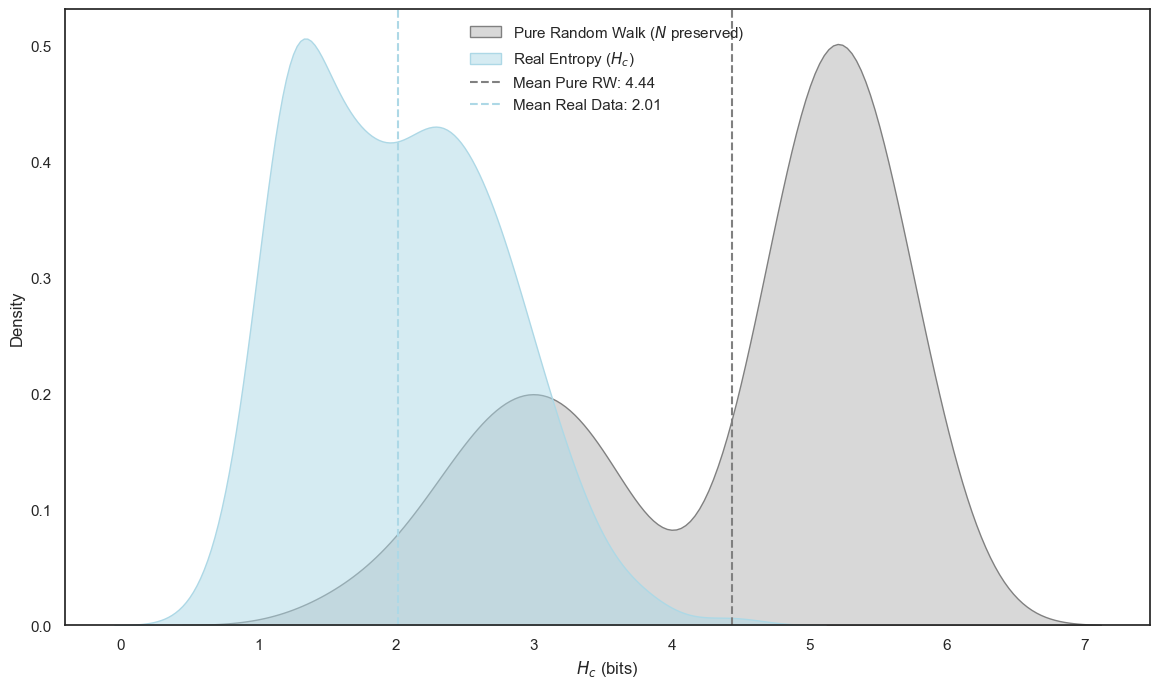

Reducción de entropía correlacionada (Hc) frente al azar puro: 54.61%


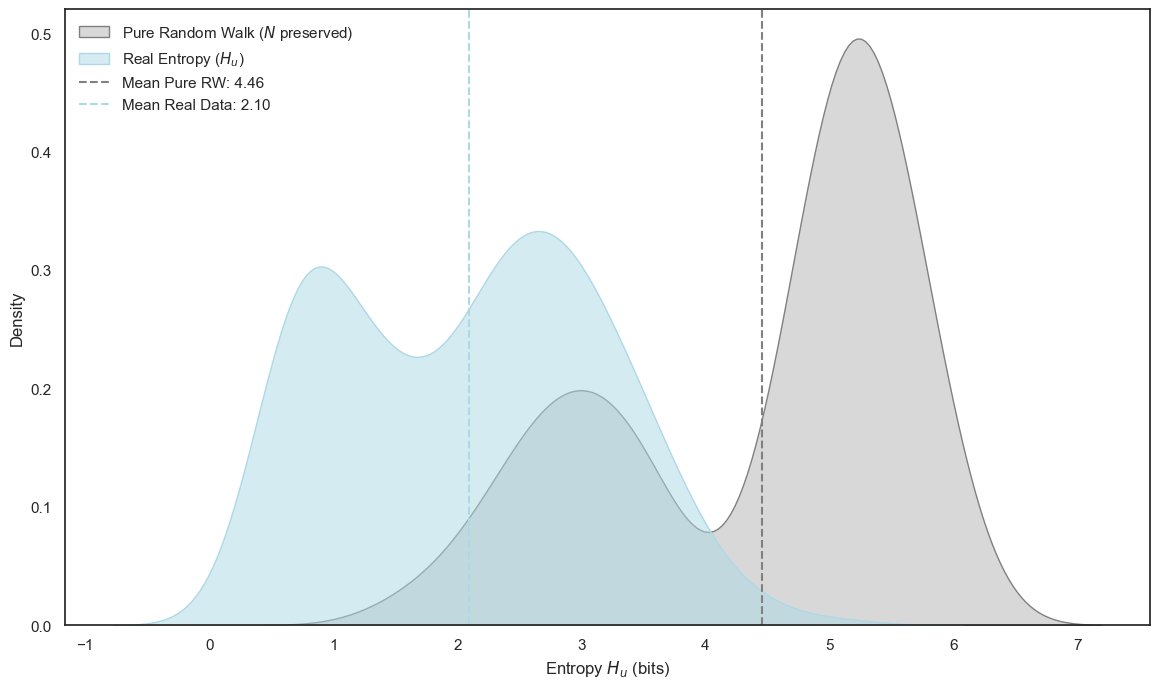

Reducción de entropía no correlacionada (Hu) frente al azar puro: 52.98%


In [56]:
# =============================================================================
# 1. SIMULACIÓN EXCLUSIVA DEL RANDOM WALK PURO ($N$ preservado)
# =============================================================================

hc_rw_pure = []
hu_rw_pure = []

# Catálogo único de POIs basado en tu columna global de checkins
pois_array = np.array(list(checkins_gender['POI_id'].unique()))

print("Simulando Random Walks puros basados en las longitudes de las secuencias...")
# Iteramos directamente sobre las secuencias guardadas para replicar su longitud N
for seq in user_sequences_return:
    N = len(seq)
    if N >= 2:
        # Generación del Random Walk Puro (Equiprobable con reemplazo del catálogo global)
        rw_trajectory = np.random.choice(pois_array, size=N, replace=True)
        
        # Calcular métricas únicamente para la trayectoria sintética aleatoria
        hc_rw_pure.append(compute_hc_python(rw_trajectory))
        hu_rw_pure.append(compute_hu_internal(rw_trajectory))

# Conversión a estructuras estables de Numpy
hc_rw_pure = np.array(hc_rw_pure)
hu_rw_pure = np.array(hu_rw_pure)

# =============================================================================
# 2. GENERACIÓN DE GRÁFICOS COMPARATIVOS CON TUS VALORES ANTERIORES
# =============================================================================

# Gráfico para Hc (Entropía Correlacionada - Temporal)
plt.figure(figsize=(14, 8))
sns.kdeplot(hc_rw_pure, fill=True, color='gray', label='Pure Random Walk ($N$ preserved)', alpha=0.3)
sns.kdeplot(hc_values_return, fill=True, color='lightblue', label='Real Entropy ($H_c$)', alpha=0.5)

plt.axvline(np.nanmean(hc_rw_pure), color='gray', linestyle='--', label=f'Mean Pure RW: {np.nanmean(hc_rw_pure):.2f}')
plt.axvline(np.nanmean(hc_values_return), color='lightblue', linestyle='--', label=f'Mean Real Data: {np.nanmean(hc_values_return):.2f}')

plt.xlabel('$H_c$ (bits)')
plt.ylabel('Density')
plt.legend(frameon=False)
plt.savefig('figs/pure_rw_comparison_hc.png', dpi=300, bbox_inches='tight')
plt.show()

reduction_hc = ((np.nanmean(hc_rw_pure) - np.nanmean(hc_values_return)) / np.nanmean(hc_rw_pure)) * 100
print(f"Reducción de entropía correlacionada (Hc) frente al azar puro: {reduction_hc:.2f}%")

# Gráfico para Hu (Entropía No Correlacionada - Espacial)
plt.figure(figsize=(14, 8))
sns.kdeplot(hu_rw_pure, fill=True, color='gray', label='Pure Random Walk ($N$ preserved)', alpha=0.3)
sns.kdeplot(hu_values_return, fill=True, color='lightblue', label='Real Entropy ($H_u$)', alpha=0.5)

plt.axvline(np.nanmean(hu_rw_pure), color='gray', linestyle='--', label=f'Mean Pure RW: {np.nanmean(hu_rw_pure):.2f}')
plt.axvline(np.nanmean(hu_values_return), color='lightblue', linestyle='--', label=f'Mean Real Data: {np.nanmean(hu_values_return):.2f}')

plt.xlabel('Entropy $H_u$ (bits)')
plt.ylabel('Density')
plt.legend(frameon=False)
plt.savefig('figs/pure_rw_comparison_hu.png', dpi=300, bbox_inches='tight')
plt.show()

reduction_hu = ((np.nanmean(hu_rw_pure) - np.nanmean(hu_values_return)) / np.nanmean(hu_rw_pure)) * 100
print(f"Reducción de entropía no correlacionada (Hu) frente al azar puro: {reduction_hu:.2f}%")

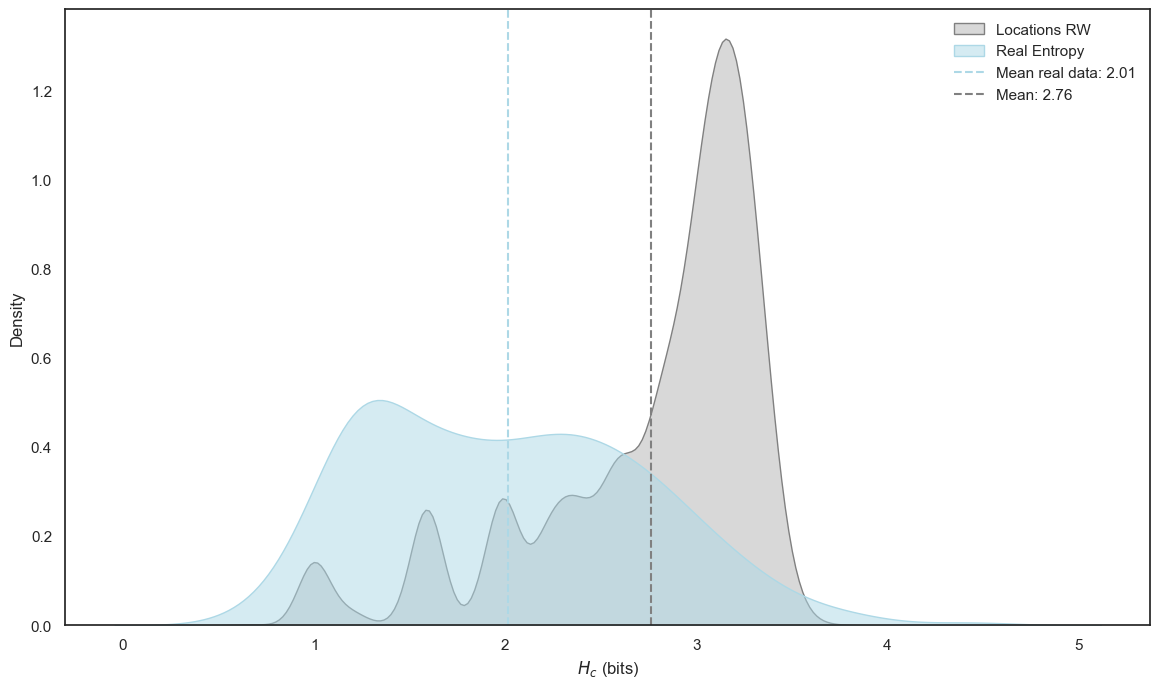

Reducción de entropía: 25.85%


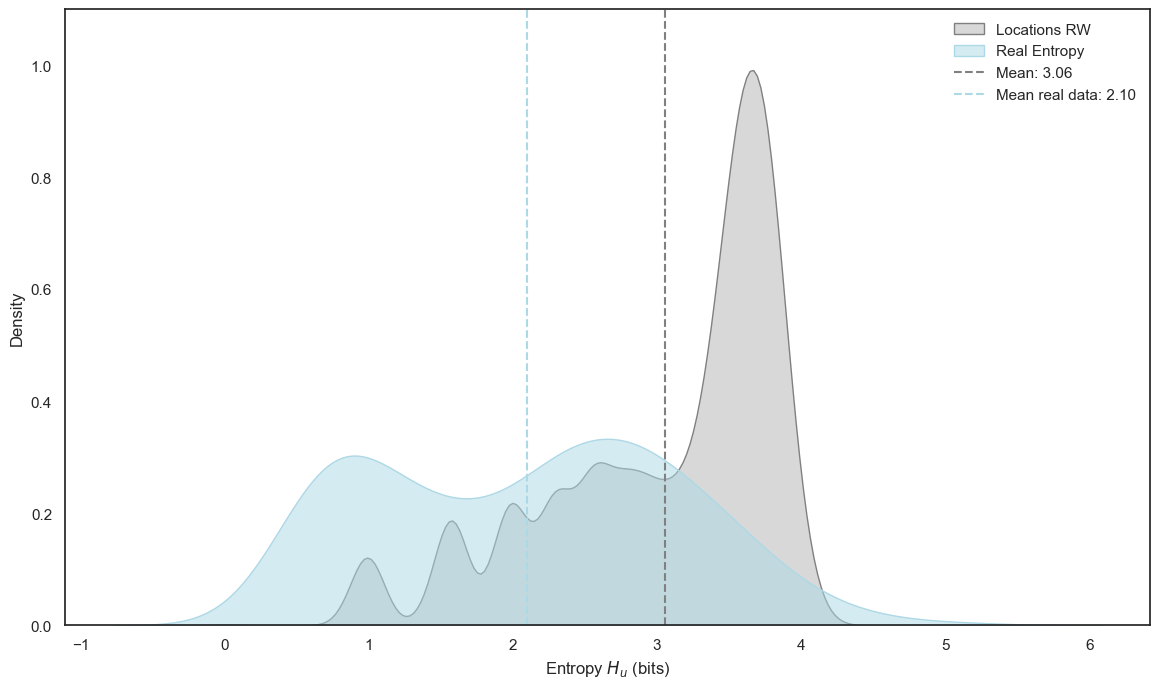

Reducción de entropía: 34.20%


In [53]:
plt.figure(figsize=(14, 8))

sns.kdeplot(hc_orig, fill=True, color='gray', label='Locations RW', alpha=0.3)
#sns.kdeplot(hc_dual, fill=True, color='darkorange', label='Locations + Time RW', alpha=0.5)
sns.kdeplot(hc_values_return, fill=True, color='lightblue', label='Real Entropy', alpha=0.5)
plt.axvline(np.nanmean(hc_values_return), color='lightblue', linestyle='--', label=f'Mean real data: {np.nanmean(hc_values_return):.2f}')
plt.axvline(np.nanmean(hc_orig), color='gray', linestyle='--', label=f'Mean: {np.nanmean(hc_orig):.2f}')
#plt.axvline(np.nanmean(hc_dual), color='darkorange', linestyle='--', label=f'Mean Dual: {np.nanmean(hc_dual):.2f}')

plt.xlabel('$H_c$ (bits)')
plt.ylabel('Density')
plt.legend(frameon=False)
plt.savefig('figs/dualentropyhc.png', dpi = 300, bbox_inches='tight')
plt.show()

print(f"Reducción de entropía: {((np.nanmean(hc_orig) - np.nanmean(hc_dual)) / np.nanmean(hc_orig) * 100):.2f}%")

plt.figure(figsize=(14, 8))

sns.kdeplot(hu_orig, fill=True, color='gray', label='Locations RW', alpha=0.3)
#sns.kdeplot(hu_dual, fill=True, color='darkorange', label='Locations + RW', alpha=0.5)
sns.kdeplot(hu_values_return, fill=True, color='lightblue', label='Real Entropy', alpha=0.5)

plt.axvline(np.nanmean(hu_orig), color='gray', linestyle='--', label=f'Mean: {np.nanmean(hu_orig):.2f}')
plt.axvline(np.nanmean(hu_values_return), color='lightblue', linestyle='--', label=f'Mean real data: {np.nanmean(hu_values_return):.2f}')
#plt.axvline(np.nanmean(hu_dual), color='darkorange', linestyle='--', label=f'Mean Dual: {np.nanmean(hu_dual):.2f}')

plt.xlabel('Entropy $H_u$ (bits)')
plt.ylabel('Density')
plt.legend(frameon=False)
plt.ylim(0,1.1)
plt.savefig('figs/dualentropyhu.png', dpi = 300, bbox_inches='tight')
plt.show()

print(f"Reducción de entropía: {((np.nanmean(hu_orig) - np.nanmean(hu_dual)) / np.nanmean(hu_orig) * 100):.2f}%")

non independent probabilities

In [ ]:
from tqdm import tqdm
def random_walk_synergic_logic_python(n_total, start_poi, horas_reales, l_star, kbt_a, beta, t_crit, pois_array):
    trajectory = [start_poi]
    l_visited = 1
    
    for i in range(1, n_total):
        # 1. PRESIÓN POR ETAPAS (crece con l_visited)
        # Normalizamos para que cuando l_visited == l_star, el término sea 0
        term_step = (l_visited - l_star) / kbt_a
        
        # 2. PRESIÓN POR TIEMPO (crece con t_actual)
        t_actual = horas_reales[i]
        if t_actual < 4: t_actual += 24
        # Normalizamos para que cuando t_actual == t_crit, el término sea 0
        term_time = beta * (t_actual - t_crit)
        
        # 3. COMBINACIÓN SINÉRGICA
        # Sumamos ambas presiones en un solo exponente
        exponent = term_step + term_time
        p_return = 1 / (1 + np.exp(-exponent))
        
        # Clip preventivo
        p_return = np.clip(p_return, 0.0, 1.0)
        
        if np.random.random() < p_return:
            old_loc = np.random.choice(trajectory)
            trajectory.append(old_loc)
        else:
            new_loc = np.random.choice(pois_array)
            trajectory.append(new_loc)
            l_visited += 1
            
    return np.array(trajectory)

def run_montecarlo_synergic_comparison(checkins, n_iterations, l_star, deviation, beta=1.5, t_crit=22.5):
    poi_to_int = {poi: i for i, poi in enumerate(checkins['POI_id'].unique())}
    pois_array = np.array(list(poi_to_int.values()))
    
    checkins_copy = checkins.copy()
    checkins_copy['POI_int'] = checkins_copy['POI_id'].map(poi_to_int)
    checkins_copy['hour_dec'] = checkins_copy['time'].dt.hour + checkins_copy['time'].dt.minute / 60.0
    
    groups = []
    for (u_id, day), group in checkins_copy.groupby(['user_id', 'adj_day_4am']):
        if len(group) >= 2:
            groups.append({
                'n': len(group), 
                'start': group.iloc[0]['POI_int'], 
                'times': group['hour_dec'].values
            })
            
    # Constantes para el modelo original
    kbt_a = (deviation * np.sqrt(3)) / np.pi
    p_0_original = 1 / (1 + np.exp(l_star / kbt_a))
    hc_original, hu_original = [], []
    hc_synergic, hu_synergic = [], []
    def compute_hu_internal(traj):
        if len(traj) < 2: return 0.0
        _, counts = np.unique(traj, return_counts=True)
        probs = counts / len(traj)
        probs = probs[(probs > 0) & (probs < 1)]
        if len(probs) == 0: return 0.0
        hu = -np.sum(probs * np.log2(probs))
        return float(max(0.0, hu))
    print(f"Simulando {n_iterations} iteraciones (Modelo Sinérgico)...")
    for _ in tqdm(range(n_iterations)):
        for g in groups:
            traj_orig = random_walk_logic_python(g['n'], g['start'], l_star, kbt_a, p_0_original, pois_array)
            hc_original.append(compute_hc_python(traj_orig))
            hu_original.append(compute_hu_internal(traj_orig))
            traj_syn = random_walk_synergic_logic_python(g['n'], g['start'], g['times'], l_star, kbt_a, beta, t_crit, pois_array)
            hc_synergic.append(compute_hc_python(traj_syn))
            hu_synergic.append(compute_hu_internal(traj_syn))
            
    return np.array(hc_original), np.array(hu_original), np.array(hc_synergic), np.array(hu_synergic)
hc_orig, hu_orig, hc_syn, hu_syn = run_montecarlo_synergic_comparison(checkins, 20, 8.4204, 7.2140, beta=1.6)

#DYNAMIC
def random_walk_dynamic_logic_python(n_total, start_poi, horas_reales, l_star_max, kbt_a, beta, t_crit, pois_array):
    """
    Simula una trayectoria donde el umbral de exploración (l_star) 
    se encoge a medida que avanza el día.
    """
    trajectory = [start_poi]
    l_visited = 1
    
    for i in range(1, n_total):
        # Ajuste de hora (ciclo de 24h tras las 4 AM)
        t_actual = horas_reales[i]
        if t_actual < 4: t_actual += 24
        
        # Reducción dinámica del umbral l_star según la hora
        # A mayor t_actual, menor es el factor de reducción
        reduction_factor = 1 / (1 + np.exp(beta * (t_actual - t_crit)))
        l_star_efectivo = l_star_max * reduction_factor
        
        # Cálculo de la presión de retorno (sigmoide basada en fatiga actual vs umbral)
        exponent = (l_visited - l_star_efectivo) / kbt_a
        p_return = 1 / (1 + np.exp(-exponent))
        p_return = np.clip(p_return, 0.0, 1.0)
        
        if np.random.random() < p_return:
            # Regreso preferencial a un lugar ya visitado
            old_loc = np.random.choice(trajectory)
            trajectory.append(old_loc)
        else:
            # Exploración de un nuevo POI
            new_loc = np.random.choice(pois_array)
            trajectory.append(new_loc)
            l_visited += 1
            
    return np.array(trajectory)

def run_montecarlo_dynamic_comparison(checkins, n_iterations, l_star_max, deviation, beta=0.8, t_crit=20.0):
    poi_to_int = {poi: i for i, poi in enumerate(checkins['POI_id'].unique())}
    pois_array = np.array(list(poi_to_int.values()))
    checkins_copy = checkins.copy()
    checkins_copy['POI_int'] = checkins_copy['POI_id'].map(poi_to_int)
    checkins_copy['hour_dec'] = checkins_copy['time'].dt.hour + checkins_copy['time'].dt.minute / 60.0
    groups = []
    for (u_id, day), group in checkins_copy.groupby(['user_id', 'adj_day_4am']):
        if len(group) >= 2:
            groups.append({
                'n': len(group), 
                'start': group.iloc[0]['POI_int'], 
                'times': group['hour_dec'].values
            })
            
    kbt_a_base = (deviation * np.sqrt(3)) / np.pi
    hc_dynamic, hu_dynamic = [], []

    print(f"Simulando {n_iterations} iteraciones con heterogeneidad...")
    for _ in tqdm(range(n_iterations)):
        t_crit_sim = np.random.normal(t_crit, 1.2) 
        l_star_sim = np.random.normal(l_star_max, 1.0)
        
        for g in groups:
            traj_dyn = random_walk_dynamic_logic_python(
                g['n'], g['start'], g['times'], 
                l_star_sim, kbt_a_base, beta, t_crit_sim, pois_array
            )
            
            hc_dynamic.append(compute_hc_python(traj_dyn))
            hu_dynamic.append(compute_hu_internal(traj_dyn))
            
    return np.array(hc_dynamic), np.array(hu_dynamic)

# --- 4. EJECUCIÓN ---

# Parámetros sugeridos tras calibración
L_STAR_MAX = 8.42    # Máximo de paradas por la mañana
DEVIATION = 7.21     # Ruido del proceso de decisión
BETA_TIME = 1.6     # Suavidad de la transición temporal
T_CRITICAL = 23.0    # Hora en la que el umbral cae al 50%

hc_dyn, hu_dyn = run_montecarlo_dynamic_comparison(
    checkins, 
    n_iterations=20, 
    l_star_max=L_STAR_MAX, 
    deviation=DEVIATION, 
    beta=BETA_TIME, 
    t_crit=T_CRITICAL
)

Simulando 20 iteraciones (Modelo Sinérgico)...


100%|██████████| 20/20 [00:37<00:00,  1.88s/it]


Simulando 20 iteraciones con heterogeneidad...


  0%|          | 0/20 [00:00<?, ?it/s]


NameError: name 'compute_hu_internal' is not defined

# QUINA DISTRIBUCIO EXPLICA MILLOR L'ENTROPIA REAL?

## definim les diferents maneres de vincular l'hora del dia amb el número de localitzacions visitades

In [56]:
res = run_montecarlo_comparison(checkins, n_iterations=15, l_star_max=8.42, deviation=7.21)
for l in res.keys():
    kl = calculate_kl_divergence(hc_values_return, res[l]['hc'])
    print(f"KL Divergence Model [{l}]: {kl:.4f}")

Simulando 8 modelos x 15 iteraciones...


100%|██████████| 15/15 [01:53<00:00,  7.55s/it]

KL Divergence Model [synergic]: 30.3567
KL Divergence Model [dynamic]: 28.1836
KL Divergence Model [gating]: 33.6016
KL Divergence Model [acceleration]: 237.3763
KL Divergence Model [budget]: 185.3583
KL Divergence Model [critical_product]: 27.7207
KL Divergence Model [log_exhaustion]: 33.8846
KL Divergence Model [circadian_rythm]: 249.0272


## parametres optims

In [60]:
print("--- MÉTRICA DE SIMILITUD (JENSEN-SHANNON DISTANCE) ---")
for l in res.keys():
    jsd_val = calculate_jsd(hc_values_return, res[l]['hc'])
    print(f"JSD Model [{l}]: {jsd_val:.4f}")

l_test_range = [8.42]
beta_test_range = [1.4,1.45,1.55,1.65,1.75,1.5,1.6,1.7]
best_p = optimize_budget_jsd(checkins, hc_values_return, l_test_range, beta_test_range)
print(f"\nConfiguración recomendada: L_star={best_p['l']}, Beta={best_p['beta']}")

--- MÉTRICA DE SIMILITUD (JENSEN-SHANNON DISTANCE) ---
JSD Model [synergic]: 0.6696
JSD Model [dynamic]: 0.4530
JSD Model [gating]: 0.5966
JSD Model [acceleration]: 0.6413
JSD Model [budget]: 0.6028
JSD Model [critical_product]: 0.6481
JSD Model [log_exhaustion]: 0.6570
JSD Model [circadian_rythm]: 0.7528
parametres that minimize JSD (Total pruebas: 8)...
L_star: 8.42 | Beta: 1.40 -> JSD: 0.6131
L_star: 8.42 | Beta: 1.45 -> JSD: 0.6099
L_star: 8.42 | Beta: 1.55 -> JSD: 0.6163
L_star: 8.42 | Beta: 1.65 -> JSD: 0.6143
L_star: 8.42 | Beta: 1.75 -> JSD: 0.6078
L_star: 8.42 | Beta: 1.50 -> JSD: 0.6198
L_star: 8.42 | Beta: 1.60 -> JSD: 0.6166
L_star: 8.42 | Beta: 1.70 -> JSD: 0.6124

Configuración recomendada: L_star=8.42, Beta=1.75


# comparació models de retorn

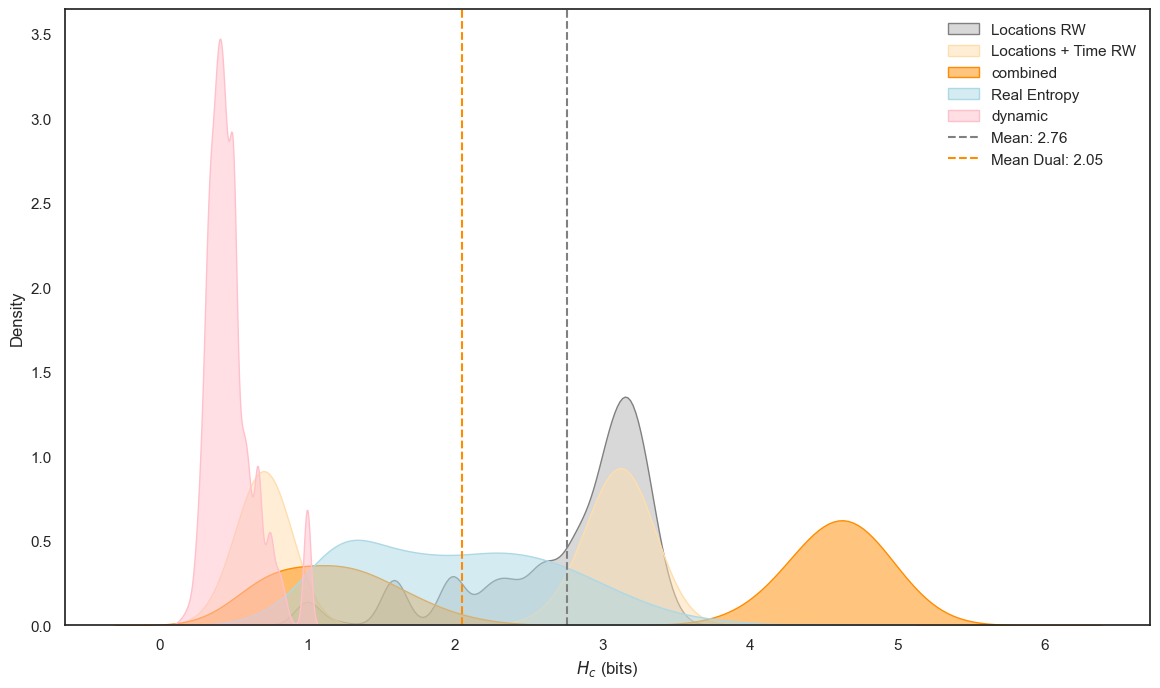

Reducción de entropía: 25.82%


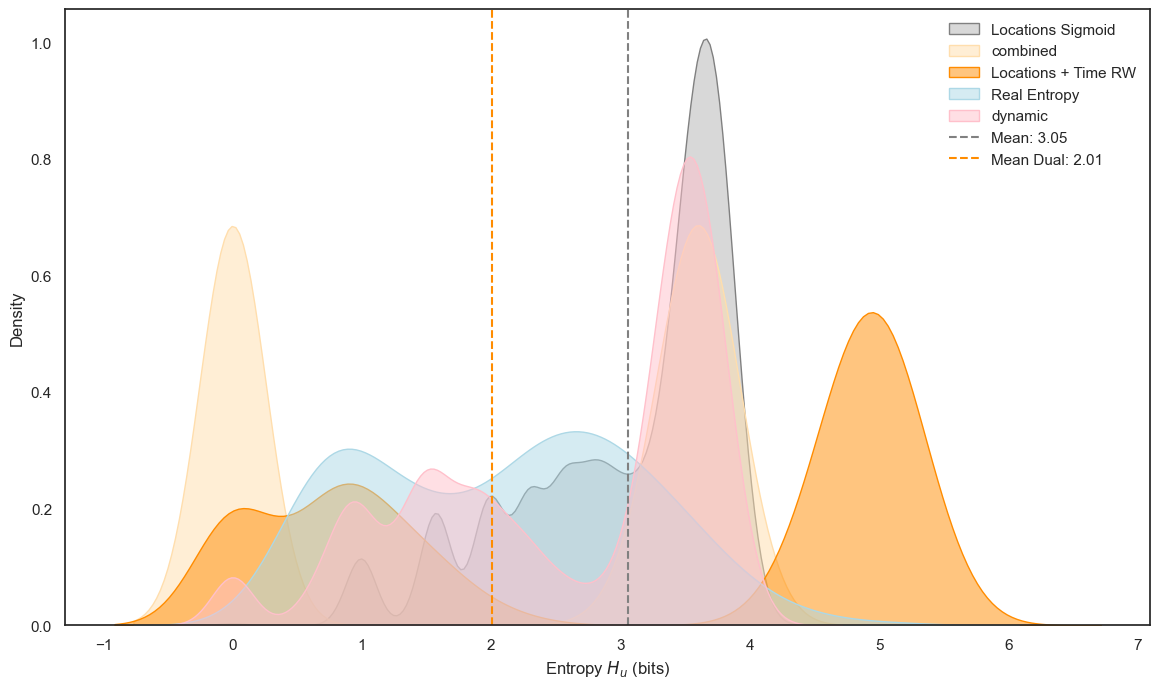

Reducción de entropía: 34.21%


In [ ]:
plt.figure(figsize=(14, 8))

sns.kdeplot(hc_orig, fill=True, color='gray', label='Locations RW', alpha=0.3)
sns.kdeplot(hc_dual, fill=True, color='navajowhite', label='Locations + Time RW', alpha=0.5)
sns.kdeplot(hc_syn, fill=True, color='darkorange', label='combined', alpha=0.5)
sns.kdeplot(hc_values_return, fill=True, color='lightblue', label='Real Entropy', alpha=0.5)
sns.kdeplot(hc_dyn, fill=True, color='pink', label='dynamic', alpha=0.5)
plt.axvline(np.nanmean(hc_orig), color='gray', linestyle='--', label=f'Mean: {np.nanmean(hc_orig):.2f}')
plt.axvline(np.nanmean(hc_dual), color='darkorange', linestyle='--', 
            label=f'Mean Dual: {np.nanmean(hc_dual):.2f}')

plt.xlabel('$H_c$ (bits)')
plt.ylabel('Density')
plt.legend(frameon=False)
plt.savefig('figs/dualentropyhc.png', dpi = 300, bbox_inches='tight')
plt.show()

print(f"Reducción de entropía: {((np.nanmean(hc_orig) - np.nanmean(hc_dual)) / np.nanmean(hc_orig) * 100):.2f}%")

plt.figure(figsize=(14, 8))

sns.kdeplot(hu_orig, fill=True, color='gray', label='Locations Sigmoid', alpha=0.3)
sns.kdeplot(hu_dual, fill=True, color='navajowhite', label='combined', alpha=0.5)
sns.kdeplot(hu_syn, fill=True, color='darkorange', label='Locations + Time RW', alpha=0.5)
sns.kdeplot(hu_values_return, fill=True, color='lightblue', label='Real Entropy', alpha=0.5)
sns.kdeplot(hu_dyn, fill=True, color='pink', label='dynamic', alpha=0.5)

plt.axvline(np.nanmean(hu_orig), color='gray', linestyle='--', label=f'Mean: {np.nanmean(hu_orig):.2f}')
plt.axvline(np.nanmean(hu_dual), color='darkorange', linestyle='--', 
            label=f'Mean Dual: {np.nanmean(hu_dual):.2f}')

plt.xlabel('Entropy $H_u$ (bits)')
plt.ylabel('Density')
plt.legend(frameon=False)
plt.savefig('figs/dualentropyhu.png', dpi = 300, bbox_inches='tight')
plt.show()

print(f"Reducción de entropía: {((np.nanmean(hu_orig) - np.nanmean(hu_dual)) / np.nanmean(hu_orig) * 100):.2f}%")

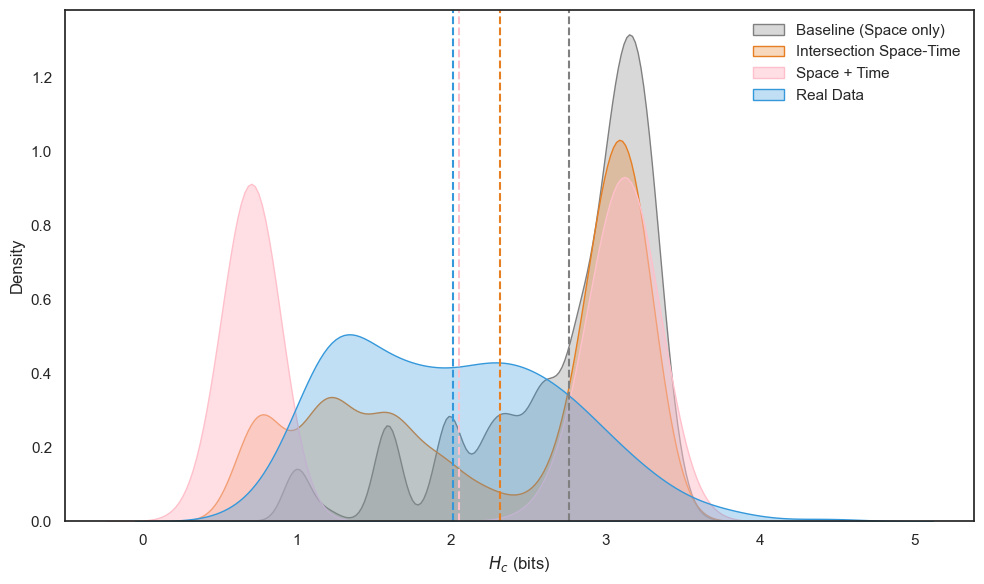

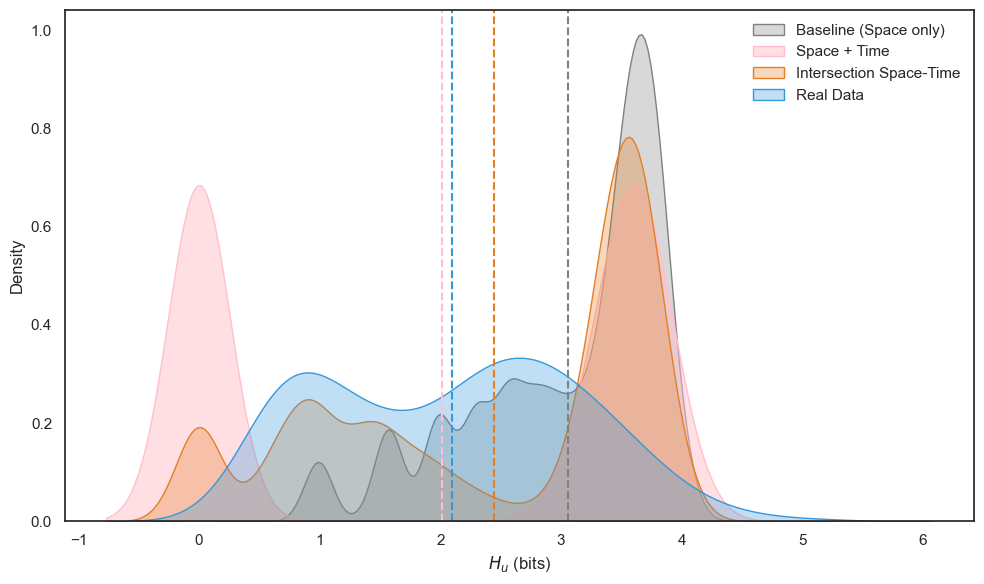

Distancia al valor real (Baseline): 0.7482
Distancia al valor real (Tu Modelo): 0.0341
Tu modelo explica un 95.44% mejor la predecibilidad que el baseline.


In [54]:
best_tc=23
hc_crit, hu_crit = run_simulation(checkins, 20, l_star, deviation, best_beta, best_tc, logic='critical_product_max')

plt.figure(figsize=(10, 6))
sns.set_theme(style="white")

sns.kdeplot(hc_orig, fill=True, color='gray', label='Baseline (Space only)', alpha=0.3)
sns.kdeplot(hc_crit, fill=True, color='#e67e22', label='Intersection Space-Time', alpha=0.3)
sns.kdeplot(hc_dual, fill=True, color='pink', label='Space + Time', alpha=0.5)
sns.kdeplot(hc_values_return, fill=True, color='#3498db', label='Real Data', alpha=0.3)

plt.axvline(np.nanmean(hc_orig), color='gray', linestyle='--', linewidth=1.5)
plt.axvline(np.nanmean(hc_crit), color='#e67e22', linestyle='--', linewidth=1.5)
plt.axvline(np.nanmean(hc_dual), color='pink', linestyle='--', linewidth=1.5)
plt.axvline(np.nanmean(hc_values_return), color='#3498db', linestyle='--', linewidth=1.5)

plt.xlabel('$H_c$ (bits)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

sns.kdeplot(hu_orig, fill=True, color='gray', label='Baseline (Space only)', alpha=0.3)
sns.kdeplot(hu_dual, fill=True, color='pink', label='Space + Time', alpha=0.5)
sns.kdeplot(hu_crit, fill=True, color='#e67e22', label='Intersection Space-Time', alpha=0.3)
sns.kdeplot(hu_values_return, fill=True, color='#3498db', label='Real Data', alpha=0.3)

plt.axvline(np.nanmean(hu_orig), color='gray', linestyle='--', linewidth=1.5)
plt.axvline(np.nanmean(hu_crit), color='#e67e22', linestyle='--', linewidth=1.5)
plt.axvline(np.nanmean(hu_dual), color='pink', linestyle='--', linewidth=1.5)
plt.axvline(np.nanmean(hu_values_return), color='#3498db', linestyle='--', linewidth=1.5)

plt.xlabel('$H_u$ (bits)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

error_modelo_base = abs(np.nanmean(hc_orig) - np.nanmean(hc_values_return))
error_tu_modelo = abs(np.nanmean(hc_dual) - np.nanmean(hc_values_return))

print(f"Distancia al valor real (Baseline): {error_modelo_base:.4f}")
print(f"Distancia al valor real (Tu Modelo): {error_tu_modelo:.4f}")

if error_tu_modelo < error_modelo_base:
    mejora = (1 - (error_tu_modelo / error_modelo_base)) * 100
    print(f"Tu modelo explica un {mejora:.2f}% mejor la predecibilidad que el baseline.")

In [147]:
# --- CÁLCULO DE DISTANCIAS KL ---

# Para Hc (Entropía Corregida)
kl_hc_dual = calculate_kl_divergence(hc_values_return, hc_dual)
kl_hc_crit = calculate_kl_divergence(hc_values_return, hc_crit)

# Para Hu (Entropía No Corregida)
kl_hu_dual = calculate_kl_divergence(hu_values_return, hu_dual)
kl_hu_crit = calculate_kl_divergence(hu_values_return, hu_crit)

# --- VISUALIZACIÓN DE RESULTADOS ---

print("======= REPORTE DE FIDELIDAD (KL DIVERGENCE) =======")
print(f"{'Métrica':<20} | {'Modelo Dual':<15} | {'Modelo Crítico':<15}")
print("-" * 60)
print(f"{'Distancia en Hc':<20} | {kl_hc_dual:15.4f} | {kl_hc_crit:15.4f}")
print(f"{'Distancia en Hu':<20} | {kl_hu_dual:15.4f} | {kl_hu_crit:15.4f}")
print("-" * 60)

# Determinación del mejor modelo
mejor_hc = "Crítico" if kl_hc_crit < kl_hc_dual else "Dual"
mejor_hu = "Crítico" if kl_hu_crit < kl_hu_dual else "Dual"

print(f"\nConclusión para Hc: El mejor ajuste lo da el modelo {mejor_hc.upper()}.")
print(f"Conclusión para Hu: El mejor ajuste lo da el modelo {mejor_hu.upper()}.")

# Cálculo de mejora porcentual (opcional, basado en KL)
if kl_hc_crit < kl_hc_dual:
    mejora_kl = (1 - (kl_hc_crit / kl_hc_dual)) * 100
    print(f"\nEl modelo Crítico reduce la divergencia KL en un {mejora_kl:.2f}% respecto al Dual en Hc.")


# 1. Calcular medias de la realidad
m_real_hc = np.nanmean(hc_values_return)
m_real_hu = np.nanmean(hu_values_return)

# 2. Calcular diferencias para el Modelo Dual (Espacio + Tiempo)
diff_hc_dual = abs(np.nanmean(hc_dual) - m_real_hc)
diff_hu_dual = abs(np.nanmean(hu_dual) - m_real_hu)

# 3. Calcular diferencias para el Modelo Crítico (Intersección)
diff_hc_crit = abs(np.nanmean(hc_crit) - m_real_hc)
diff_hu_crit = abs(np.nanmean(hu_crit) - m_real_hu)

# --- OUTPUT DE RESULTADOS ---
print("DIFERENCIAS DE MEDIAS RESPECTO AL VALOR REAL")
print("-" * 50)
print(f"MODELO DUAL (Espacio + Tiempo):")
print(f"  > Diferencia en Hc: {diff_hc_dual:.4f}")
print(f"  > Diferencia en Hu: {diff_hu_dual:.4f}")
print("-" * 50)
print(f"MODELO CRÍTICO (Intersección):")
print(f"  > Diferencia en Hc: {diff_hc_crit:.4f}")
print(f"  > Diferencia en Hu: {diff_hu_crit:.4f}")
print("-" * 50)

# Conclusión rápida
if diff_hc_crit < diff_hc_dual:
    print("Conclusión: El Modelo Crítico es más preciso en la media de Hc.")
else:
    print("Conclusión: El Modelo Dual es más preciso en la media de Hc.")

======= REPORTE DE FIDELIDAD (KL DIVERGENCE) =======
Métrica              | Modelo Dual     | Modelo Crítico 
------------------------------------------------------------
Distancia en Hc      |        312.7305 |         28.3415
Distancia en Hu      |        274.8312 |         25.0307
------------------------------------------------------------

Conclusión para Hc: El mejor ajuste lo da el modelo CRÍTICO.
Conclusión para Hu: El mejor ajuste lo da el modelo CRÍTICO.

El modelo Crítico reduce la divergencia KL en un 90.94% respecto al Dual en Hc.
DIFERENCIAS DE MEDIAS RESPECTO AL VALOR REAL
--------------------------------------------------
MODELO DUAL (Espacio + Tiempo):
  > Diferencia en Hc: 0.0344
  > Diferencia en Hu: 0.0865
--------------------------------------------------
MODELO CRÍTICO (Intersección):
  > Diferencia en Hc: 0.3384
  > Diferencia en Hu: 0.3999
--------------------------------------------------
Conclusión: El Modelo Dual es más preciso en la media de Hc.


In [75]:
from scipy.stats import ks_2samp, entropy
from scipy.spatial.distance import jensenshannon

def check_model_fidelity(real_data, sim_data):
    mean_real = np.nanmean(real_data)
    mean_sim = np.nanmean(sim_data)
    bias = mean_sim - mean_real
    
    d_ks, p_ks = ks_2samp(real_data[~np.isnan(real_data)], sim_data[~np.isnan(sim_data)])
    bins = np.linspace(min(np.nanmin(real_data), np.nanmin(sim_data)), 
                       max(np.nanmax(real_data), np.nanmax(sim_data)), 50)
    p_counts, _ = np.histogram(real_data, bins=bins, density=True)
    q_counts, _ = np.histogram(sim_data, bins=bins, density=True)
    jsd = jensenshannon(p_counts + 1e-10, q_counts + 1e-10)

    print("--- REPORTE DE FIDELIDAD DEL MODELO ---")
    print(f"1. Desplazamiento (Bias): {bias:.4f}")
    print(f"   (>0: El modelo es muy caótico | <0: El modelo es muy rígido)")
    print("-" * 40)
    print(f"2. Distancia KS (D): {d_ks:.4f}")
    print(f"   (Representa el solapamiento visual. Menos de 0.15 es excelente)")
    print("-" * 40)
    print(f"3. Divergencia Jensen-Shannon: {jsd:.4f}")
    print(f"   (0 = Perfecto. Si es > 0.5, las campanas apenas se tocan)")
    
    return {"bias": bias, "ks_d": d_ks, "jsd": jsd}

# Uso:
metrics = check_model_fidelity(hc_values_return, hc_crit)

--- REPORTE DE FIDELIDAD DEL MODELO ---
1. Desplazamiento (Bias): 0.3367
   (>0: El modelo es muy caótico | <0: El modelo es muy rígido)
----------------------------------------
2. Distancia KS (D): 0.3827
   (Representa el solapamiento visual. Menos de 0.15 es excelente)
----------------------------------------
3. Divergencia Jensen-Shannon: 0.3968
   (0 = Perfecto. Si es > 0.5, las campanas apenas se tocan)


In [77]:
kl_orig = calculate_kl_divergence(hc_values_return, hc_orig)
kl_syn  = calculate_kl_divergence(hc_values_return, hc_syn)
kl_dyn  = calculate_kl_divergence(hc_values_return, hc_dyn)
kl_dyn  = calculate_kl_divergence(hc_values_return, hc_crit)

print(f"KL Divergence (Original vs Real): {kl_orig:.4f}")
print(f"KL Divergence (Synergic vs Real): {kl_syn:.4f}")
print(f"KL Divergence (Dynamic vs Real): {kl_dyn:.4f}")
print(f"KL Divergence (Critical) vs Real): {kl_crit:.4f}")

NameError: name 'hc_dyn' is not defined

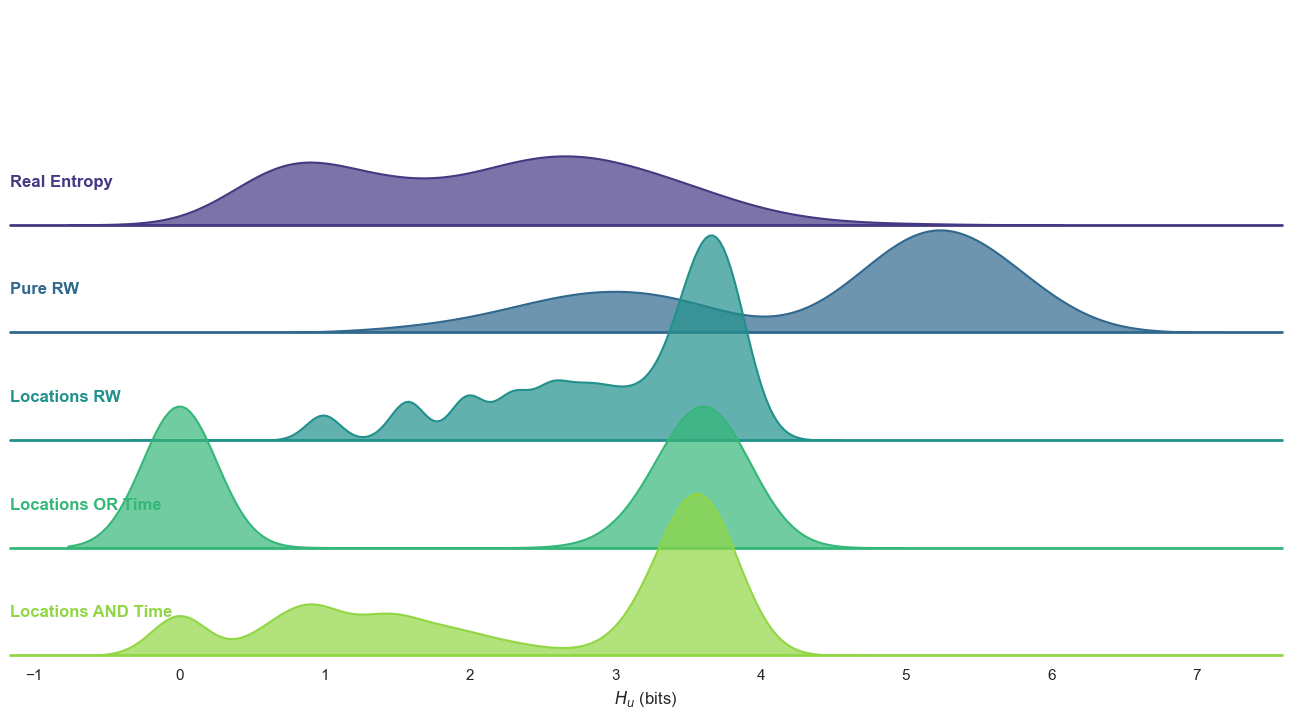

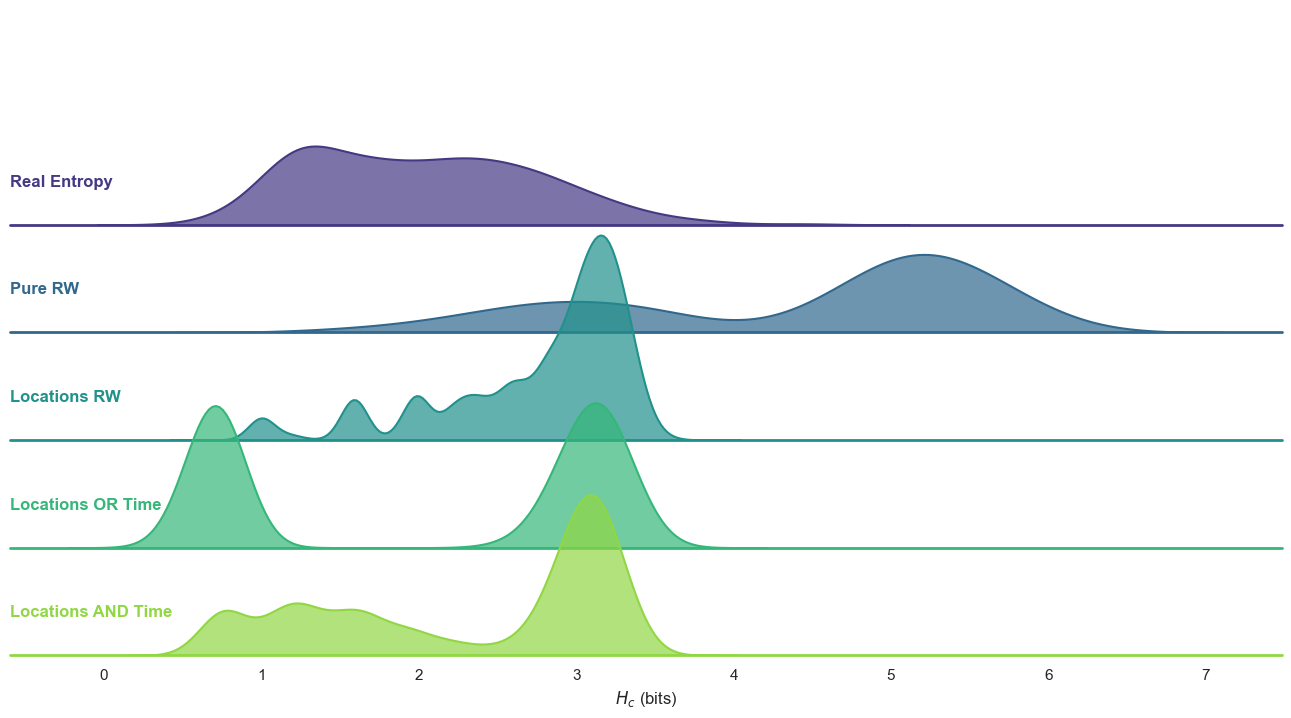

In [62]:
def plot_ridge_entropy(data_dict, title, xlabel, filename):
    df_list = []
    for label, values in data_dict.items():
        temp_df = pd.DataFrame({'Entropy': values})
        temp_df['Type'] = label
        df_list.append(temp_df)
    df = pd.concat(df_list)
    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
    g = sns.FacetGrid(df, row="Type", hue="Type", aspect=9, height=1.5, palette="viridis")
    g.map(sns.kdeplot, "Entropy", fill=True, alpha=0.7, lw=1.5)
    g.map(plt.axhline, y=0, lw=2, clip_on=False) 

    def label_text(x, color, label):
        ax = plt.gca()
        ax.text(0, .2, label, fontweight="bold", color=color,
                ha="left", va="center", transform=ax.transAxes)

    g.map(label_text, "Entropy")
    g.figure.subplots_adjust(hspace=-.5)
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)
    
    plt.xlabel(xlabel)
    plt.suptitle(title, fontsize=15)
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

"""
data_hc = {'Real Entropy': hc_values_return,'Combined': hc_syn,'Locations + Time RW': hc_dual,'Locations RW': hc_orig}
plot_ridge_entropy(data_hc, "Ridge Plot de Entropía $H_c$", "$H_c$ (bits)", "figs/ridge_hc.png")
data_hu = {'Real Entropy': hu_values_return,'Locations + Time RW': hu_syn,'Combined': hu_dual,'Locations Sigmoid': hu_orig}
plot_ridge_entropy(data_hu, "Ridge Plot de Entropía $H_u$", "Entropy $H_u$ (bits)", "figs/ridge_hu.png")
"""
data_hu = {'Real Entropy': hu_values_return, 'Pure RW':hu_rw_pure,'Locations RW': hu_orig, 'Locations OR Time': hu_dual,'Locations AND Time':hu_crit}
plot_ridge_entropy(data_hu, "", "$H_u$ (bits)", "figs/ridge_hu.png")
data_hc = {'Real Entropy': hc_values_return, 'Pure RW':hc_rw_pure,'Locations RW': hc_orig, 'Locations OR Time': hc_dual,'Locations AND Time':hc_crit}
plot_ridge_entropy(data_hc, "", "$H_c$ (bits)", "figs/ridge_hc.png")

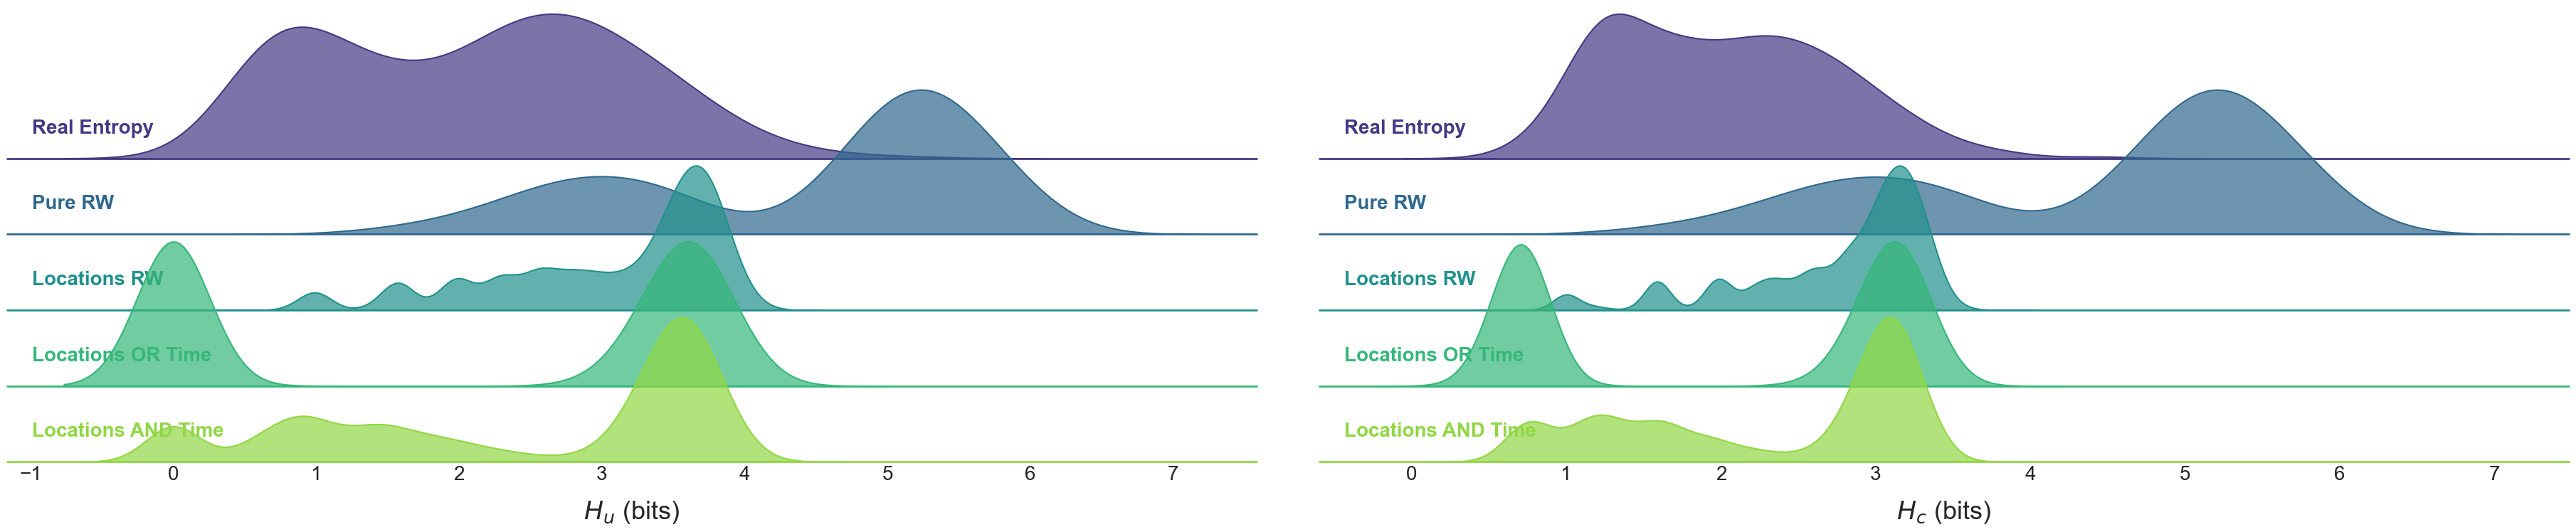

In [75]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_combined_ridge_entropy(
    data_hu, data_hc, xlabel_hu, xlabel_hc, filename
):
    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

    labels_hu = list(data_hu.keys())
    n_rows = len(labels_hu)

    fig = plt.figure(figsize=(40, 8))
    
    gs_main = fig.add_gridspec(1, 2, wspace=0.05)

    # Sub-malla para el bloque HU
    gs_hu = gs_main[0].subgridspec(n_rows, 1, hspace=-0.5)
    
    axs_hu = []
    for r in range(n_rows):
        share_ax = axs_hu[0] if r > 0 else None
        axs_hu.append(fig.add_subplot(gs_hu[r, 0], sharex=share_ax))

    palette_hu = sns.color_palette("viridis", n_rows)

    for idx, label in enumerate(labels_hu):
        ax = axs_hu[idx]
        values = data_hu[label]

        sns.kdeplot(
            x=values,
            fill=True,
            alpha=0.7,
            lw=1.5,
            color=palette_hu[idx],
            ax=ax,
        )
        ax.axhline(y=0, lw=2, color=palette_hu[idx], clip_on=False)
        ax.set_xlabel('')

        ax.text(
            0.02,
            0.2,
            label,
            fontweight="bold",
            color=palette_hu[idx],
            ha="left",
            va="center",
            transform=ax.transAxes,
            fontsize=20,
        )

        ax.set_yticks([])
        ax.set_ylabel("")
        
        # Ocultar los números del eje X excepto en la última línea
        if idx < n_rows - 1:
            ax.tick_params(axis="x", labelbottom=False, length=0)
        else:
            ax.tick_params(axis="both", which="major", labelsize=20, length=0)

        for spine in ax.spines.values():
            spine.set_visible(False)

    axs_hu[-1].set_xlabel(xlabel_hu, fontsize=26, labelpad=15)

    # Sub-malla para el bloque HC
    labels_hc = list(data_hc.keys())
    gs_hc = gs_main[1].subgridspec(n_rows, 1, hspace=-0.5)
    
    axs_hc = []
    for r in range(n_rows):
        share_ax = axs_hc[0] if r > 0 else None
        axs_hc.append(fig.add_subplot(gs_hc[r, 0], sharex=share_ax))

    palette_hc = sns.color_palette("viridis", n_rows)

    for idx, label in enumerate(labels_hc):
        ax = axs_hc[idx]
        values = data_hc[label]

        sns.kdeplot(
            x=values,
            fill=True,
            alpha=0.7,
            lw=1.5,
            color=palette_hc[idx],
            ax=ax,
        )
        ax.axhline(y=0, lw=2, color=palette_hc[idx], clip_on=False)
        ax.set_xlabel('')

        ax.text(
            0.02,
            0.2,
            label,
            fontweight="bold",
            color=palette_hc[idx],
            ha="left",
            va="center",
            transform=ax.transAxes,
            fontsize=20,
        )

        ax.set_yticks([])
        ax.set_ylabel("")
        
        # Ocultar los números del eje X excepto en la última línea
        if idx < n_rows - 1:
            ax.tick_params(axis="x", labelbottom=False, length=0)
        else:
            ax.tick_params(axis="both", which="major", labelsize=20, length=0)

        for spine in ax.spines.values():
            spine.set_visible(False)

    axs_hc[-1].set_xlabel(xlabel_hc, fontsize=26, labelpad=15)

    plt.subplots_adjust(left=0.05, right=0.95, bottom=0.15, top=0.95)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


data_hu = {
    "Real Entropy": hu_values_return,
    "Pure RW": hu_rw_pure,
    "Locations RW": hu_orig,
    "Locations OR Time": hu_dual,
    "Locations AND Time": hu_crit,
}
data_hc = {
    "Real Entropy": hc_values_return,
    "Pure RW": hc_rw_pure,
    "Locations RW": hc_orig,
    "Locations OR Time": hc_dual,
    "Locations AND Time": hc_crit,
}

plot_combined_ridge_entropy(
    data_hu, data_hc, "$H_u$ (bits)", "$H_c$ (bits)", "figs/ridge_combined.png"
)

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def create_ridge_plot(data_dict, subfig, title, xlabel):
    df_list = []

    for label, values in data_dict.items():
        tmp = pd.DataFrame({'Entropy': values})
        tmp['Type'] = label
        df_list.append(tmp)

    df = pd.concat(df_list)

    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

    g = sns.FacetGrid(
        df,
        row="Type",
        hue="Type",
        aspect=7,
        height=1.1,
        palette="viridis",
        figure=subfig
    )

    g.map(sns.kdeplot, "Entropy", fill=True, alpha=0.7, lw=1.5)
    g.map(plt.axhline, y=0, lw=2, clip_on=False)

    def label_text(x, color, label):
        ax = plt.gca()
        ax.text(
            0, .2, label,
            fontweight="bold",
            color=color,
            ha="left",
            va="center",
            transform=ax.transAxes
        )

    g.map(label_text, "Entropy")

    g.figure.subplots_adjust(hspace=-0.5)
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.set_xlabels(xlabel)
    g.despine(bottom=True, left=True)

    subfig.suptitle(title, fontsize=15)


# ------------------------
# Datos
# ------------------------

data_hc = {
    'Real Entropy': hc_values_return,
    'Locations AND Time': hc_crit,
    'Locations OR Time': hc_dual,
    'Locations RW': hc_orig,
    'Pure RW': hc_rw_pure
}

data_hu = {
    'Real Entropy': hu_values_return,
    'Locations AND Time': hu_crit,
    'Locations OR Time': hu_dual,
    'Locations RW': hu_orig,
    'Pure RW': hu_rw_pure
}

# ------------------------
# Figura conjunta
# ------------------------

fig = plt.figure(figsize=(18, 8), constrained_layout=True)

subfigs = fig.subfigures(1, 2)

create_ridge_plot(
    data_hc,
    subfigs[0],
    r"(a) Entropía $H_c$",
    r"$H_c$ (bits)"
)

create_ridge_plot(
    data_hu,
    subfigs[1],
    r"(b) Entropía $H_u$",
    r"$H_u$ (bits)"
)

plt.savefig("figs/ridge_combined.png", dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'hc_crit' is not defined

In [49]:
import numpy as np
import scipy.special as sp
from scipy.stats import gaussian_kde

# ==========================================
# FUNCTIONS FOR KL DIVERGENCE
# ==========================================

def kl_divergence_kde(real_data, model_data):
    # Definir el soporte físico real de los datos (la entropía no baja de 0)
    amin = max(0, min(np.min(real_data), np.min(model_data)))
    amax = max(np.max(real_data), np.max(model_data))
    
    x_eval = np.linspace(amin, amax, 1000)
    dx = x_eval[1] - x_eval[0]
    
    # Estimar PDFs usando KDE
    kde_real = gaussian_kde(real_data)
    kde_model = gaussian_kde(model_data)
    
    p = kde_real(x_eval)
    q = kde_model(x_eval)
    
    # Forzar 0 fuera del soporte físico por si el suavizado genera colas negativas
    p[x_eval < 0] = 0
    q[x_eval < 0] = 0
    
    # Manejo de regiones vacías (Épsilon)
    epsilon = 1e-10
    p = np.where(p <= 0, epsilon, p)
    q = np.where(q <= 0, epsilon, q)
    
    # Normalizar densidades
    p /= np.sum(p)
    q /= np.sum(q)
    
    return np.sum(sp.rel_entr(p, q))


def kl_divergence_histogram(real_data, model_data, bins=100):
    min_val = min(np.min(real_data), np.min(model_data))
    max_val = max(np.max(real_data), np.max(model_data))
    common_bins = np.linspace(min_val, max_val, bins)
    
    # Calculamos densidades
    p_real, _ = np.histogram(real_data, bins=common_bins, density=True)
    q_model, _ = np.histogram(model_data, bins=common_bins, density=True)
    
    # Manejo de regiones vacías (Épsilon)
    p_real = np.where(p_real == 0, 1e-10, p_real)
    q_model = np.where(q_model == 0, 1e-10, q_model)
    
    # Multiplicar por el ancho del bin (dx) para integrar correctamente el área de la curva
    dx = common_bins[1] - common_bins[0]
    return np.sum(sp.rel_entr(p_real, q_model)) * dx


# ==========================================
# CALCULATION PIPELINE
# ==========================================

# Referencias
ref_hu = hu_values_return
ref_hc = hc_values_return

# Diccionarios para automatizar el cálculo y evitar código repetitivo
models_hu = {
    'locations_and_time': hu_crit,
    'locations_or_time': hu_dual,
    'locations_rw': hu_orig,
    'purerw': hu_rw_pure
}

models_hc = {
    'locations_and_time': hc_crit,
    'locations_or_time': hc_dual,
    'locations_rw': hc_orig,
    'purerw': hc_rw_pure
}

results_hu_kde, results_hu_hist = {}, {}
results_hc_kde, results_hc_hist = {}, {}

# Ejecutar cálculos para Hu
for name, data in models_hu.items():
    results_hu_kde[name] = kl_divergence_kde(ref_hu, data)
    results_hu_hist[name] = calculate_kl_divergence(ref_hu, data)

# Ejecutar cálculos para Hc
for name, data in models_hc.items():
    results_hc_kde[name] = kl_divergence_kde(ref_hc, data)
    results_hc_hist[name] = calculate_kl_divergence(ref_hc, data)


# ==========================================
# VARIABLE ASSIGNMENT (EXACT NAMES)
# ==========================================

# Variables individuales Hu (KDE)
dif_hu_locations_and_time_kde = results_hu_kde['locations_and_time']
dif_hu_locations_or_time_kde  = results_hu_kde['locations_or_time']
dif_hu_locations_rw_kde       = results_hu_kde['locations_rw']
dif_hu_purerw_kde            = results_hu_kde['purerw']

# Variables individuales Hu (Histograma)
dif_hu_locations_and_time_hist = results_hu_hist['locations_and_time']
dif_hu_locations_or_time_hist  = results_hu_hist['locations_or_time']
dif_hu_locations_rw_hist       = results_hu_hist['locations_rw']
dif_hu_purerw_hist            = results_hu_hist['purerw']

# Variables individuales Hc (KDE)
dif_hc_locations_and_time_kde = results_hc_kde['locations_and_time']
dif_hc_locations_or_time_kde  = results_hc_kde['locations_or_time']
dif_hc_locations_rw_kde       = results_hc_kde['locations_rw']
dif_hc_purerw_kde            = results_hc_kde['purerw']

# Variables individuales Hc (Histograma)
dif_hc_locations_and_time_hist = results_hc_hist['locations_and_time']
dif_hc_locations_or_time_hist  = results_hc_hist['locations_or_time']
dif_hc_locations_rw_hist       = results_hc_hist['locations_rw']
dif_hc_purerw_hist            = results_hc_hist['purerw']


# ==========================================
# DISPLAY RESULTS
# ==========================================

print(f"{'Modelo':<25} | {'Hu (KDE)':<12} | {'Hu (Hist)':<12} | {'Hc (KDE)':<12} | {'Hc (Hist)':<12}")
print("-" * 80)
for model in models_hu.keys():
    print(f"{model:<25} | "
          f"{results_hu_kde[model]:.5f}      | "
          f"{results_hu_hist[model]:.5f}      | "
          f"{results_hc_kde[model]:.5f}      | "
          f"{results_hc_hist[model]:.5f}")

NameError: name 'hu_crit' is not defined

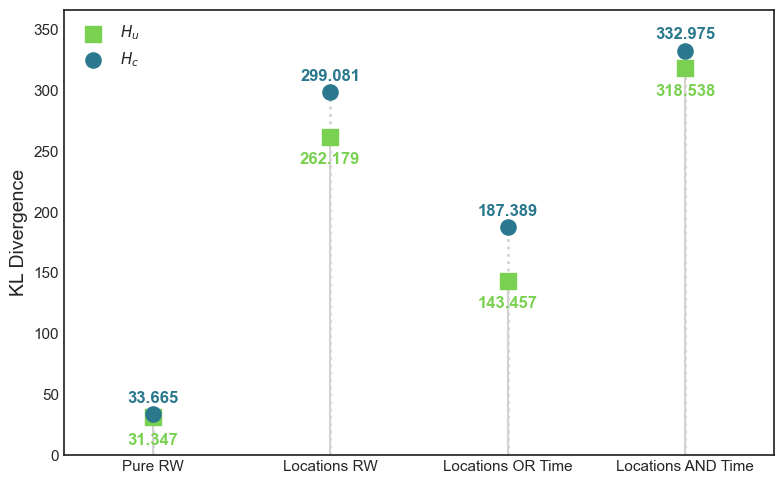

In [105]:
modelos = ['Pure RW', 'Locations RW', 'Locations OR Time', 'Locations AND Time']
#modelos = ['AND Time', 'OR Time', 'Locations RW', 'Pure RW']
x = list(range(len(modelos)))

plt.figure(figsize=(8, 5))
plt.vlines(x, ymin=0, ymax=array_hc_hist, color='lightgray', linestyle=':', lw=2, zorder=1)
plt.vlines(x, ymin=0, ymax=array_hu_hist, color='lightgray', linestyle='-', lw=1.5, zorder=1)
plt.scatter(x, array_hu_hist, color='#7ad151', s=120, label='$H_u$', marker='s', zorder=2)
plt.scatter(x, array_hc_hist, color='#2a788e', s=120, label='$H_c$', marker='o', zorder=2)

for i in x:
    plt.text(i, array_hu_hist[i] - max(array_hu_hist)*0.04, f'{array_hu_hist[i]:.3f}', ha='center', va='top', color='#7ad151', fontweight='bold', fontsize=12)
    plt.text(i, array_hc_hist[i] + max(array_hc_hist)*0.02, f'{array_hc_hist[i]:.3f}', ha='center', va='bottom', color='#2a788e', fontweight='bold', fontsize=12)
plt.ylabel('KL Divergence', fontsize=14)
plt.xticks(x, modelos, fontsize=11)
plt.tick_params(axis='both', direction='in', length=0)
plt.legend(frameon=False, fontsize=11, loc='upper left')

max_y_0 =  max(array_hu_hist) * 1.15
plt.ylim(0, max_y_0)
plt.xlim(-0.5, 3.5)
plt.tight_layout()
plt.savefig('figs/kl_divergence_lollipops.png', dpi=300, bbox_inches='tight')
plt.show()

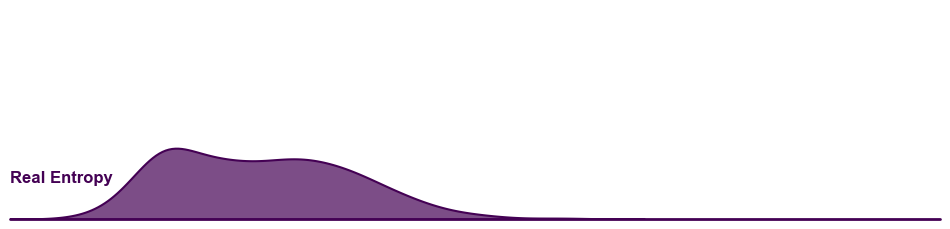

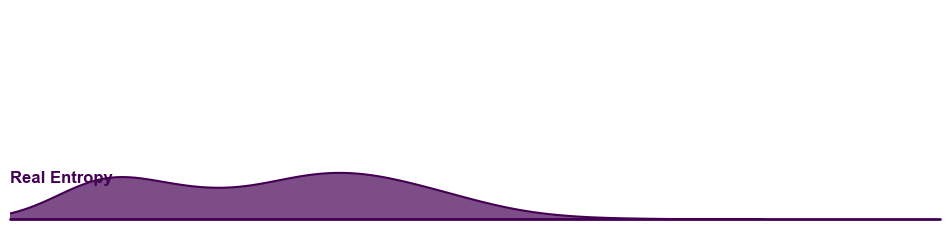

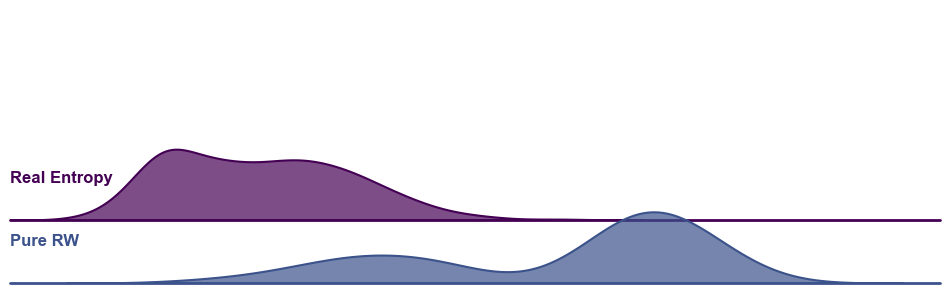

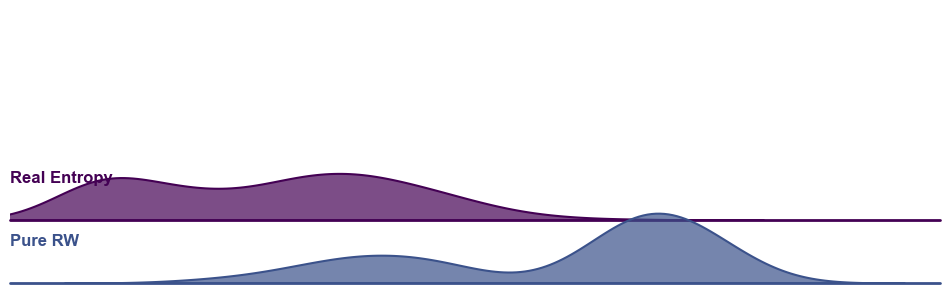

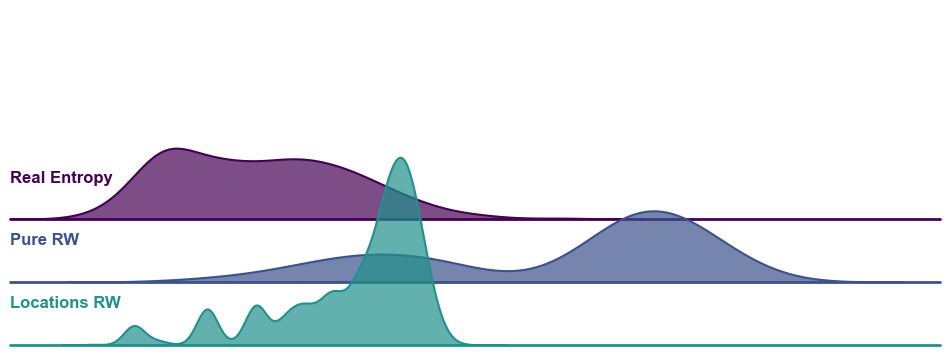

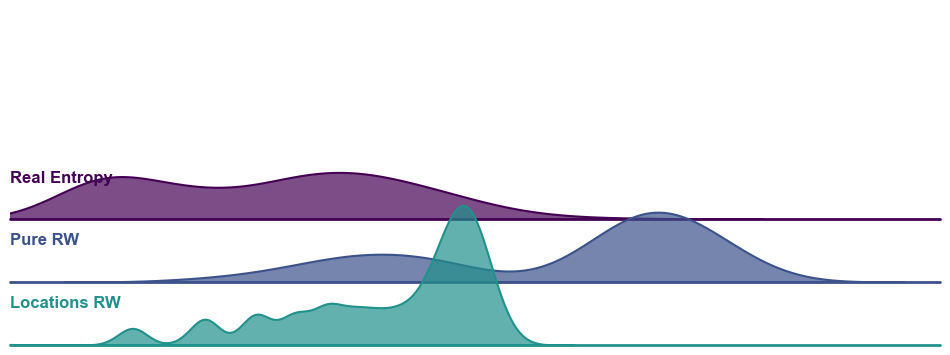

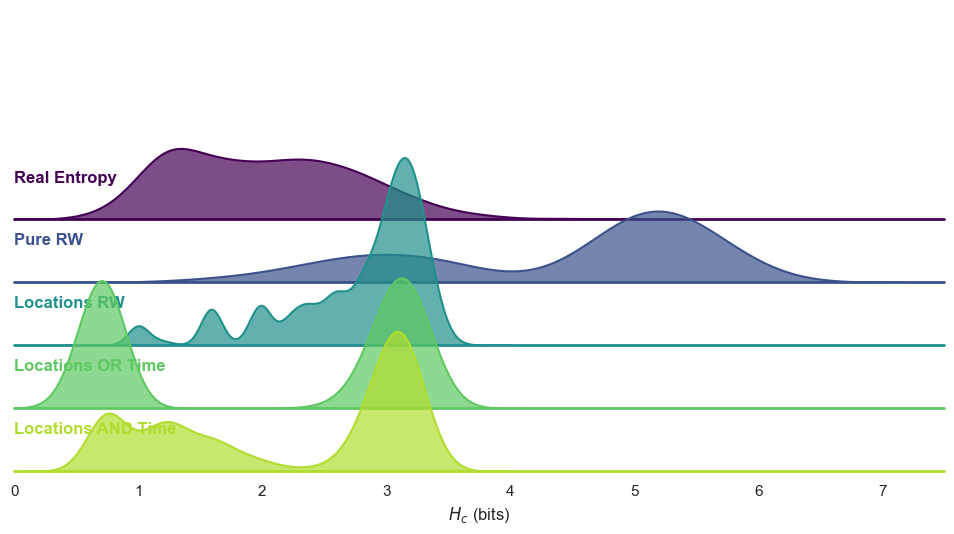

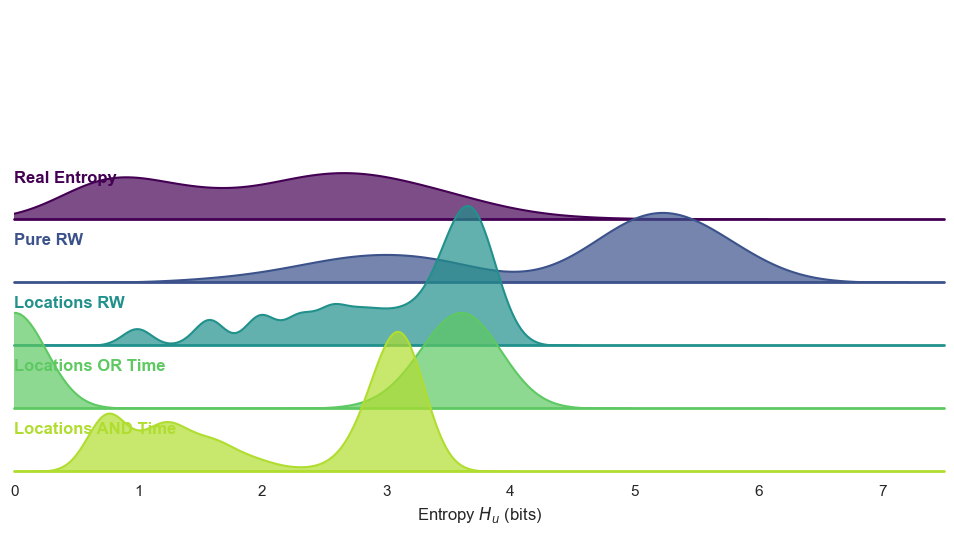

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_ridge_accumulative(data_dict, xlabel, filename, x_range=(0, 7.5), y_max=1.5):
    # 1. Definición del orden estricto de las 5 filas de arriba a abajo
    row_order = [
        'Real Entropy',
        'Pure RW',
        'Locations RW',
        'Locations OR Time',
        'Locations AND Time'
    ]
    
    # 2. Configuración de la paleta Viridis conservando los primeros tonos 
    # y oscureciendo quirúrgicamente el último amarillo chillón a un tono más visible
    viridis_cmap = plt.get_cmap('viridis')
    colors = {label: viridis_cmap(i / (len(row_order) - 1)) for i, label in enumerate(row_order)}
    colors['Locations AND Time'] = viridis_cmap(0.88)
    
    # 3. Inicialización del entorno gráfico con el solapamiento deseado (-0.7)
    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
    fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 6), sharex=True, 
                             gridspec_kw={'hspace': -0.7})
    
    # Mapeo de cada categoría a su respectivo sub-eje
    ax_dict = {label: axes[i] for i, label in enumerate(row_order)}
    
    # 4. Iteración y renderizado de cada una de las capas del Ridge Plot
    for label in row_order:
        ax = ax_dict[label]
        ax.set_xlim(x_range)
        ax.set_ylim(0, y_max)
        
        if label in data_dict:
            values = data_dict[label]
            color = colors[label]
            
            # Dibujamos la densidad y su respectiva línea base
            sns.kdeplot(values, fill=True, alpha=0.7, lw=1.5, color=color, ax=ax, common_norm=False)
            ax.axhline(y=0, lw=2, color=color, clip_on=False)
            
            # Texto identificador de la variable a la izquierda
            ax.text(0, 0.2, label, fontweight="bold", color=color,
                    ha="left", va="center", transform=ax.transAxes)
        else:
            # Si la categoría no está activa en el paso actual, ocultamos el eje
            # pero mantenemos su espacio físico para preservar la escala e invariabilidad
            ax.set_visible(False)
            
        # Limpieza estética de bordes y etiquetas por fila
        ax.set_ylabel("")
        ax.set_yticks([])
        sns.despine(ax=ax, bottom=True, left=True)
        
    # 5. Activación exclusiva del eje X en la última categoría visible del paso
    for label in reversed(row_order):
        if label in data_dict:
            ax_dict[label].xaxis.set_visible(True)
            ax_dict[label].set_xlabel(xlabel, fontsize=12)
            break
            
    # Guardar la figura exportando con alta resolución y sin recortes
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# =============================================================================
# SECUENCIA DE EJECUCIÓN: GENERACIÓN DE LOS 4 PASOS ACUMULATIVOS
# =============================================================================

# --- PASO 1: Solo la fila de la entropía real ---
hc_1 = {'Real Entropy': hc_values_return}
hu_1 = {'Real Entropy': hu_values_return}
plot_ridge_accumulative(hc_1, "$H_c$ (bits)", "figs/ridge_hc_paso1.png")
plot_ridge_accumulative(hu_1, "Entropy $H_u$ (bits)", "figs/ridge_hu_paso1.png")

# --- PASO 2: Se mantiene la anterior y se añade Pure RW abajo ---
hc_2 = {'Real Entropy': hc_values_return, 'Pure RW': hc_rw_pure}
hu_2 = {'Real Entropy': hu_values_return, 'Pure RW': hu_rw_pure}
plot_ridge_accumulative(hc_2, "$H_c$ (bits)", "figs/ridge_hc_paso2.png")
plot_ridge_accumulative(hu_2, "Entropy $H_u$ (bits)", "figs/ridge_hu_paso2.png")

# --- PASO 3: Se mantienen las anteriores y se añade Locations RW abajo ---
hc_3 = {'Real Entropy': hc_values_return, 'Pure RW': hc_rw_pure, 'Locations RW': hc_orig}
hu_3 = {'Real Entropy': hu_values_return, 'Pure RW': hu_rw_pure, 'Locations RW': hu_orig}
plot_ridge_accumulative(hc_3, "$H_c$ (bits)", "figs/ridge_hc_paso3.png")
plot_ridge_accumulative(hu_3, "Entropy $H_u$ (bits)", "figs/ridge_hu_paso3.png")

# --- PASO 4: Escenario completo (Aparecen las 5 filas escalonadas sin deformarse) ---
hc_4 = {
    'Real Entropy': hc_values_return, 
    'Pure RW': hc_rw_pure, 
    'Locations RW': hc_orig, 
    'Locations OR Time': hc_dual, 
    'Locations AND Time': hc_crit
}
hu_4 = {
    'Real Entropy': hu_values_return, 
    'Pure RW': hu_rw_pure, 
    'Locations RW': hu_orig, 
    'Locations OR Time': hu_dual, 
    'Locations AND Time': hc_crit
}
plot_ridge_accumulative(hc_4, "$H_c$ (bits)", "figs/ridge_hc_paso4.png")
plot_ridge_accumulative(hu_4, "Entropy $H_u$ (bits)", "figs/ridge_hu_paso4.png")

In [48]:
L_STAR = 8.42
#best_beta, best_tc = optimize_parameters_by_kl(checkins, hc_values_return, L_STAR, deviation)
#hc_final, hu_final = run_simulation(checkins, 20, L_STAR, DEVIATION, best_beta, best_tc)

best_beta = 0.5